# Rutgers Exploratory Data Analysis

Date: 05-26-26

Notes: 
- Physiological data + demographic data were merged and cleaned in Notebook file sql_data_cleaning_052526.ipynb
  - Exported 'clean' dataset from this notebook to reduce clutter of code
  - Some of that code is kept here for reference (e.g., data distribution) 


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

### Load Data

In [91]:
physio_demo_df = pd.read_excel('/Users/thomasgooding/Desktop/Rutgers_SQLdata/Clean_scripts/physio_demo_data_cleaned_06.01.26.xlsx')

physio_demo_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,weight,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,NaN,NaN,F,6.0,Other,6.0,5.0,no,NaN,NaN
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,NaN,NaN,F,5.0,White,5.0,5.0,no,NaN,NaN
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,NaN,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,NaN,NaN,F,2.0,Asian,2.0,1.0,no,NaN,NaN


In [92]:
stress_prevention_group_df = pd.read_csv('/Users/thomasgooding/Desktop/Rutgers_SQLdata/stress_prevention_groups.csv')

stress_prevention_group_df.head()

,ID6,GROUP_val
0,130501,C
1,130502,C
2,130503,C
3,130504,C
4,130505,C


## Exploratory Data Analysis of full dataset

### Counts of data distribution

- number of participants from each study DB
- count of participants with full and partial demographic data (H+W, race + ethnicity)

In [93]:
## Quick count of participants by study and timepoint get get a snapshot of the data distribution across studies and timepoints.
print(f'There are {physio_demo_df["ID6"].nunique()} total unique participants in the merged dataset.')
physio_demo_df.groupby('from_study', as_index=False, observed=True)['timepoint'].value_counts()

There are 694 total unique participants in the merged dataset.


,from_study,timepoint,count
0,Athlete,6P,109
1,Athlete,B1,109
2,BAA,6P,70
3,BAA,B1,70
4,CGE,6P,51
5,CGE,B1,51
6,VT1,6P,12
7,VT1,B1,12
8,VT2,6P,71
9,VT2,B1,71


### Value Counts

In [94]:
value_counts_df = pd.DataFrame({
    'count': physio_demo_df.count(),
    'percent_count': (physio_demo_df.count() / len(physio_demo_df) * 100).round(2)
})
value_counts_df = value_counts_df.sort_values(by='percent_count', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})

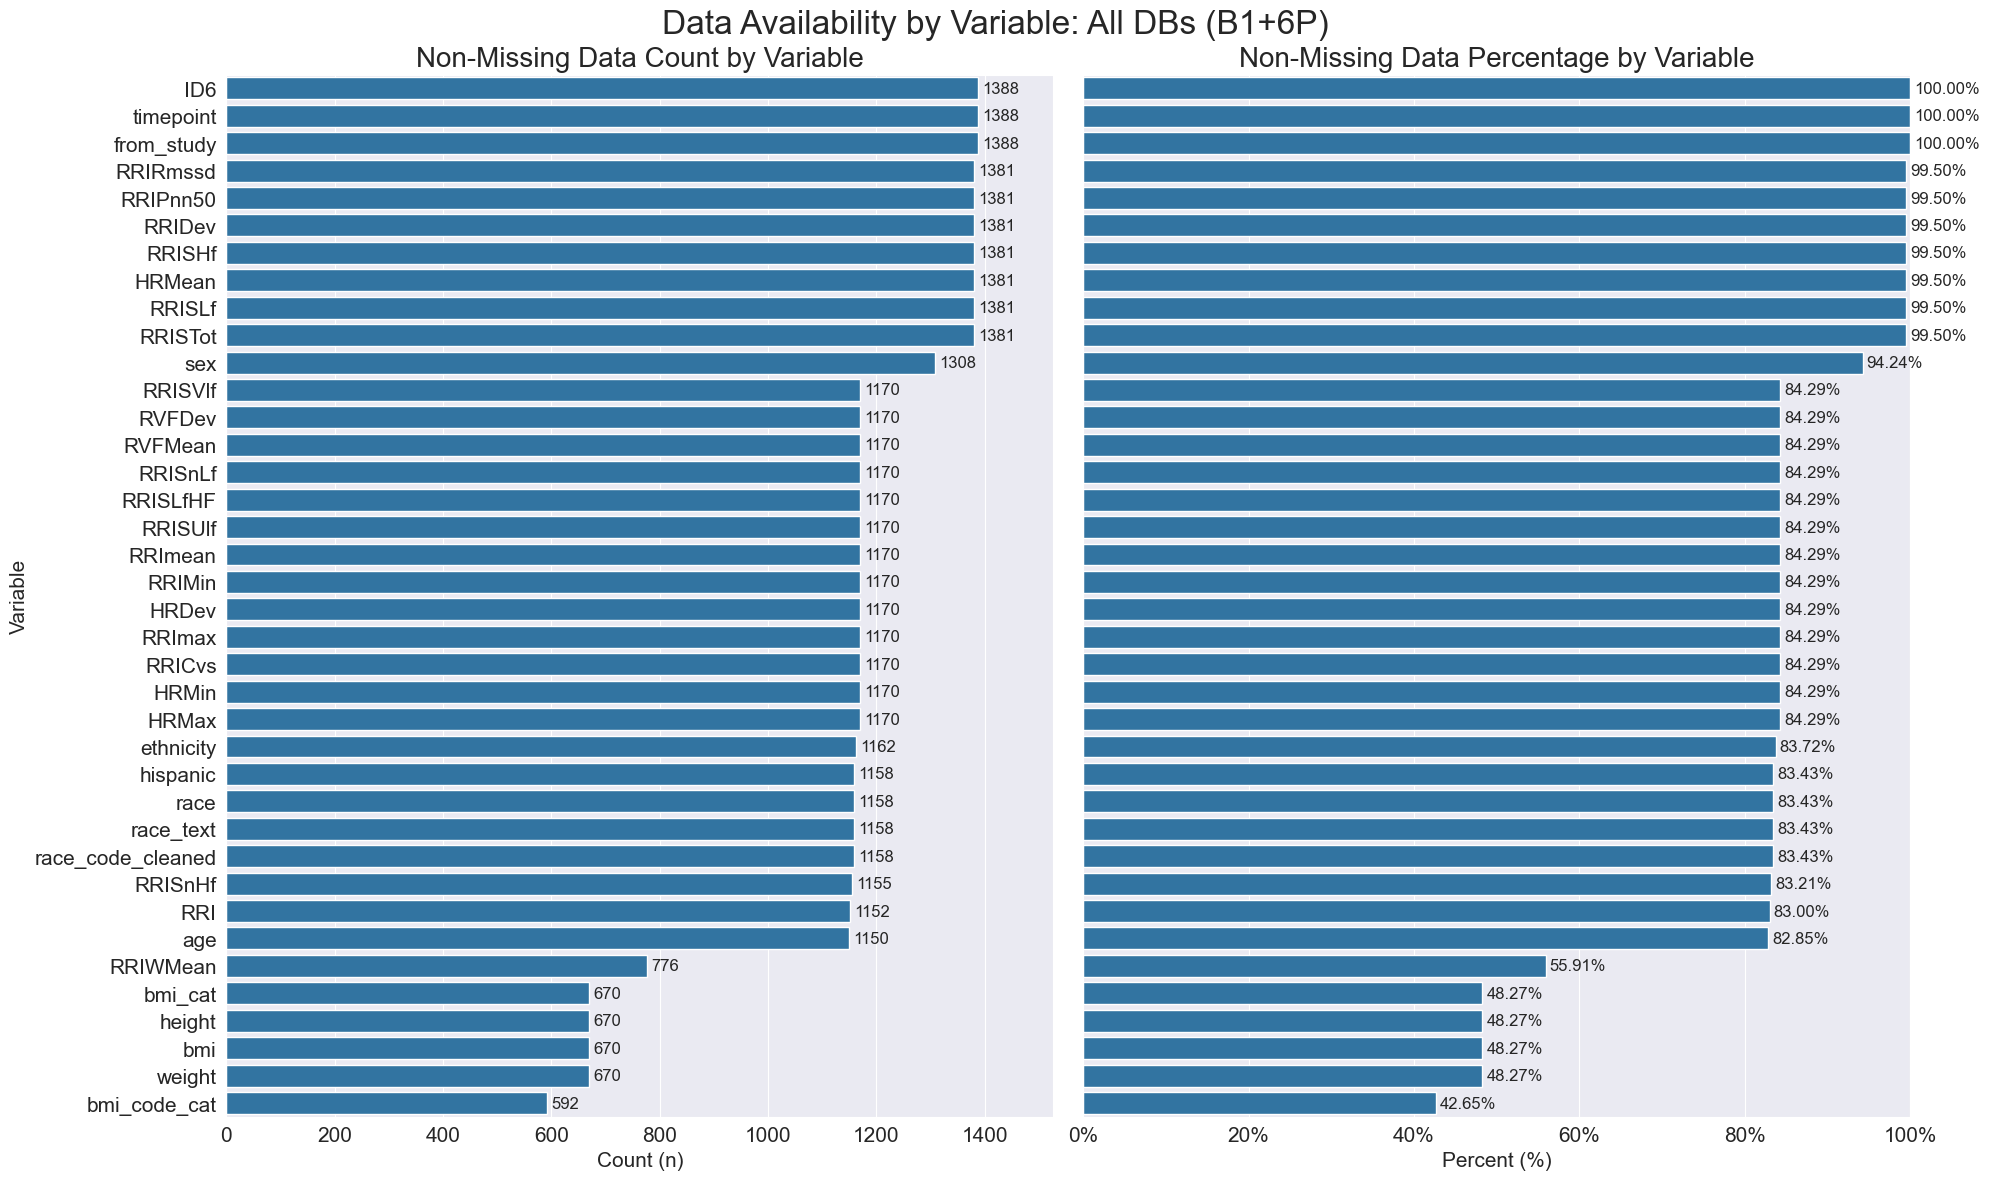

In [95]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1, 2, figsize=(20, 12), sharey=True)

# Count plot
ax1 = sns.barplot(
    data=value_counts_df,
    y='column',
    x='count',
    ax=ax[0]
)

ax1.set_title('Non-Missing Data Count by Variable', fontsize=20)
ax1.set_xlabel('Count (n)', fontsize=15)
ax1.set_ylabel('Variable', fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)

ax1.bar_label(
    ax1.containers[0],
    fmt='%.0f',
    padding=3,
    fontsize=12
)

# Percent plot
ax2 = sns.barplot(
    data=value_counts_df,
    y='column',
    x='percent_count',
    ax=ax[1]
)

ax2.set_title('Non-Missing Data Percentage by Variable', fontsize=20)
ax2.set_xlabel('Percent (%)', fontsize=15)
ax2.set_ylabel('')
ax2.tick_params(axis='both', which='major', labelsize=15)

ax2.set_xticks(np.arange(0, 101, 20))
ax2.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

ax2.bar_label(
    ax2.containers[0],
    fmt='%.2f%%',
    padding=3,
    fontsize=12
)

# Expand x-axis limits to avoid clipping labels
ax1.set_xlim(0, value_counts_df['count'].max() * 1.1)
ax2.set_xlim(0, 100)

# Overall title
fig.suptitle(
    'Data Availability by Variable: All DBs (B1+6P)',
    fontsize=24
)

plt.tight_layout()
plt.show()

### Missing Data check 

In [96]:
missing_values_df = pd.DataFrame({
    'count': physio_demo_df.isnull().sum(),
    'percent_missing': (physio_demo_df.isnull().sum() / len(physio_demo_df)) * 100 
}).sort_values(by='percent_missing', ascending=False).round(2).reset_index().rename(columns={'index': 'column'})


In [97]:
data = {
    'column': 'Total rows',
    'count' : len(physio_demo_df),
    'percent_missing': 100.0
}
total_df = pd.DataFrame(data, index=[0])

total_df.head()
missing_values_df = pd.concat([missing_values_df, total_df], ignore_index=True)
missing_values_df.sort_values(by='count', ascending=False, inplace=True)

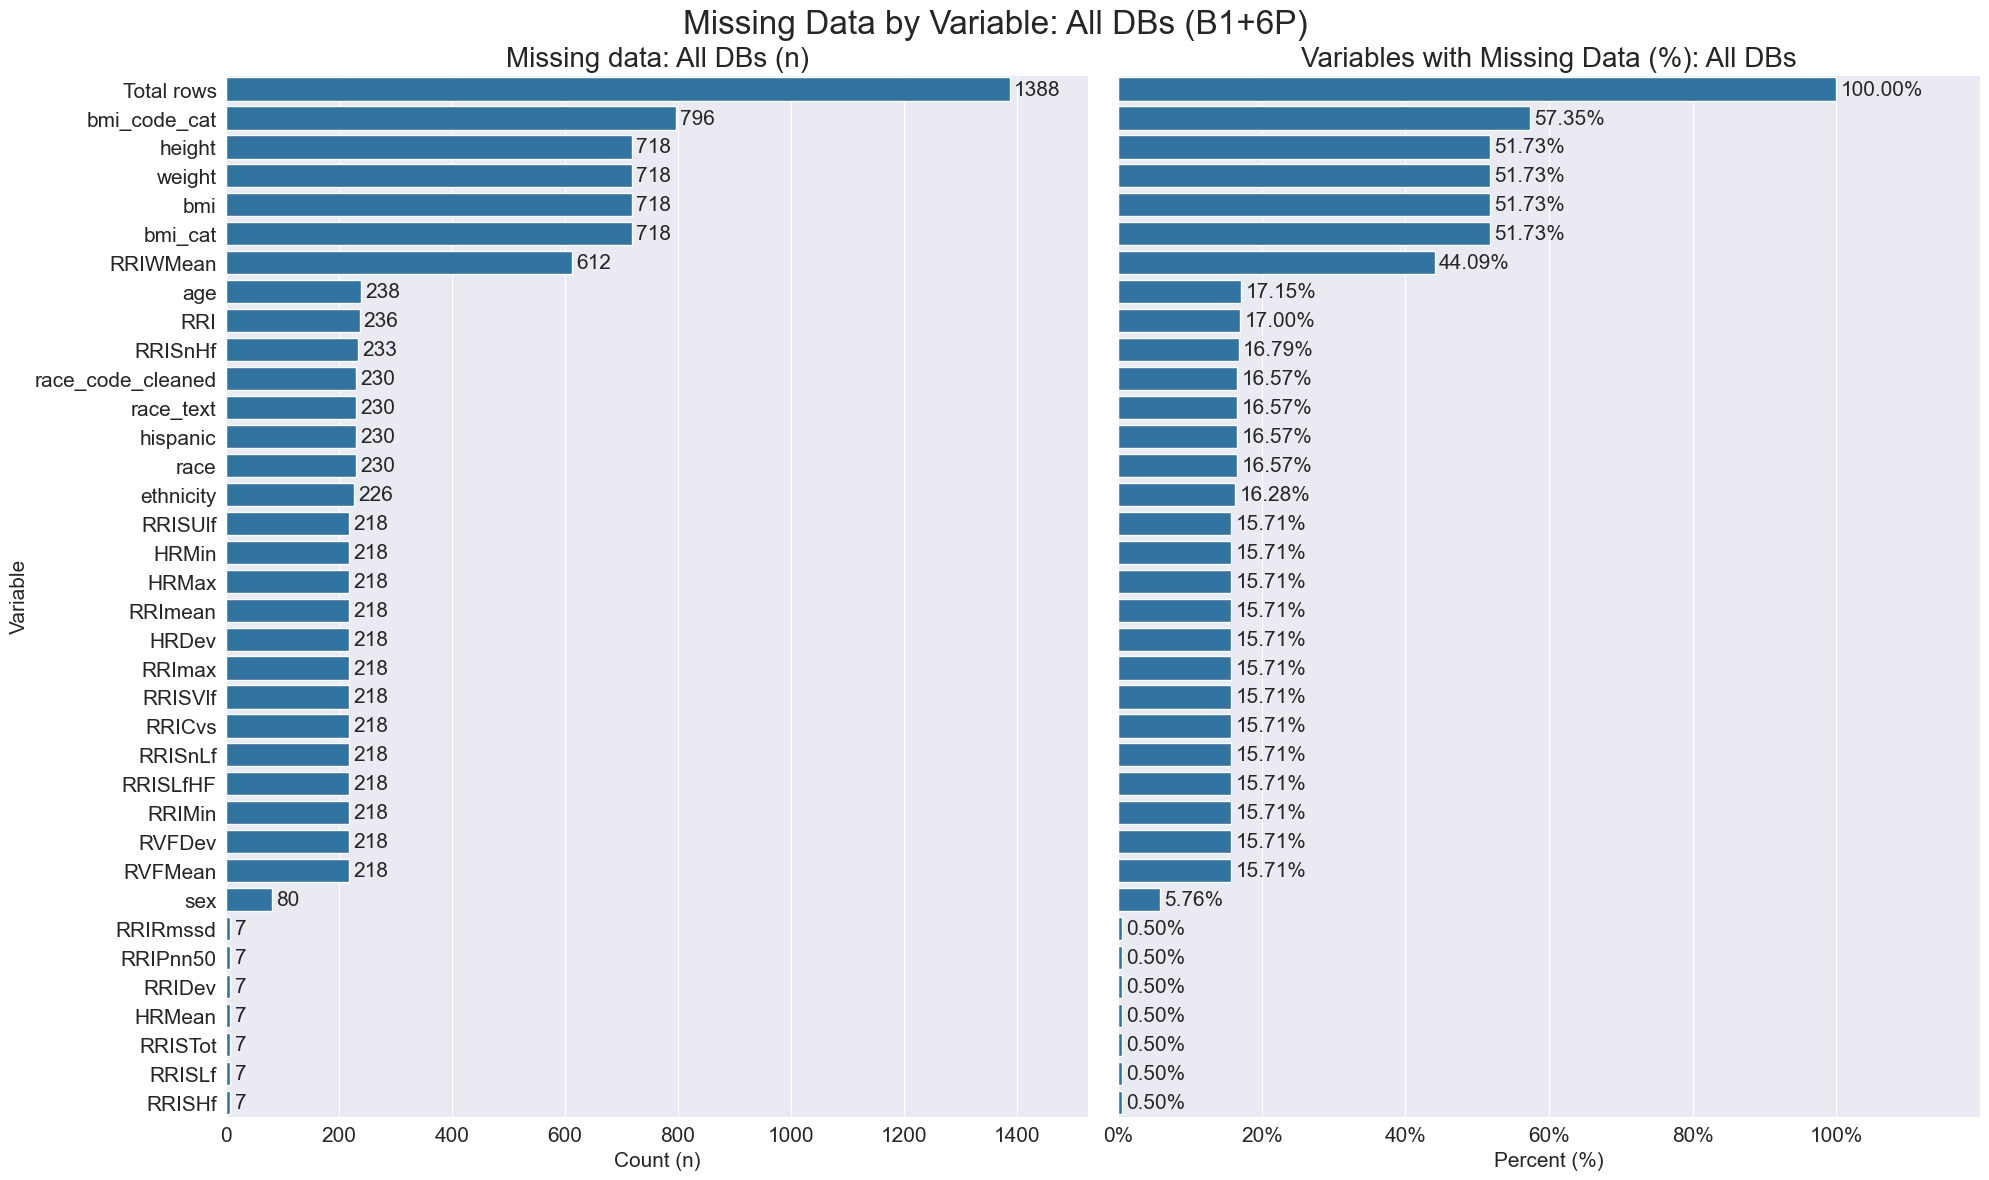

In [98]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(20,12))

### Filter_df to only include variables with missing data for better visualization
filtered_df = missing_values_df[missing_values_df['percent_missing'] > 0].copy().reset_index(drop=True)

ax1= sns.barplot(y=filtered_df['column'], x=filtered_df['count'], ax=ax[0])

ax1.set_ylabel('Variable',fontsize=15)
ax1.set_xlabel('Count (n)',fontsize=15)
# ax1.tick_params(axis='x', rotation=-90)
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3, fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_title('Missing data: All DBs (n)', fontsize=20)

#### Second Plot 
ax2= sns.barplot(y=filtered_df['column'], x=filtered_df['percent_missing'], ax=ax[1])

ax2.set_ylabel('Variable', fontsize=15)
ax2.set_xlabel('Percent (%)',fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3, fontsize=15)
ax2.set_title('Missing data: All DBs (n)', fontsize=20)
ax2.set_title('Variables with Missing Data (%): All DBs', fontsize=20)

fig.suptitle('Missing Data by Variable: All DBs (B1+6P)', fontsize=24)

## increase x-margins
current_max1 = missing_values_df['count'].max()
current_max2 = missing_values_df['percent_missing'].max()
ax1.set_xlim(0, current_max1 * 1.1)
ax2.set_xlim(0, current_max2 * 1.2)

plt.tight_layout()
plt.show()

## added "total rows" to this to see how many obseravtions thgere are relative to the missing data counts and percentages.

#### RRI missing counts

In [99]:
physio_demo_df[physio_demo_df['from_study']=='stress_suppl'][['ID6', 'timepoint', 'RRI']].head(60)

,ID6,timepoint,RRI
382,120210,B1,2.276766e+04
383,120211,B1,6.286818e+03
384,120212,B1,NaN
385,120213,B1,NaN
386,120214,B1,NaN
387,120215,B1,4.871191e+03
388,120216,B1,4.148095e+04
389,120217,B1,6.882831e+04
390,120218,B1,3.770795e+03
391,120219,B1,6.750009e+03


In [100]:
## Missing RRI by study 
## Used here since we've been consolidating and importing this data
(
    physio_demo_df
    .groupby('from_study', observed=True)['RRI']
    .agg(
        total_count='size',
        rri_count='count',           # non-missing values
        missing_count=lambda x: x.isna().sum()
    )
    .reset_index()
)

,from_study,total_count,rri_count,missing_count
0,Athlete,218,0,218
1,BAA,140,139,1
2,CGE,102,99,3
3,VT1,24,24,0
4,VT2,142,142,0
5,WTP,178,178,0
6,stress_pic,332,332,0
7,stress_prevention,190,190,0
8,stress_suppl,62,48,14


## Demographic Data

In [101]:
## Making a list of demographic variables for later use
demographic_variables = list(['sex',
                        'bmi_cat',
                         'race',
                         'race_text',
                         'ethnicity',
                         'hispanic']
)
physio_demo_df[demographic_variables] = physio_demo_df[demographic_variables].astype('category')
demographic_variables

['sex', 'bmi_cat', 'race', 'race_text', 'ethnicity', 'hispanic']

### Make Groups

- Addiction
- Athlete
- Control

In [102]:
physio_demo_df['Group'] = 'Control'

stress_prev_map = stress_prevention_group_df.set_index('ID6')['GROUP_val']

physio_demo_df['Group'] = (physio_demo_df['ID6'].map(stress_prev_map).fillna(physio_demo_df['Group']))

physio_demo_df.loc[physio_demo_df['from_study'] == 'Athlete', 'Group'] = 'Athlete'

physio_demo_df.loc[physio_demo_df['from_study'].isin(['WTP', 'CGE']), 'Group'] = 'Addiction'

physio_demo_df.replace({'Group': {'C': 'Control', 'A': 'Athlete', 'D': 'Addiction'}}, inplace=True)

physio_demo_df['Group'] =physio_demo_df['Group'].astype('category')
physio_demo_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,bmi,sex,race,race_text,race_code_cleaned,ethnicity,hispanic,bmi_cat,bmi_code_cat,Group
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN,Control
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,NaN,F,6.0,Other,6.0,5.0,no,NaN,NaN,Control
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,NaN,F,5.0,White,5.0,5.0,no,NaN,NaN,Control
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,NaN,F,2.0,Asian,2.0,1.0,yes,NaN,NaN,Control
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,NaN,F,2.0,Asian,2.0,1.0,no,NaN,NaN,Control


In [103]:
print(f'There are {physio_demo_df["ID6"].nunique()} unique participants in the merged dataset.')

physio_demo_df.groupby('Group', observed=True)['ID6'].nunique().rename({'ID6': 'Count (n)'})

There are 694 unique participants in the merged dataset.


Group
Addiction    167
Athlete      130
Control      397
Name: ID6, dtype: int64

### Subsets of demographic data

#### Demographics at baseline

In [104]:
print("Potential Dataset options for physiological + demographic variables:")
print(f"This dataset includes {physio_demo_df['ID6'].nunique()} unique participants, regardless of demographic data.")

full_rows_df = physio_demo_df.dropna(subset=demographic_variables, axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with complete demographic data (age, height, weight, sex, race, ethnicity, hispanic) at baseline (B1).")

full_rows_df = physio_demo_df.dropna(subset=['age'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with complete age demographic data at baseline (B1).") ## missing 10 age values at B1

full_rows_df = physio_demo_df.dropna(subset=['age', 'height', 'weight'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with age + height + weight data at baseline (B1).")

full_rows_df = physio_demo_df.dropna(subset=['age', 'race', 'ethnicity'], axis=0).copy().reset_index(drop=True)
full_rows_b1_df = full_rows_df[full_rows_df['timepoint'] == 'B1'].copy().reset_index(names='n')
print(f"There are {full_rows_b1_df['ID6'].nunique()} unique participants with age + race + ethnicity data at baseline (B1).")

Potential Dataset options for physiological + demographic variables:
This dataset includes 694 unique participants, regardless of demographic data.
There are 321 unique participants with complete demographic data (age, height, weight, sex, race, ethnicity, hispanic) at baseline (B1).
There are 575 unique participants with complete age demographic data at baseline (B1).
There are 335 unique participants with age + height + weight data at baseline (B1).
There are 558 unique participants with age + race + ethnicity data at baseline (B1).


In [105]:
## Show count of participants from each study with complete demographic data at B1
full_rows_b1_df.groupby('from_study', as_index=False, observed=True)['ID6'].nunique().rename(columns={'ID6': 'Count (n)'})

,from_study,Count (n)
0,BAA,65
1,CGE,47
2,VT2,68
3,WTP,88
4,stress_pic,165
5,stress_prevention,94
6,stress_suppl,31


In [106]:
## What is still missing from "full demographics rows" at B1 timepoint
missing_table = pd.DataFrame({
    'variable': full_rows_b1_df.columns,
    'missing_count': full_rows_b1_df.isna().sum(),
    'percent_missing': ((full_rows_b1_df.isna().sum() / len(full_rows_b1_df)) * 100).round(2)

}).reset_index(drop=True).sort_values(by='percent_missing', ascending=False)

missing_table[missing_table['percent_missing'] > 0]

,variable,missing_count,percent_missing
38,bmi_code_cat,276,49.46
30,bmi,237,42.47
28,height,237,42.47
37,bmi_cat,237,42.47
29,weight,237,42.47
24,RRIWMean,196,35.13
23,RRI,9,1.61
36,hispanic,2,0.36
22,RRISnHf,1,0.18


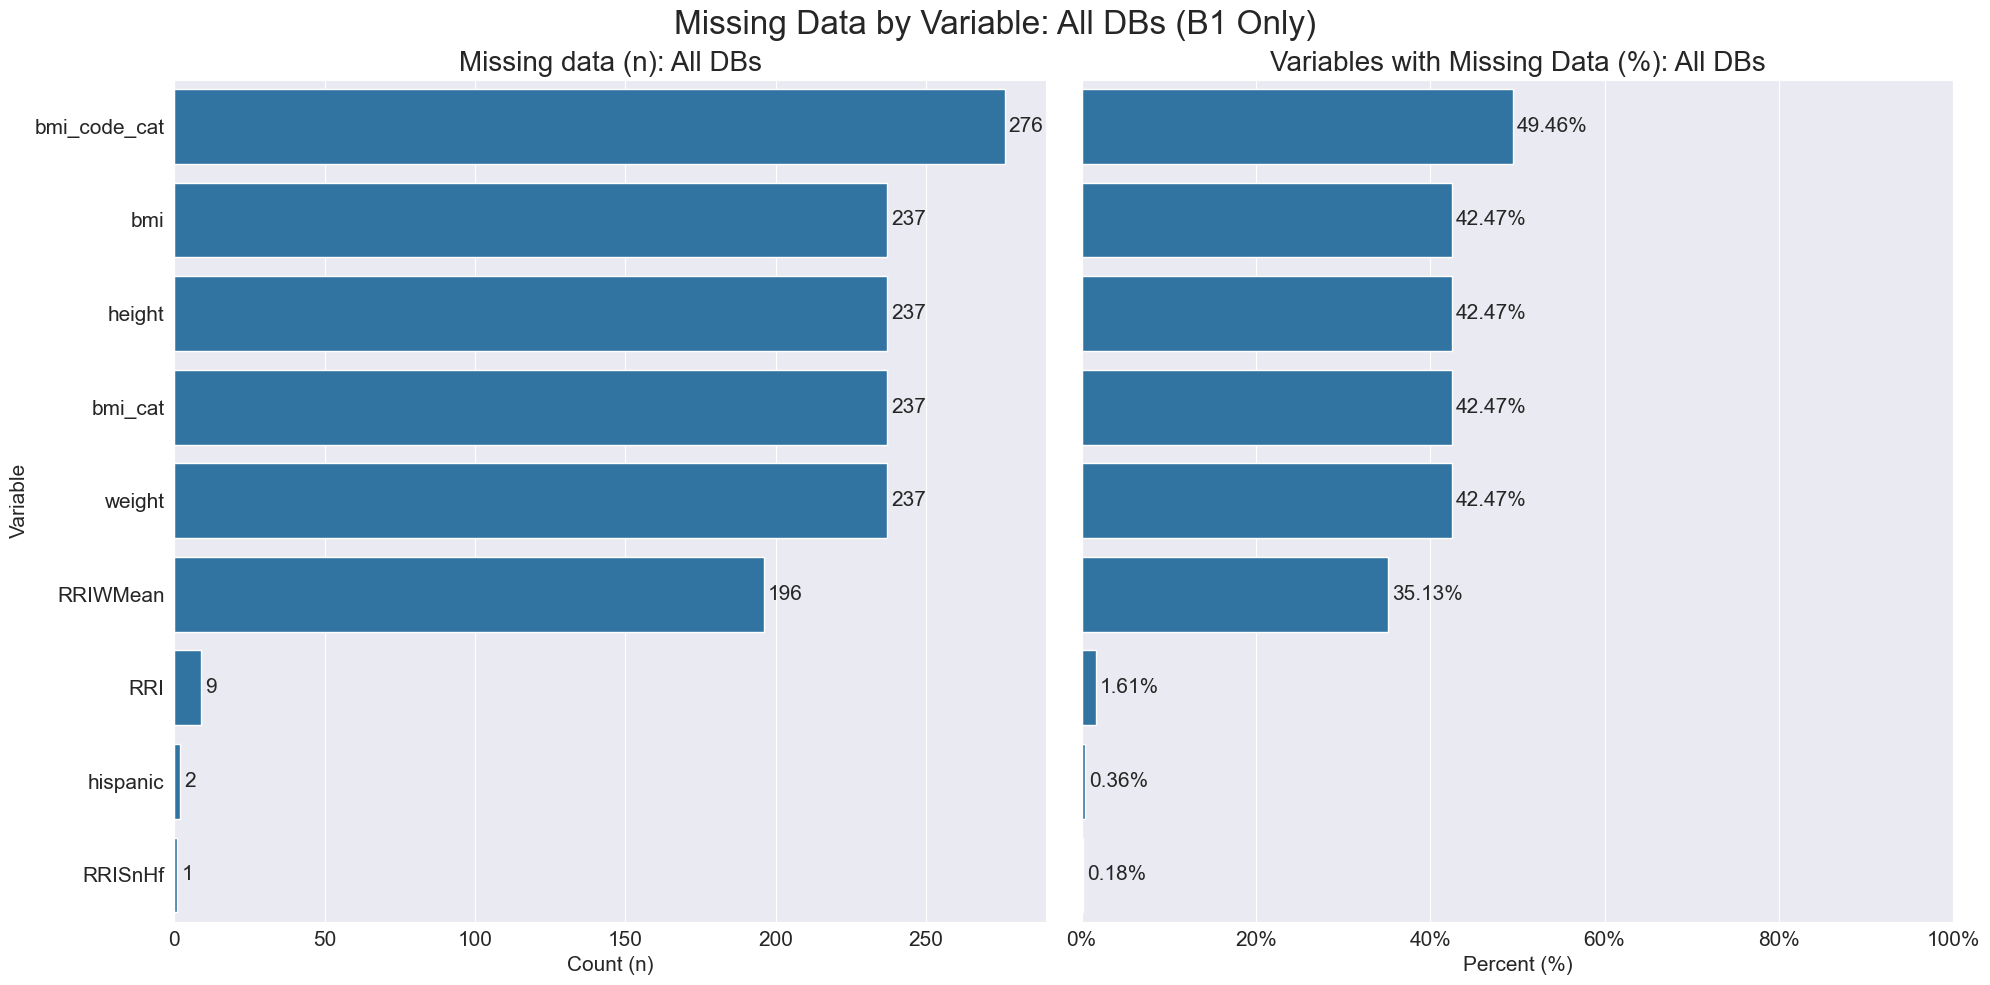

In [107]:
sns.set_style('darkgrid')

fig, ax = plt.subplots(1,2,sharey=True, figsize=(20,10))

### Filter_df to only include variables with missing data for better visualization
filtered_df = missing_table[missing_table['percent_missing'] > 0].copy().reset_index(drop=True)

ax1= sns.barplot(y=filtered_df['variable'], x=filtered_df['missing_count'], ax=ax[0])

ax1.set_ylabel('Variable',fontsize=15)
ax1.set_xlabel('Count (n)',fontsize=15)
# ax1.tick_params(axis='x', rotation=-90)
ax1.bar_label(ax1.containers[0], fmt='%.0f', padding=3, fontsize=15)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax1.set_title('Missing data (n): All DBs', fontsize=20)

#### Second Plot 
ax2= sns.barplot(y=filtered_df['variable'], x=filtered_df['percent_missing'], ax=ax[1])

ax2.set_ylabel('Variable', fontsize=15)
ax2.set_xlabel('Percent (%)',fontsize=15)
ax2.set_xticks(np.arange(0,101,20), labels=['0%', '20%', '40%', '60%', '80%', '100%'])
# ax2.tick_params(axis='x', rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3, fontsize=15)
ax2.set_title('Missing data: All DBs (n)', fontsize=20)
ax2.set_title('Variables with Missing Data (%): All DBs', fontsize=20)

fig.suptitle('Missing Data by Variable: All DBs (B1 Only)', fontsize=24)

plt.tight_layout()
plt.show()

In [108]:
print(f'There are {physio_demo_df["ID6"].nunique()} unique participants in the merged dataset.')

physio_demo_df.groupby('Group', observed=True)['ID6'].nunique().rename({'ID6': 'Count (n)'})

There are 694 unique participants in the merged dataset.


Group
Addiction    167
Athlete      130
Control      397
Name: ID6, dtype: int64

In [109]:
physio_demo_df.groupby(['Group', 'from_study'], observed=True)['ID6'].nunique().rename({'ID6': 'Count (n)'})

Group      from_study       
Addiction  CGE                   51
           WTP                   89
           stress_prevention     27
Athlete    Athlete              109
           stress_prevention     21
Control    BAA                   70
           VT1                   12
           VT2                   71
           stress_pic           166
           stress_prevention     47
           stress_suppl          31
Name: ID6, dtype: int64

### Quick reference plot of all demographic variables side-by-side.

## HRV metrics transformation

- Use natural log for HRV transformation (unless I hear otherwise)
  - frequency measures
  - time series measures (RRIRmssd, RRIPnn50)
  

In [110]:
# list(physio_demo_df.columns)

In [111]:
Original_HR_metrics = [
'RRIMin',
 'RRImax',
 'RRImean',
 'RRIRmssd',
 'RRIPnn50',
 'RRIDev',
 'RRICvs',
 'HRMin',
 'HRMax',
 'HRMean',
 'HRDev',
 'RRISTot',
 'RRISUlf',
 'RRISVlf',
 'RRISLf',
 'RRISHf',
 'RRISLfHF',
 'RRISnLf',
 'RRISnHf',
 'RRI',
 'RRIWMean'
]

HRV_to_transform = [
 'RRISTot',
 'RRISUlf',
 'RRISVlf',
 'RRISLf',
 'RRISHf',
 'RRISLfHF',
 'RRISnLf',
 'RRISnHf',
 'RRI',
 'RRIRmssd',
 'RRIPnn50',
]

HRV_metrics_vanilla = [ 'RRIMin',
 'RRImax',
 'RRImean',
#  'RRIRmssd',
#  'RRIPnn50',
 'RRIDev',
#  'RRICvs',
 'HRMin',
#  'HRMax',
 'HRMean',
 'HRDev',
#  'RRISTot', 'RRISUlf', 'RRISVlf', 'RRISLf', 'RRISHf', 'RRISLfHF', 'RRISnLf', 'RRISnHf', 'RRI', 'RRIWMean'
]

respiratory_metrics = [ 'RVFMean','RVFDev']


In [112]:
ln_columns = {}

for metric in HRV_to_transform:
    ln_columns[f'{metric}_ln'] = physio_demo_df[metric].apply(
        lambda x: math.log(x) if pd.notnull(x) and x > 0 else np.nan
    ).round(2)

# Drop existing _ln columns before concat to prevent duplicates on re-runs
physio_demo_df = physio_demo_df.drop(
    columns=[c for c in physio_demo_df.columns if c.endswith('_ln')],
    errors='ignore'
)

physio_demo_df = pd.concat([physio_demo_df, pd.DataFrame(ln_columns)], axis=1)

physio_demo_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,4.26,5.62,5.01,4.62,5.00,-0.53,-0.93,7.88,2.77,-0.69
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,5.36,6.82,8.35,8.23,4.73,-0.65,-0.77,11.57,4.75,4.09
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,4.81,7.04,8.27,8.14,4.74,-0.64,-0.77,10.45,5.00,4.27
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,3.14,5.93,6.14,7.10,3.64,-1.29,-0.33,9.18,4.06,3.90
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,5.81,7.18,7.11,7.14,4.58,-0.72,-0.69,10.05,4.37,4.12


In [113]:
transformed_HRV_cols = list(ln_columns)

transformed_HRV_cols

['RRISTot_ln',
 'RRISUlf_ln',
 'RRISVlf_ln',
 'RRISLf_ln',
 'RRISHf_ln',
 'RRISLfHF_ln',
 'RRISnLf_ln',
 'RRISnHf_ln',
 'RRI_ln',
 'RRIRmssd_ln',
 'RRIPnn50_ln']

In [114]:
### all phyisological variables for potential analysis (both transformed and untransformed)
# all_physio_vars = HRV_metrics + transformed_HRV_cols + resp_measures
all_physio_vars = HRV_metrics_vanilla + HRV_to_transform + transformed_HRV_cols +respiratory_metrics

### main phyisological variables to analyze
main_physio_vars = HRV_metrics_vanilla + transformed_HRV_cols + respiratory_metrics

main_physio_vars.sort()
## sorts the variables alphabetically to allow subplots of variables + transformed variables to be assessed side-by-side

vars_we_care = HRV_metrics_vanilla + transformed_HRV_cols + respiratory_metrics

vars_we_care.sort()

In [115]:
main_physio_vars
# vars_we_care

['HRDev',
 'HRMean',
 'HRMin',
 'RRIDev',
 'RRIMin',
 'RRIPnn50_ln',
 'RRIRmssd_ln',
 'RRISHf_ln',
 'RRISLfHF_ln',
 'RRISLf_ln',
 'RRISTot_ln',
 'RRISUlf_ln',
 'RRISVlf_ln',
 'RRISnHf_ln',
 'RRISnLf_ln',
 'RRI_ln',
 'RRImax',
 'RRImean',
 'RVFDev',
 'RVFMean']

In [116]:
vars_we_care

['HRDev',
 'HRMean',
 'HRMin',
 'RRIDev',
 'RRIMin',
 'RRIPnn50_ln',
 'RRIRmssd_ln',
 'RRISHf_ln',
 'RRISLfHF_ln',
 'RRISLf_ln',
 'RRISTot_ln',
 'RRISUlf_ln',
 'RRISVlf_ln',
 'RRISnHf_ln',
 'RRISnLf_ln',
 'RRI_ln',
 'RRImax',
 'RRImean',
 'RVFDev',
 'RVFMean']

In [117]:
vars_we_care_count = physio_demo_df.groupby(['timepoint'], observed=True)[vars_we_care].count().T

vars_we_care_count['difference'] = vars_we_care_count['6P'] - vars_we_care_count['B1']

vars_we_care_count


timepoint,6P,B1,difference
HRDev,585,585,0
HRMean,687,694,-7
HRMin,585,585,0
RRIDev,687,694,-7
RRIMin,585,585,0
RRIPnn50_ln,663,655,8
RRIRmssd_ln,687,694,-7
RRISHf_ln,687,694,-7
RRISLfHF_ln,585,585,0
RRISLf_ln,687,694,-7


In [118]:
physio_demo_df[vars_we_care].columns

Index(['HRDev', 'HRMean', 'HRMin', 'RRIDev', 'RRIMin', 'RRIPnn50_ln',
       'RRIRmssd_ln', 'RRISHf_ln', 'RRISLfHF_ln', 'RRISLf_ln', 'RRISTot_ln',
       'RRISUlf_ln', 'RRISVlf_ln', 'RRISnHf_ln', 'RRISnLf_ln', 'RRI_ln',
       'RRImax', 'RRImean', 'RVFDev', 'RVFMean'],
      dtype='object')

In [119]:
list(vars_we_care)

['HRDev',
 'HRMean',
 'HRMin',
 'RRIDev',
 'RRIMin',
 'RRIPnn50_ln',
 'RRIRmssd_ln',
 'RRISHf_ln',
 'RRISLfHF_ln',
 'RRISLf_ln',
 'RRISTot_ln',
 'RRISUlf_ln',
 'RRISVlf_ln',
 'RRISnHf_ln',
 'RRISnLf_ln',
 'RRI_ln',
 'RRImax',
 'RRImean',
 'RVFDev',
 'RVFMean']

## Data Visuals

#### Demographic visuals

- vars_we_care = main phyisological indices of interest

**includes:** 

'HRDev', 'HRMean', 'HRMin', 'RRIDev', 'RRIMin', 'RRIPnn50_ln',
       'RRIRmssd_ln', 'RRISHf_ln', 'RRISLfHF_ln', 'RRISLf_ln', 'RRISTot_ln',
       'RRISUlf_ln', 'RRISVlf_ln', 'RRISnHf_ln', 'RRISnLf_ln', 'RRI_ln',
       'RRImax', 'RRImean', 'RVFDev', 'RVFMean'

In [120]:
physio_demo_df_B1 = physio_demo_df[physio_demo_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

physio_demo_df_B1.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,4.26,5.62,5.01,4.62,5.00,-0.53,-0.93,7.88,2.77,-0.69
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,5.36,6.82,8.35,8.23,4.73,-0.65,-0.77,11.57,4.75,4.09
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,4.81,7.04,8.27,8.14,4.74,-0.64,-0.77,10.45,5.00,4.27
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,3.14,5.93,6.14,7.10,3.64,-1.29,-0.33,9.18,4.06,3.90
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,5.81,7.18,7.11,7.14,4.58,-0.72,-0.69,10.05,4.37,4.12


/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66374/3308474622.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66374/3308474622.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)


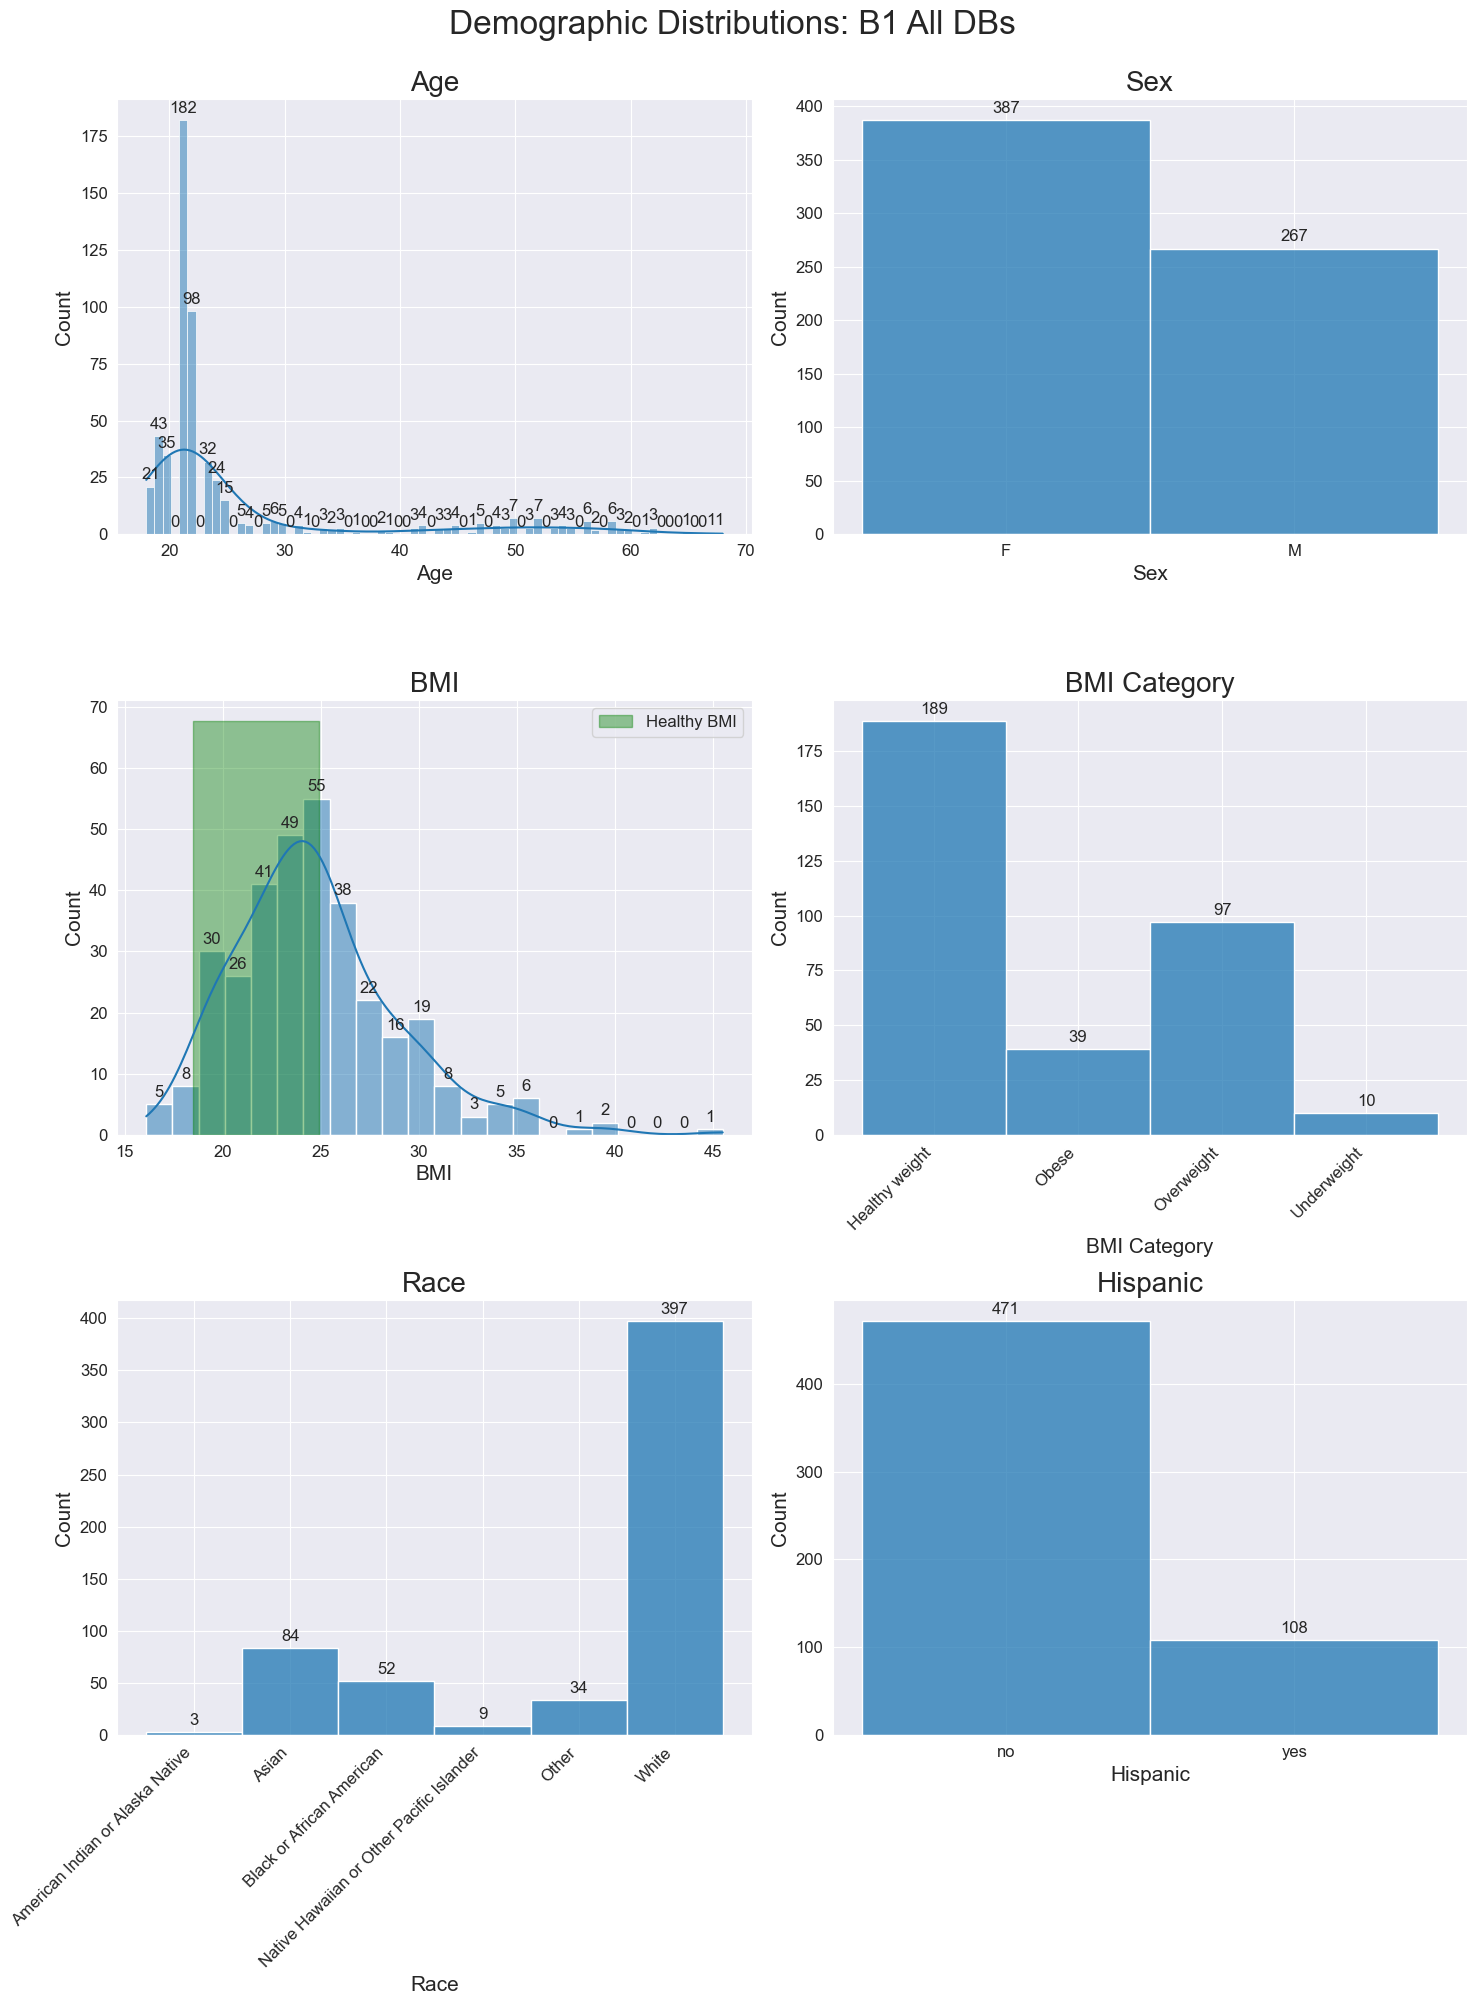

In [121]:
fig, ax = plt.subplots(3,2, figsize=(15,20))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age',kde=True, ax=ax[0,0])
ax1.bar_label(ax1.containers[0], fontsize=12, padding=3)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title('Age', fontsize=20)
ax1.set_ylabel('Count', fontsize=15)
ax1.set_xlabel('Age', fontsize=15)

ax2 = sns.histplot(data=physio_demo_df_B1, x='sex', ax=ax[0,1])
ax2.bar_label(ax2.containers[0], fontsize=12, padding=3)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title('Sex', fontsize=20)
ax2.set_ylabel('Count', fontsize=15)
ax2.set_xlabel('Sex', fontsize=15)

ax3 = sns.histplot(data=physio_demo_df_B1, x='bmi', kde=True, ax=ax[1,0])
ax3.bar_label(ax3.containers[0], fontsize=12, padding=3)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xticks(np.arange(0,51,5))
ax3.set_title('BMI', fontsize=20)
ax3.set_ylabel('Count', fontsize=15)
ax3.set_xlabel('BMI', fontsize=15)
ax3.fill_between(x=[18.5, 24.9], y1=0, y2=ax3.get_ylim()[1]+10, color='green', alpha=0.4, label='Healthy BMI')
ax3.legend(fontsize=12)

ax4 = sns.histplot(data=physio_demo_df_B1, x='bmi_cat', ax=ax[1,1])
ax4.bar_label(ax4.containers[0], fontsize=12, padding=3)
ax4.tick_params(axis='both', which='major', labelsize=12)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax4.set_title('BMI Category', fontsize=20)
ax4.set_ylabel('Count', fontsize=15)
ax4.set_xlabel('BMI Category', fontsize=15)

ax6 = sns.histplot(data=physio_demo_df_B1, x='race_text', ax=ax[2,0])
ax6.bar_label(ax6.containers[0], fontsize=12, padding=3)
ax6.tick_params(axis='both', which='major', labelsize=12)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax6.set_title('Race', fontsize=20)
ax6.set_ylabel('Count', fontsize=15)
ax6.set_xlabel('Race', fontsize=15)

ax7 = sns.histplot(data=physio_demo_df_B1, x='hispanic', ax=ax[2,1])
ax7.bar_label(ax7.containers[0], fontsize=12, padding=3)
ax7.tick_params(axis='both', which='major', labelsize=12)
ax7.set_title('Hispanic', fontsize=20)
ax7.set_ylabel('Count', fontsize=15)
ax7.set_xlabel('Hispanic', fontsize=15)

plt.suptitle('Demographic Distributions: B1 All DBs', fontsize=24, y=1.0)
plt.tight_layout()
plt.show()

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66374/192124849.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66374/192124849.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)


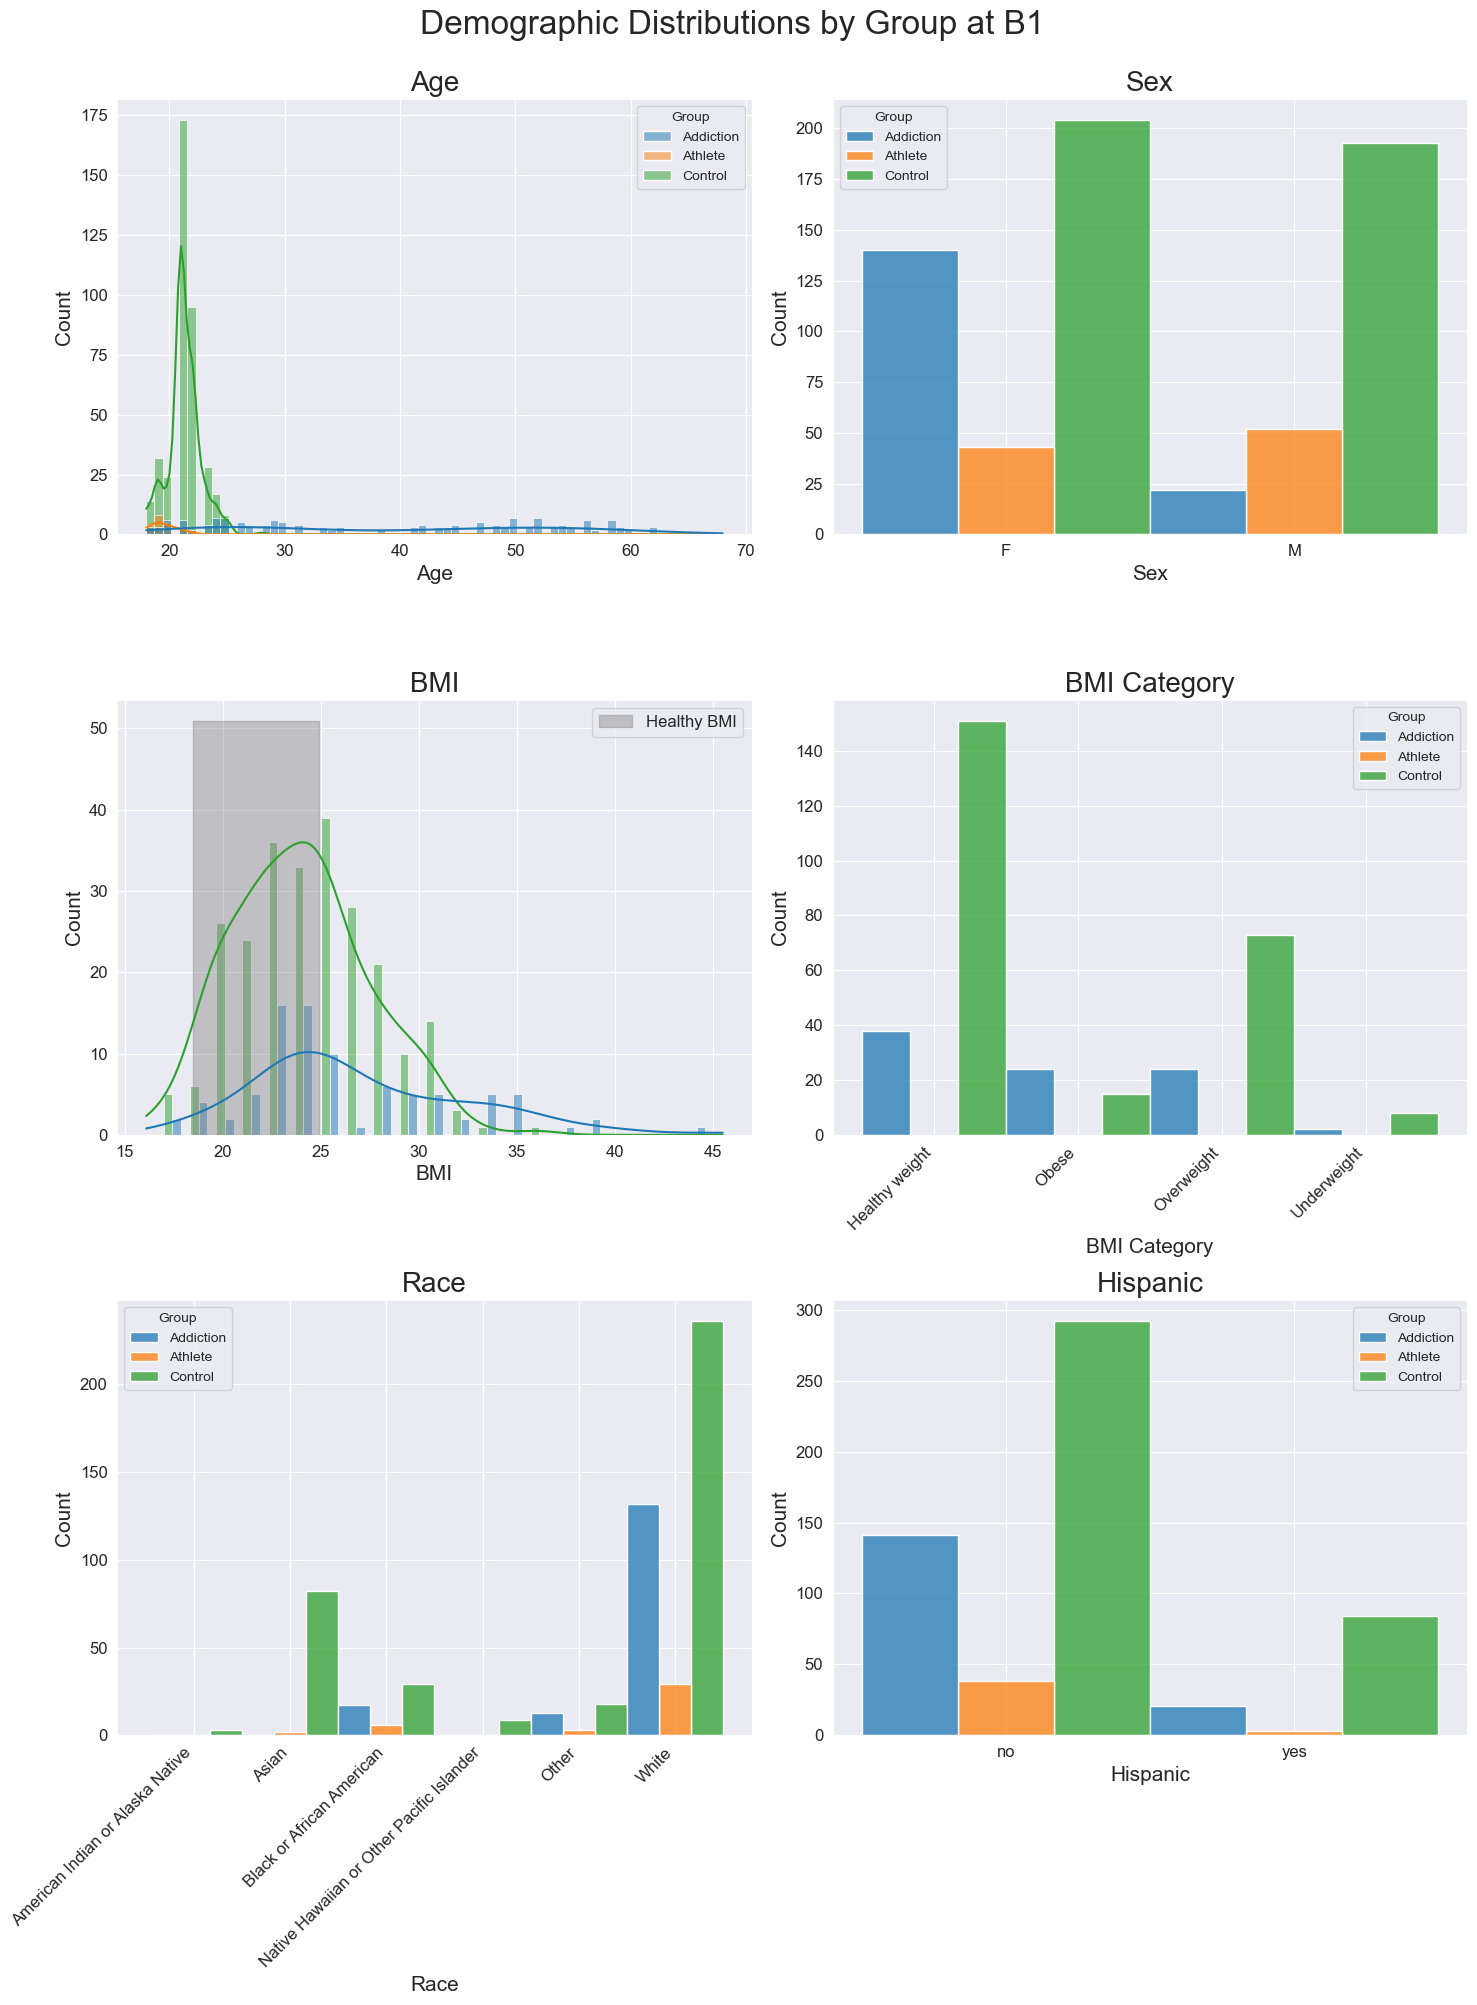

In [122]:
fig, ax = plt.subplots(3,2, figsize=(15,20))

ax1 = sns.histplot(data=physio_demo_df_B1, x='age', hue='Group', kde=True, ax=ax[0,0])
# ax1.bar_label(ax1.containers[0], fontsize=12, padding=3)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title('Age', fontsize=20)
ax1.set_ylabel('Count', fontsize=15)
ax1.set_xlabel('Age', fontsize=15)

ax2 = sns.histplot(data=physio_demo_df_B1, x='sex', hue='Group', multiple='dodge', ax=ax[0,1])
# ax2.bar_label(ax2.containers[0], fontsize=12, padding=3)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title('Sex', fontsize=20)
ax2.set_ylabel('Count', fontsize=15)
ax2.set_xlabel('Sex', fontsize=15)

ax3 = sns.histplot(data=physio_demo_df_B1, x='bmi', hue='Group', multiple='dodge', kde=True, ax=ax[1,0])
# ax3.bar_label(ax3.containers[0], fontsize=12, padding=3)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xticks(np.arange(0,51,5))
ax3.set_title('BMI', fontsize=20)
ax3.set_ylabel('Count', fontsize=15)
ax3.set_xlabel('BMI', fontsize=15)
ax3.fill_between(x=[18.5, 24.9], y1=0, y2=ax3.get_ylim()[1]+10, color='grey', alpha=0.4, label='Healthy BMI')
ax3.legend(fontsize=12)

ax4 = sns.histplot(data=physio_demo_df_B1, x='bmi_cat', hue='Group', multiple='dodge', ax=ax[1,1])
# ax4.bar_label(ax4.containers[0], fontsize=12, padding=3)
ax4.tick_params(axis='both', which='major', labelsize=12)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax4.set_title('BMI Category', fontsize=20)
ax4.set_ylabel('Count', fontsize=15)
ax4.set_xlabel('BMI Category', fontsize=15)

ax6 = sns.histplot(data=physio_demo_df_B1, x='race_text', hue='Group', multiple='dodge', ax=ax[2,0])
# ax6.bar_label(ax6.containers[0], fontsize=12, padding=3)
ax6.tick_params(axis='both', which='major', labelsize=12)
ax6.set_xticklabels(ax6.get_xticklabels(), rotation=45, ha='right', fontsize=12)
ax6.set_title('Race', fontsize=20)
ax6.set_ylabel('Count', fontsize=15)
ax6.set_xlabel('Race', fontsize=15)

ax7 = sns.histplot(data=physio_demo_df_B1, x='hispanic', hue='Group', multiple='dodge', ax=ax[2,1])
# ax7.bar_label(ax7.containers[0], fontsize=12, padding=3)
ax7.tick_params(axis='both', which='major', labelsize=12)
ax7.set_title('Hispanic', fontsize=20)
ax7.set_ylabel('Count', fontsize=15)
ax7.set_xlabel('Hispanic', fontsize=15)

plt.suptitle('Demographic Distributions by Group at B1', fontsize=24, y=1.0)
plt.tight_layout()
plt.show()

### Heatmaps

In [123]:
physio_corr_matrix = physio_demo_df[vars_we_care].corr().round(2)

physio_corr_matrix.tail()

,HRDev,HRMean,HRMin,RRIDev,RRIMin,RRIPnn50_ln,RRIRmssd_ln,RRISHf_ln,RRISLfHF_ln,RRISLf_ln,RRISTot_ln,RRISUlf_ln,RRISVlf_ln,RRISnHf_ln,RRISnLf_ln,RRI_ln,RRImax,RRImean,RVFDev,RVFMean
RRI_ln,0.72,-0.04,-0.38,0.70,-0.21,0.33,0.49,0.37,0.57,0.81,0.74,0.18,0.30,-0.56,0.43,1.00,0.36,0.05,-0.01,-0.03
RRImax,0.29,-0.71,-0.93,0.69,0.36,0.56,0.79,0.64,-0.05,0.51,0.62,0.37,0.54,0.05,-0.02,0.36,1.00,0.75,0.01,-0.00
RRImean,-0.15,-0.97,-0.77,0.34,0.75,0.47,0.56,0.44,-0.24,0.17,0.29,0.25,0.33,0.23,-0.21,0.05,0.75,1.00,-0.00,0.04
RVFDev,0.03,-0.00,-0.01,0.03,-0.01,0.02,0.02,-0.02,0.03,0.01,0.01,0.01,0.03,-0.03,0.01,-0.01,0.01,-0.00,1.00,0.48
RVFMean,-0.07,-0.04,-0.00,-0.05,0.06,0.02,-0.00,-0.12,-0.06,-0.16,-0.16,-0.08,-0.10,0.17,-0.08,-0.03,-0.00,0.04,0.48,1.00


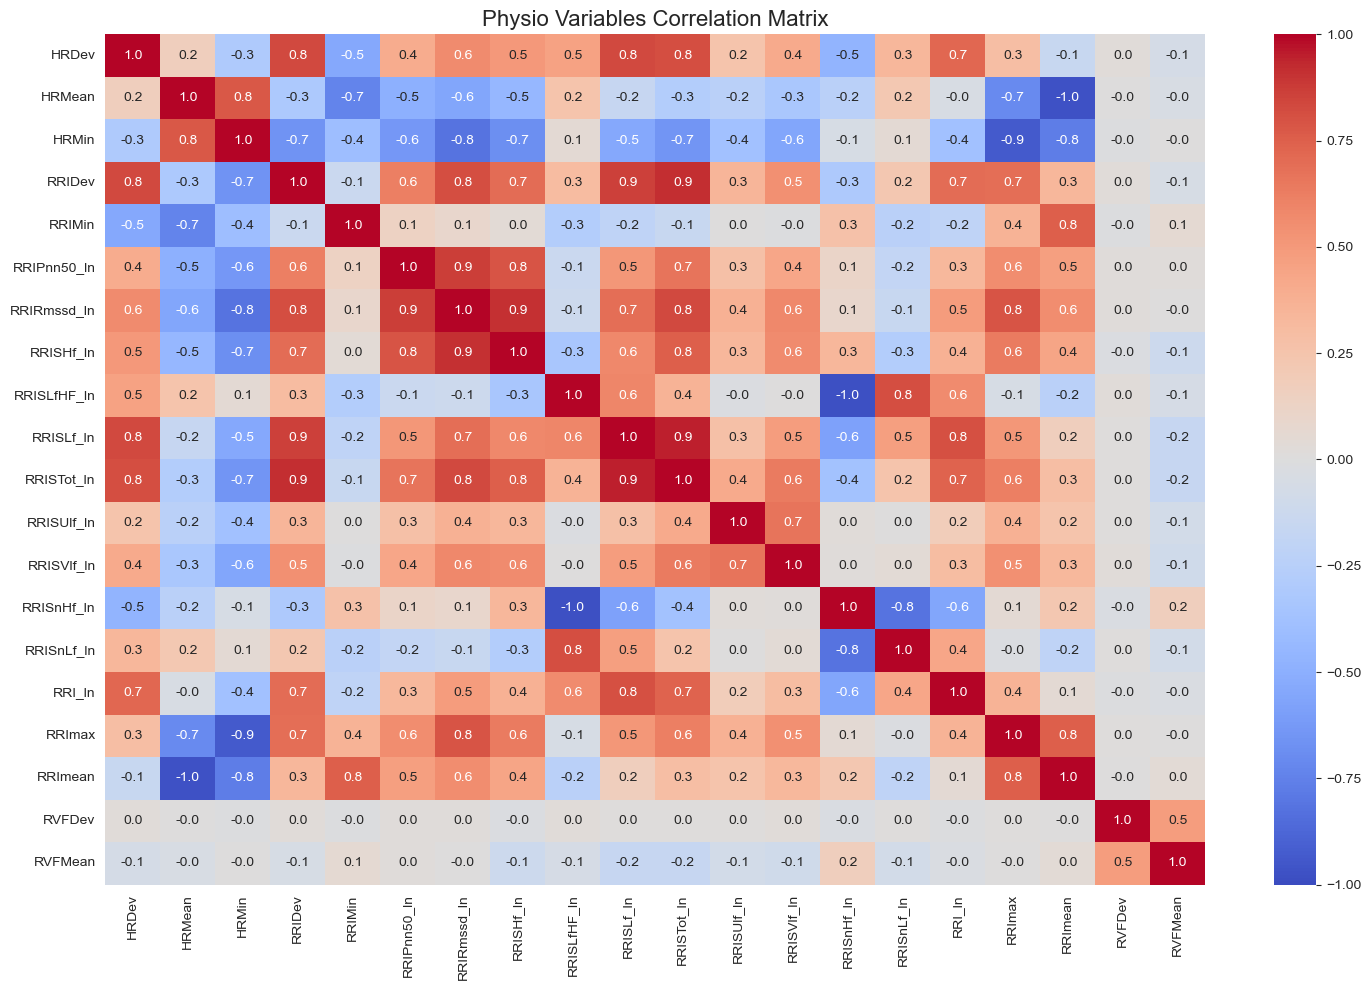

In [124]:
## Full heat matrix of correlations
fig, ax = plt.subplots(figsize=(15,10))
mask = np.triu(np.ones_like(physio_corr_matrix, dtype=bool))
sns.heatmap(
    physio_corr_matrix,
    # mask=mask,  ## toggle on/off the mask to show full matrix or just lower triangle
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1
)

ax.set_title('Physio Variables Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

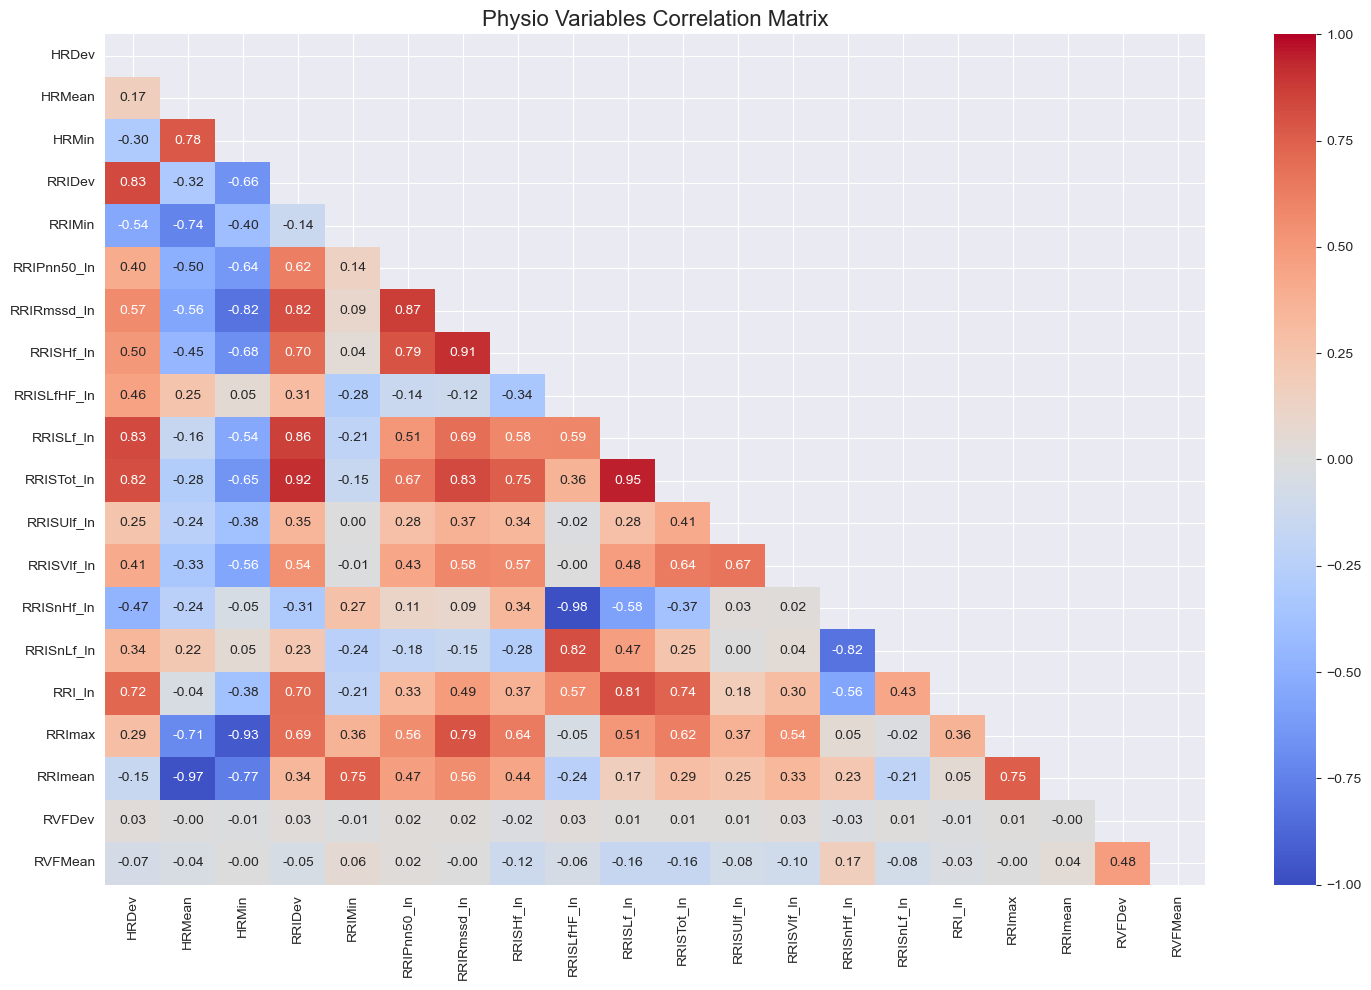

In [125]:
## Triangle correlation matrix (remove upper half)
## Create mask for upper triangle
# fig, ax = plt.subplots(figsize=(20,16))
fig, ax = plt.subplots(figsize=(15,10))
mask = np.triu(np.ones_like(physio_corr_matrix, dtype=bool))

sns.heatmap(
    physio_corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1
)

ax.set_title('Physio Variables Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

#### Modifiable correlation heat matrix column

- This lets you look at correlations against just one variable (target_variable) vs. the entire heat map correlation matrix
- correlation are sorted highest to lowest r value. 

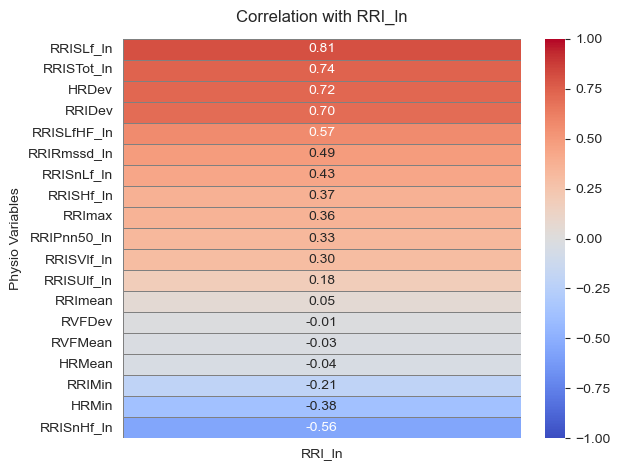

In [126]:
## Single-column heatmap: all physio variables
## change target variable as desired
target_variable = 'RRI_ln'

## Compute correlations of all variables vs HRmean, drop the self-correlation
corr_values = physio_corr_matrix[[target_variable]].drop(index=target_variable).sort_values(by=target_variable, ascending=False)

fig, ax = plt.subplots()

sns.heatmap(
    corr_values,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(f'Correlation with {target_variable}', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Physio Variables', fontsize=10)
plt.tight_layout()
plt.show()

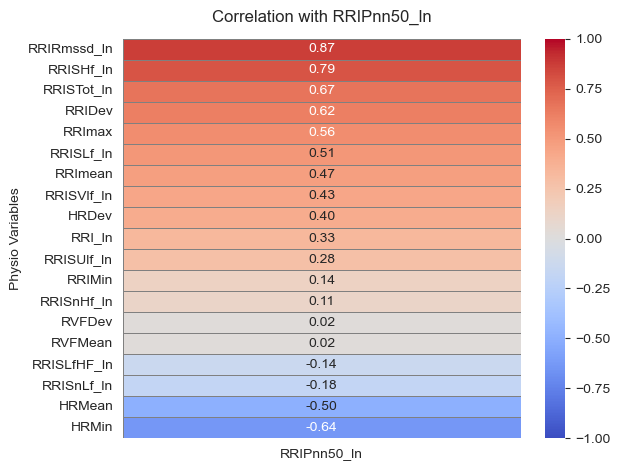

In [127]:
## Single-column heatmap: all physio variables
## change target variable as desired
target_variable = 'RRIPnn50_ln'

## Compute correlations of all variables vs HRmean, drop the self-correlation
corr_values = physio_corr_matrix[[target_variable]].drop(index=target_variable).sort_values(by=target_variable, ascending=False)

fig, ax = plt.subplots()

sns.heatmap(
    corr_values,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(f'Correlation with {target_variable}', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Physio Variables', fontsize=10)
plt.tight_layout()
plt.show()

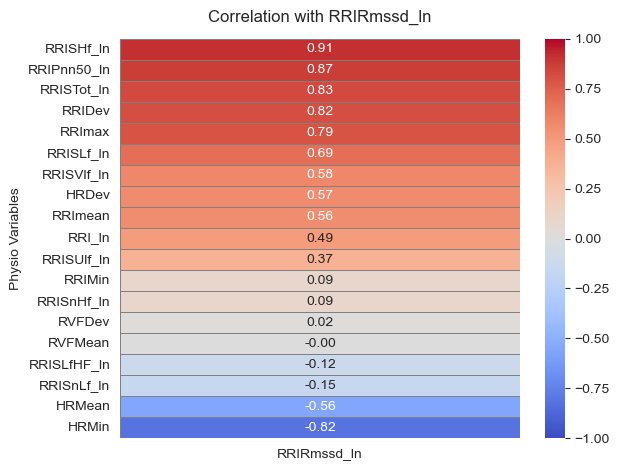

In [128]:
## Single-column heatmap: all physio variables
## change target variable as desired
target_variable = 'RRIRmssd_ln'

## Compute correlations of all variables vs HRmean, drop the self-correlation
corr_values = physio_corr_matrix[[target_variable]].drop(index=target_variable).sort_values(by=target_variable, ascending=False)

fig, ax = plt.subplots()

sns.heatmap(
    corr_values,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(f'Correlation with {target_variable}', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Physio Variables', fontsize=10)
plt.tight_layout()
plt.show()

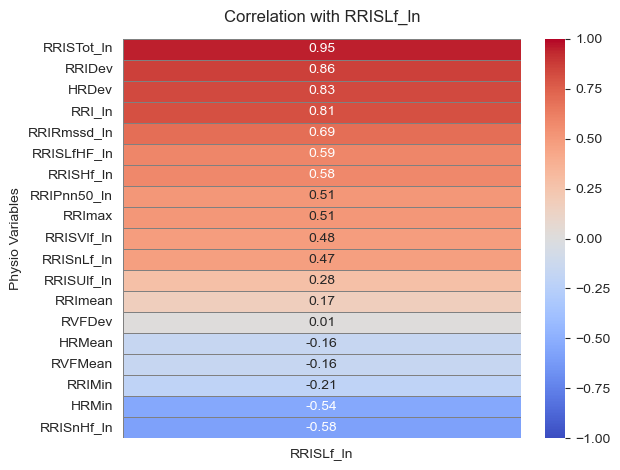

In [129]:
## Single-column heatmap: all physio variables
## change target variable as desired
target_variable = 'RRISLf_ln'

## Compute correlations of all variables vs HRmean, drop the self-correlation
corr_values = physio_corr_matrix[[target_variable]].drop(index=target_variable).sort_values(by=target_variable, ascending=False)

fig, ax = plt.subplots()

sns.heatmap(
    corr_values,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(f'Correlation with {target_variable}', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Physio Variables', fontsize=10)
plt.tight_layout()
plt.show()

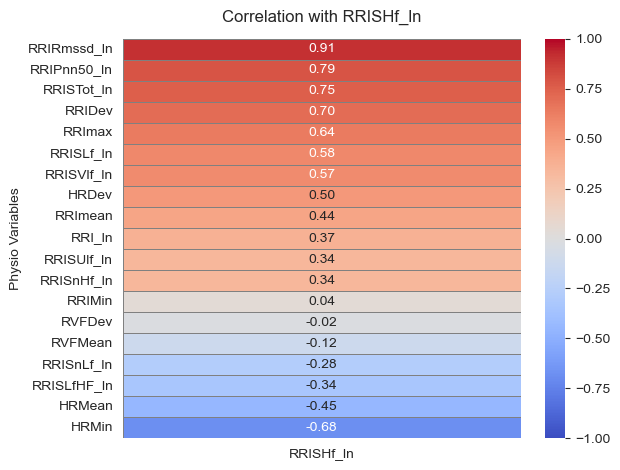

In [130]:
## Single-column heatmap: all physio variables
## change target variable as desired
target_variable = 'RRISHf_ln'

## Compute correlations of all variables vs HRmean, drop the self-correlation
corr_values = physio_corr_matrix[[target_variable]].drop(index=target_variable).sort_values(by=target_variable, ascending=False)

fig, ax = plt.subplots()

sns.heatmap(
    corr_values,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=ax,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='gray'
)

ax.set_title(f'Correlation with {target_variable}', fontsize=12, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Physio Variables', fontsize=10)
plt.tight_layout()
plt.show()

### Check Distribution of main physiological variables.

In [131]:
physio_demo_df[main_physio_vars].astype(dtype=float, errors='ignore')

,HRDev,HRMean,HRMin,RRIDev,RRIMin,RRIPnn50_ln,RRIRmssd_ln,RRISHf_ln,RRISLfHF_ln,RRISLf_ln,RRISTot_ln,RRISUlf_ln,RRISVlf_ln,RRISnHf_ln,RRISnLf_ln,RRI_ln,RRImax,RRImean,RVFDev,RVFMean
0,3.4,87.3,75.9,27.0,616.0,-0.69,2.77,4.62,5.00,5.01,6.40,4.26,5.62,-0.93,-0.53,7.88,791.0,688.0,0.03,0.25
1,6.4,56.2,46.2,117.0,462.0,4.09,4.75,8.23,4.73,8.35,9.13,5.36,6.82,-0.77,-0.65,11.57,1300.0,1079.0,0.08,0.24
2,5.4,49.4,38.5,116.0,802.0,4.27,5.00,8.14,4.74,8.27,9.07,4.81,7.04,-0.77,-0.64,10.45,1560.0,1227.0,0.04,0.30
3,4.6,71.4,61.4,54.0,729.0,3.90,4.06,7.10,3.64,6.14,7.64,3.14,5.93,-0.33,-1.29,9.18,977.0,843.0,0.03,0.27
4,5.5,63.2,53.4,77.0,710.0,4.12,4.37,7.14,4.58,7.11,8.33,5.81,7.18,-0.69,-0.72,10.05,1124.0,955.0,0.04,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1383,NaN,73.2,NaN,130.0,NaN,3.68,4.32,6.66,NaN,9.51,9.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1384,NaN,89.4,NaN,53.0,NaN,1.76,3.22,5.23,NaN,7.50,7.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1386,NaN,64.1,NaN,143.0,NaN,3.85,4.49,7.24,NaN,9.11,9.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Histograms of all main physio variables by timepoint and group

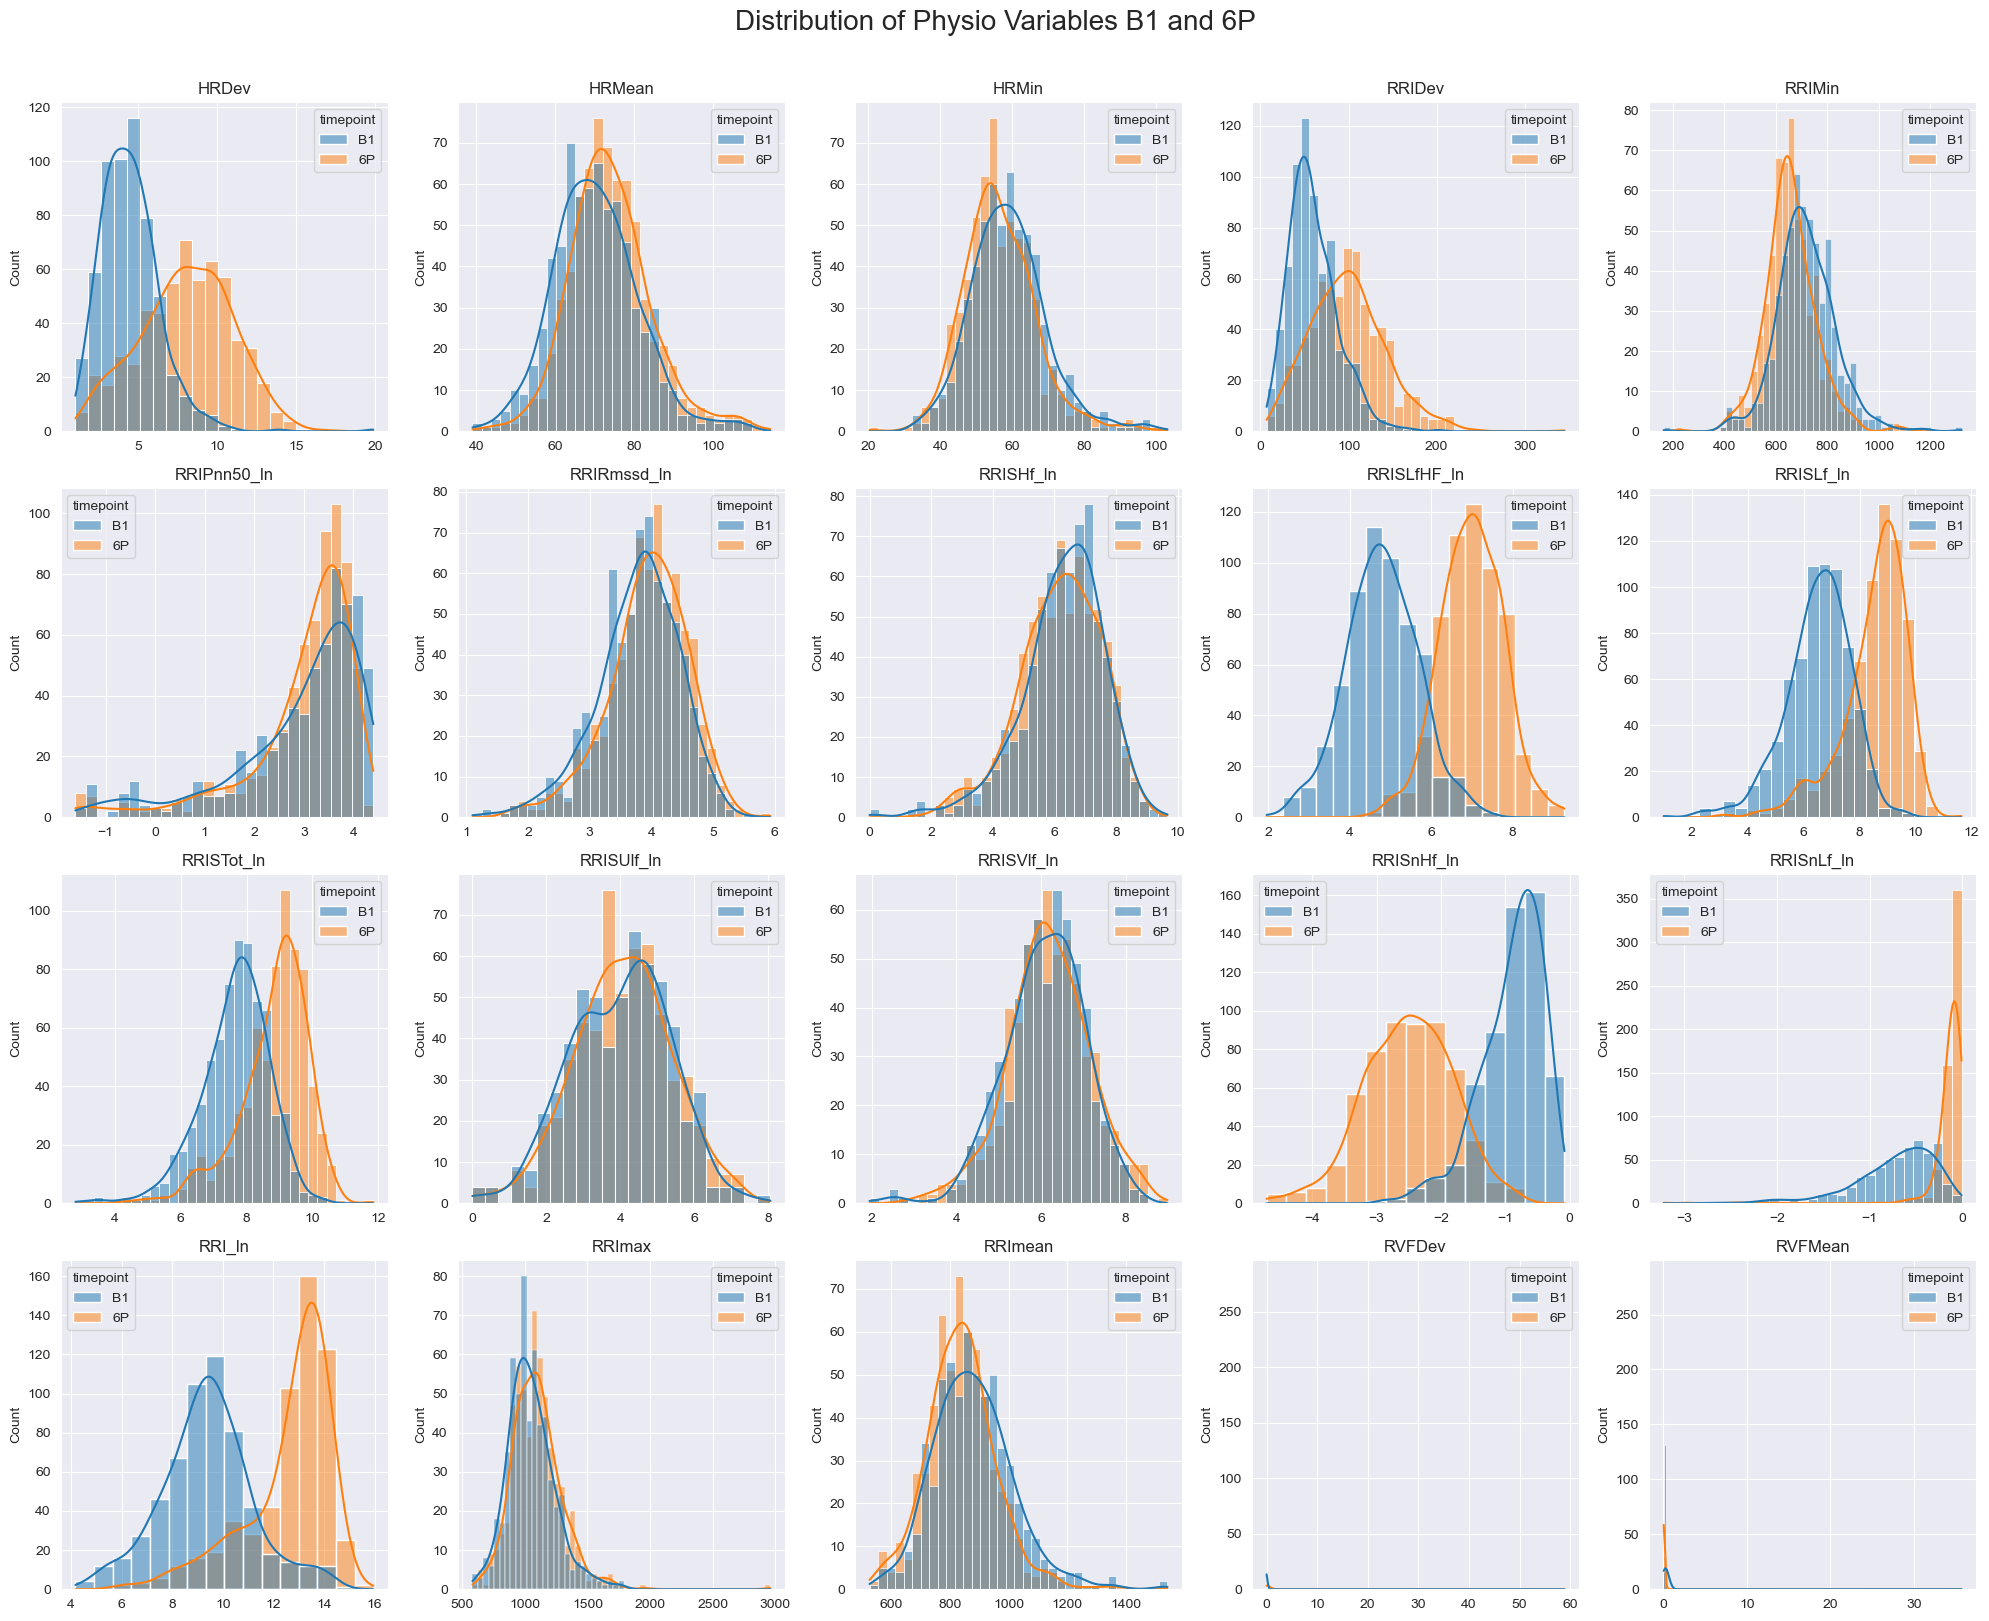

In [132]:
# physio_df_b1

ncols = 5 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.histplot(data=physio_demo_df, x=var, hue= 'timepoint', hue_order=['B1', '6P'], multiple= 'layer', kde=True, ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    # axes[i].axvline(physio_demo_df[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    # axes[i].axvline(float(physio_demo_df[var].median()), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables B1 and 6P', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

#### 3-Group Pointplot for main physio variables

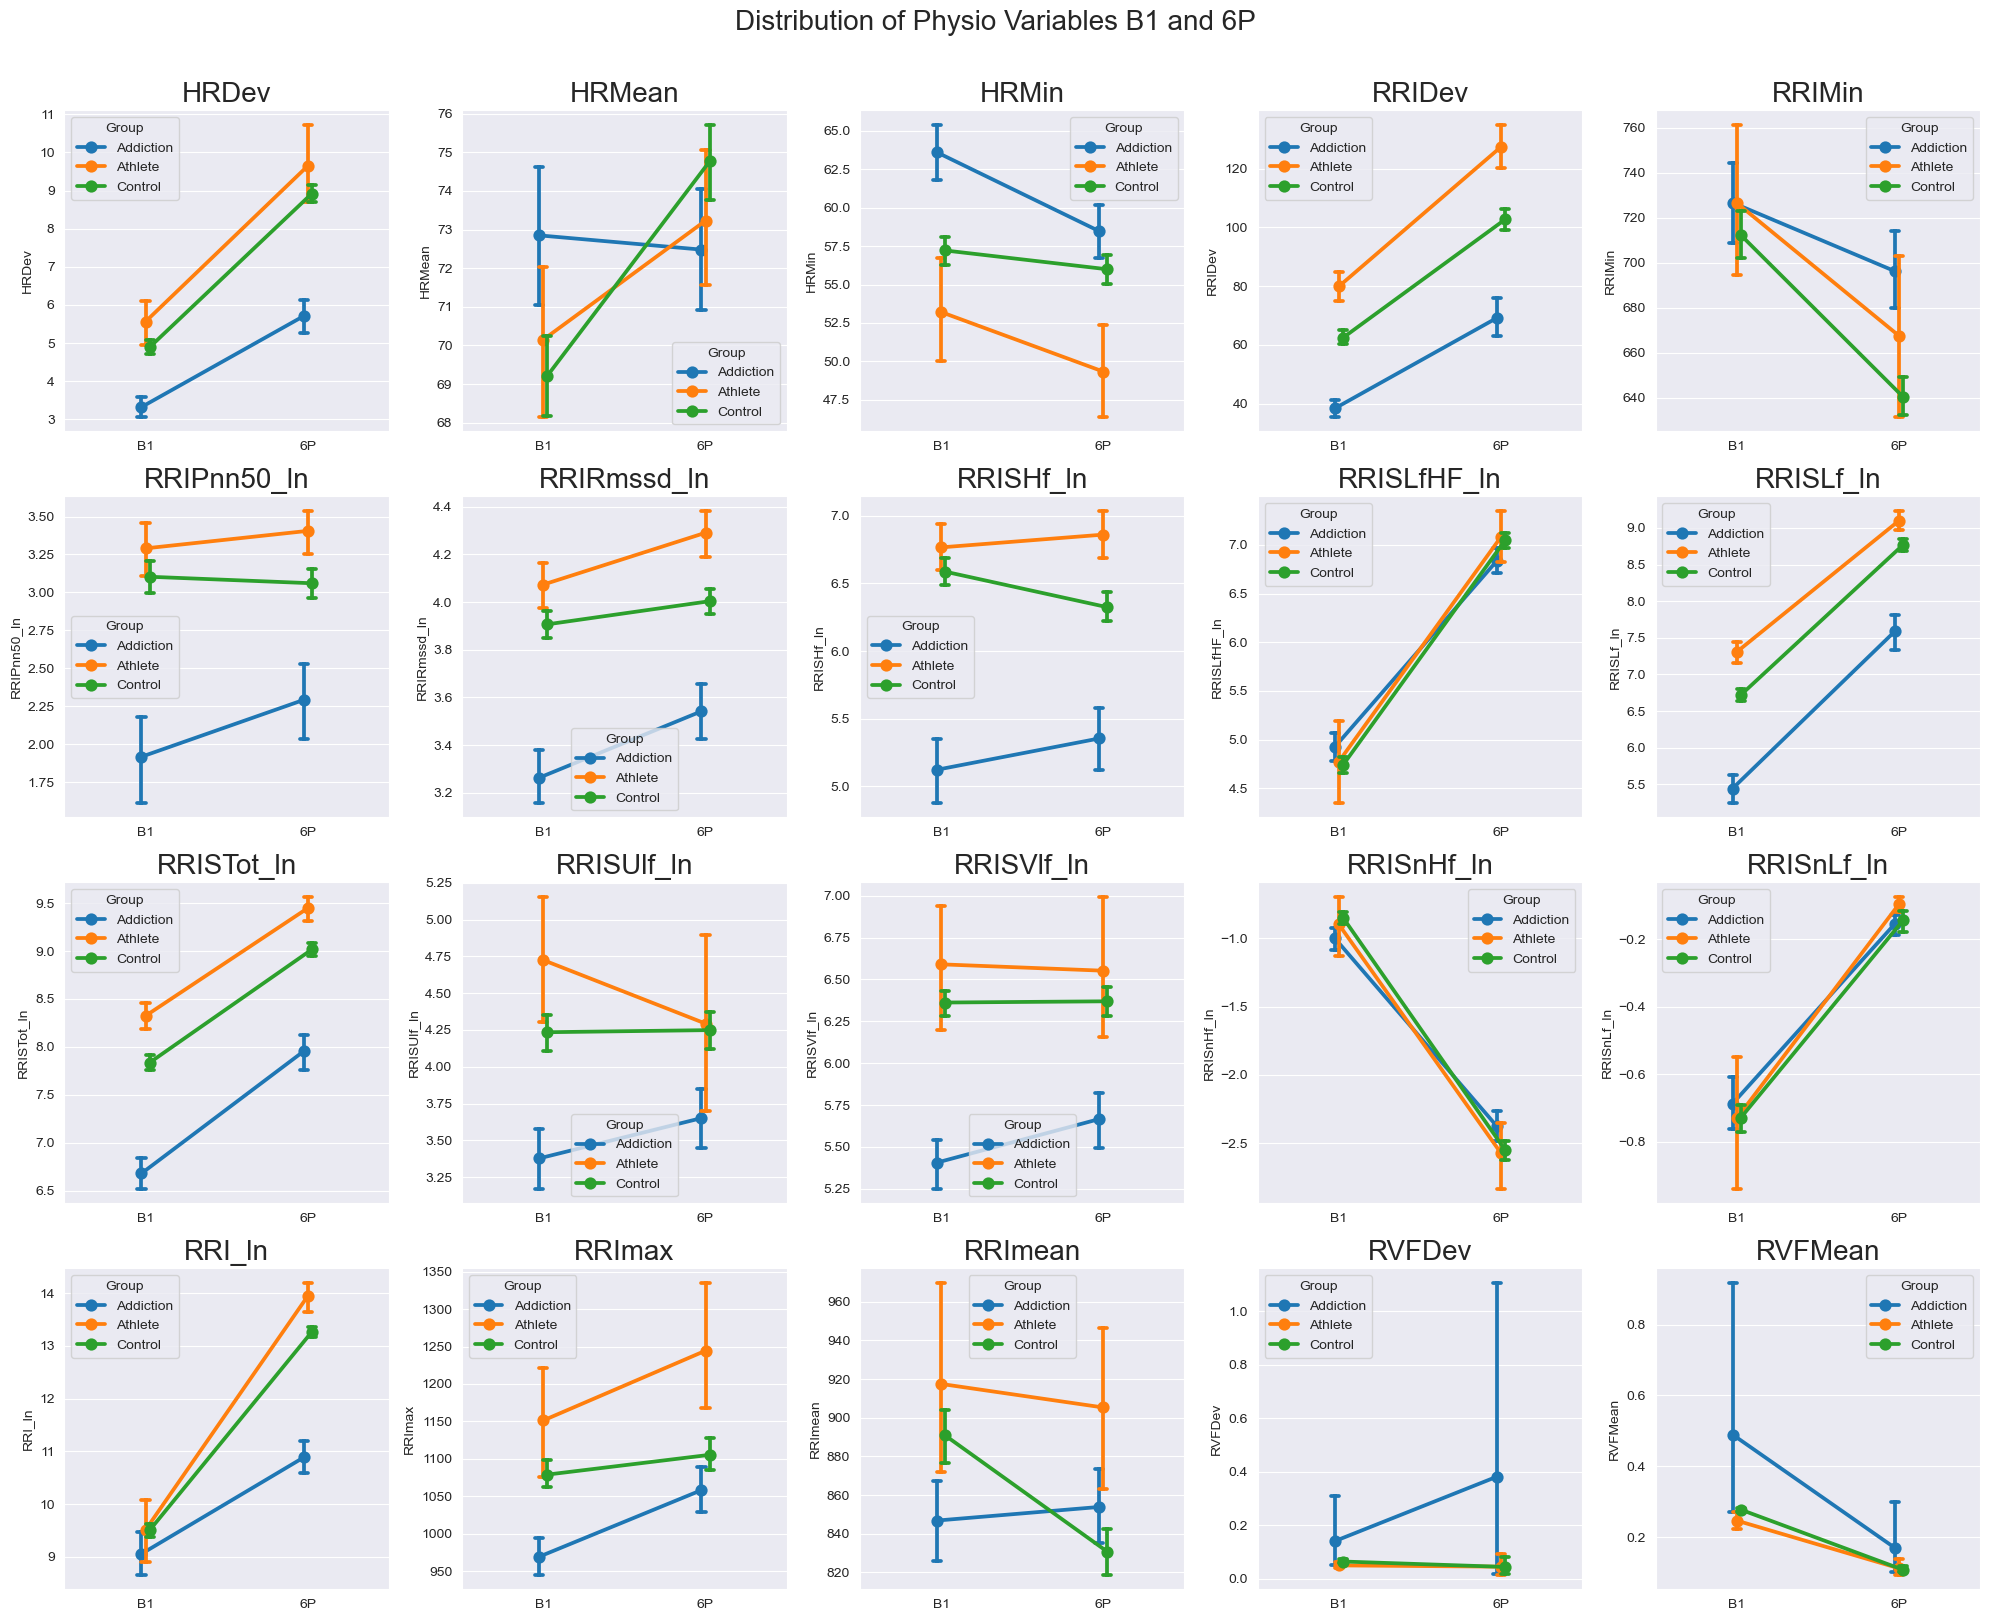

In [133]:
ncols = 5 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.pointplot(data=physio_demo_df, x='timepoint', y=var, hue= 'Group', capsize=0.05, dodge=0.05, ax=axes[i])
    axes[i].set_title(var, fontsize=20)
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables B1 and 6P', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

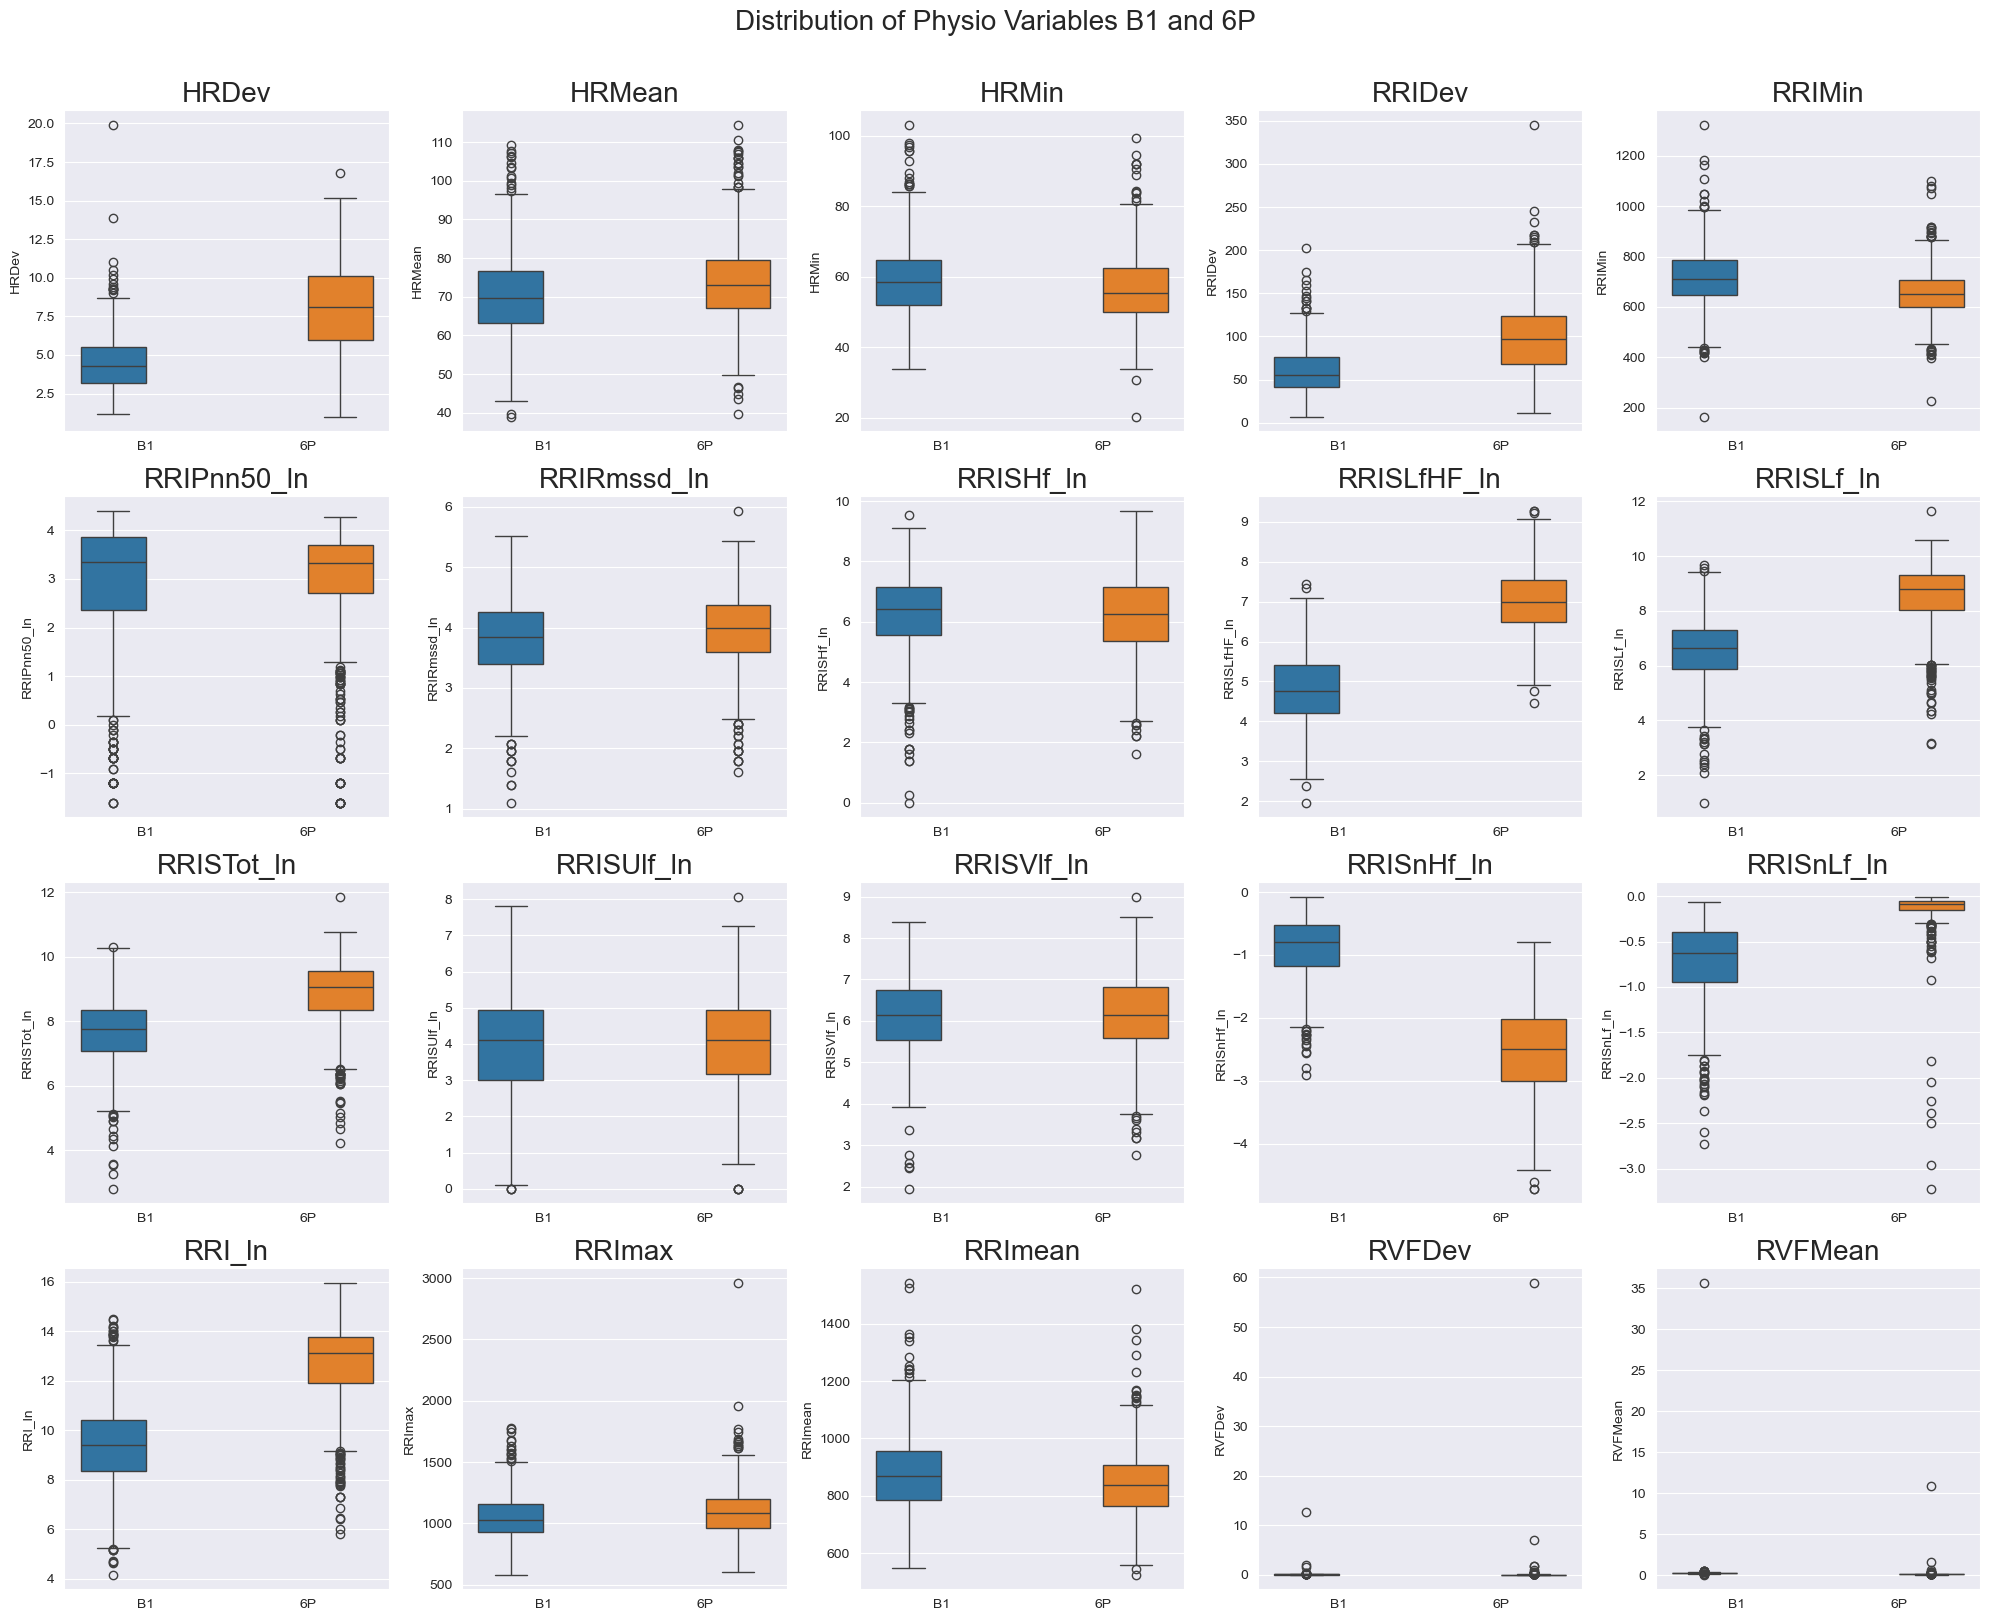

In [134]:
ncols = 5 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.boxplot(data=physio_demo_df, x='timepoint', y=var, hue='timepoint', dodge=0.05, ax=axes[i])
    axes[i].set_title(var, fontsize=20)
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables B1 and 6P', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

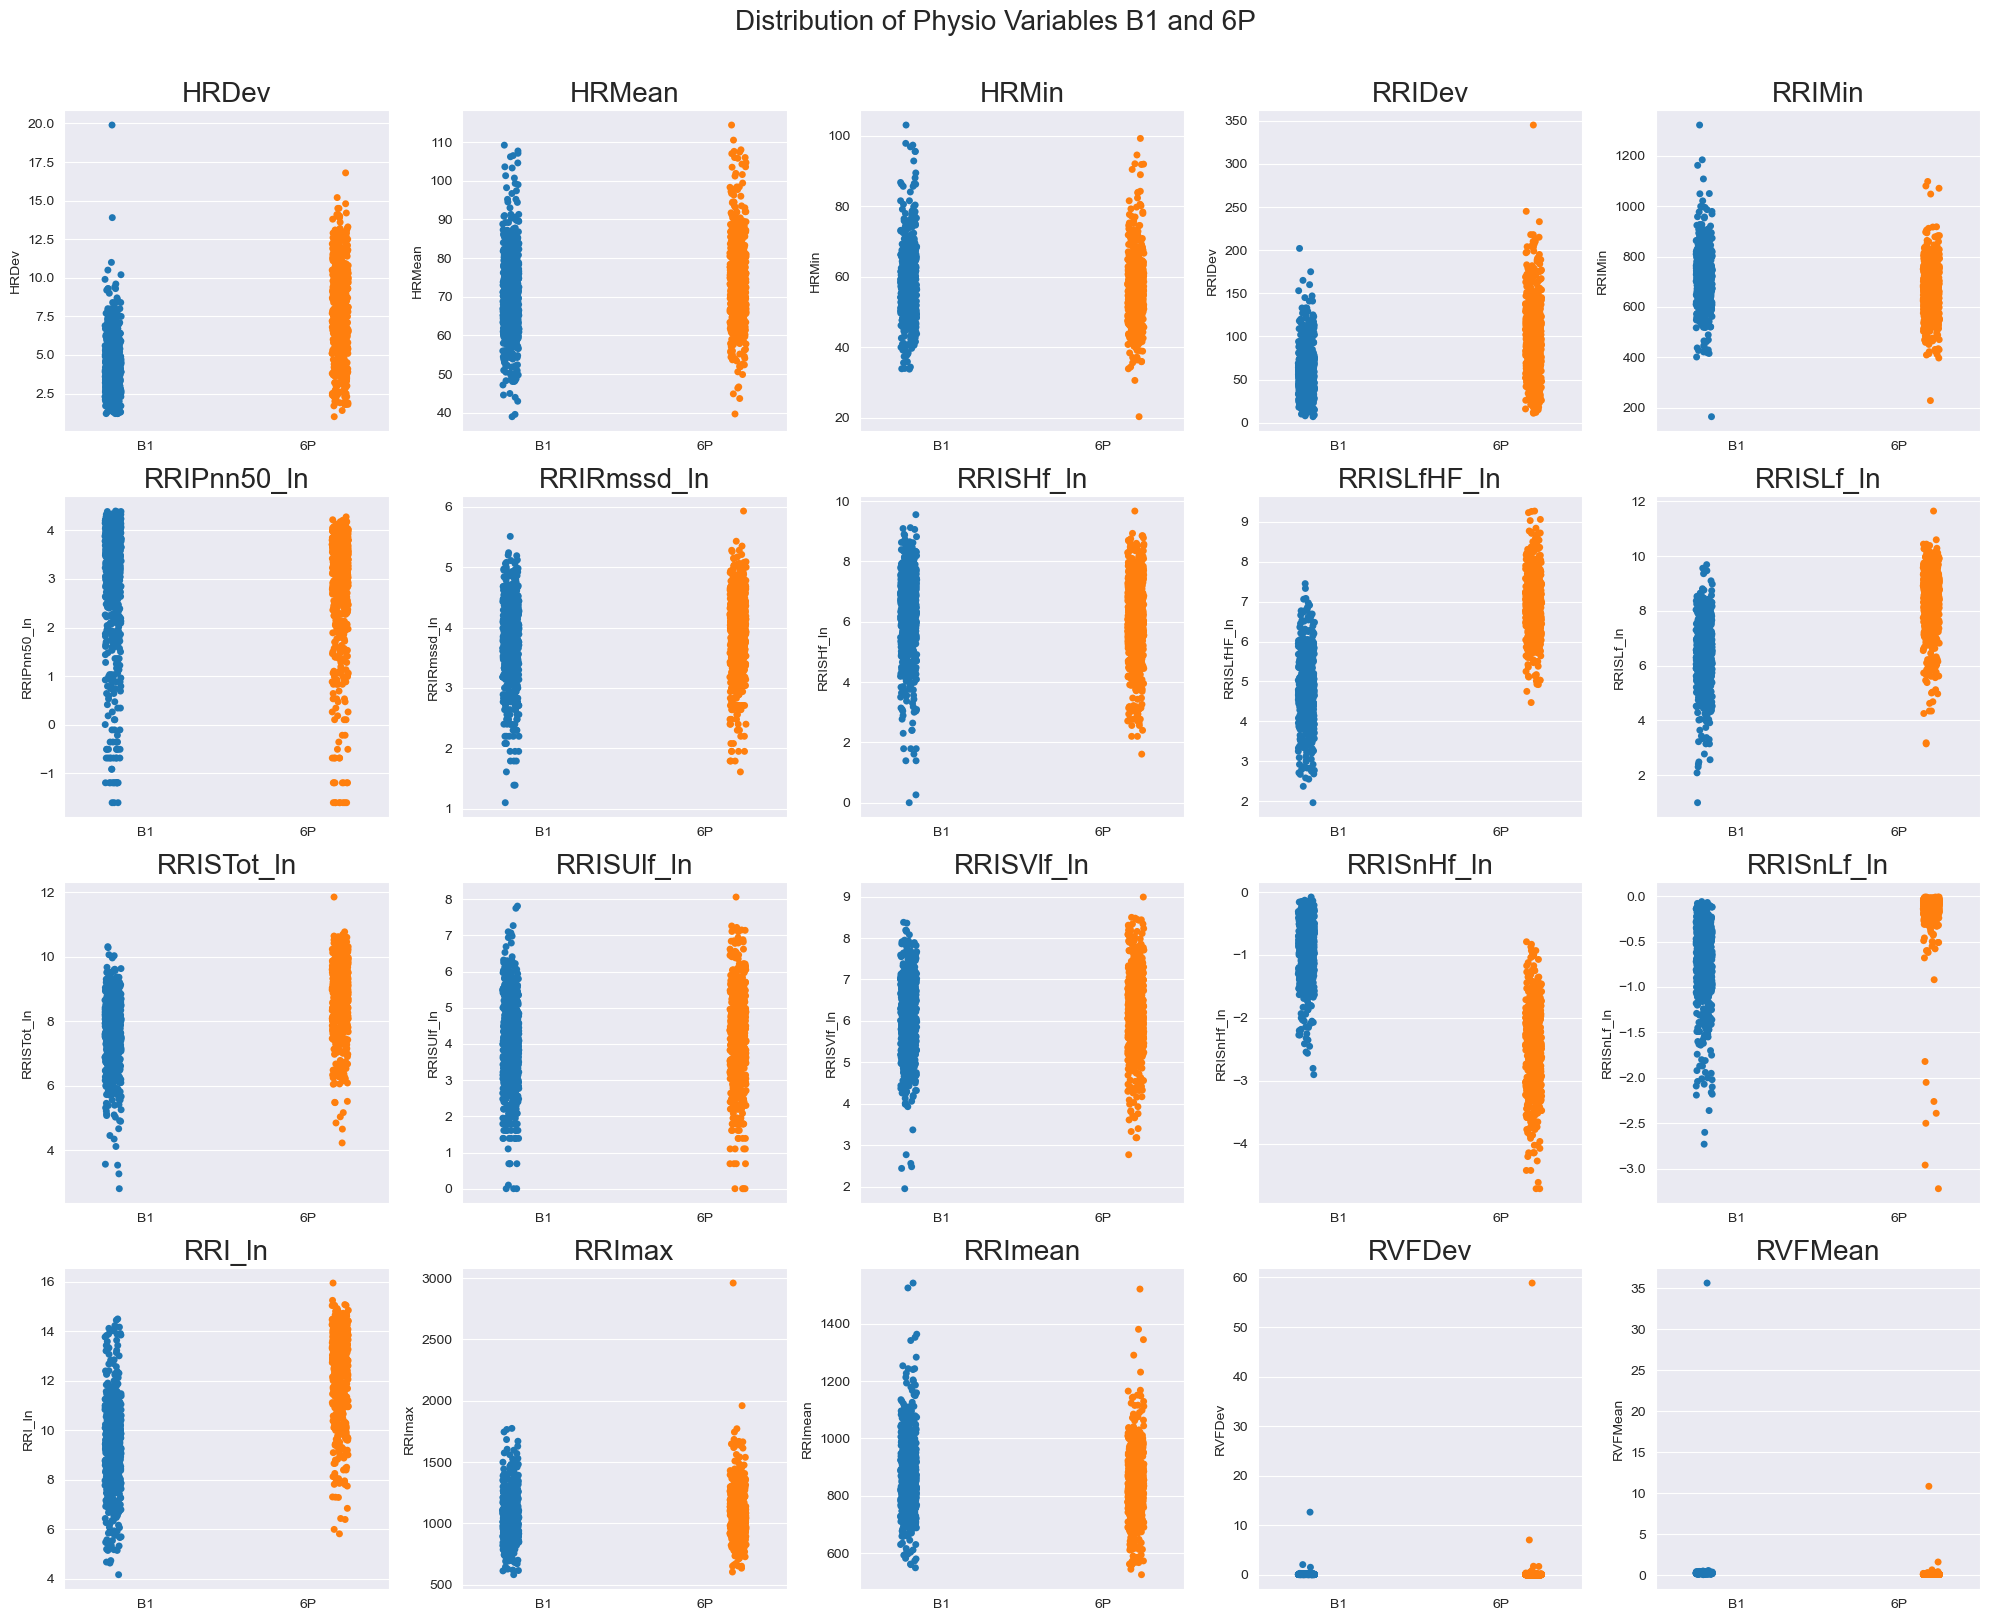

In [135]:
ncols = 5 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.stripplot(data=physio_demo_df, x='timepoint', y=var, hue='timepoint', dodge=0.05, ax=axes[i])
    axes[i].set_title(var, fontsize=20)
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables B1 and 6P', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

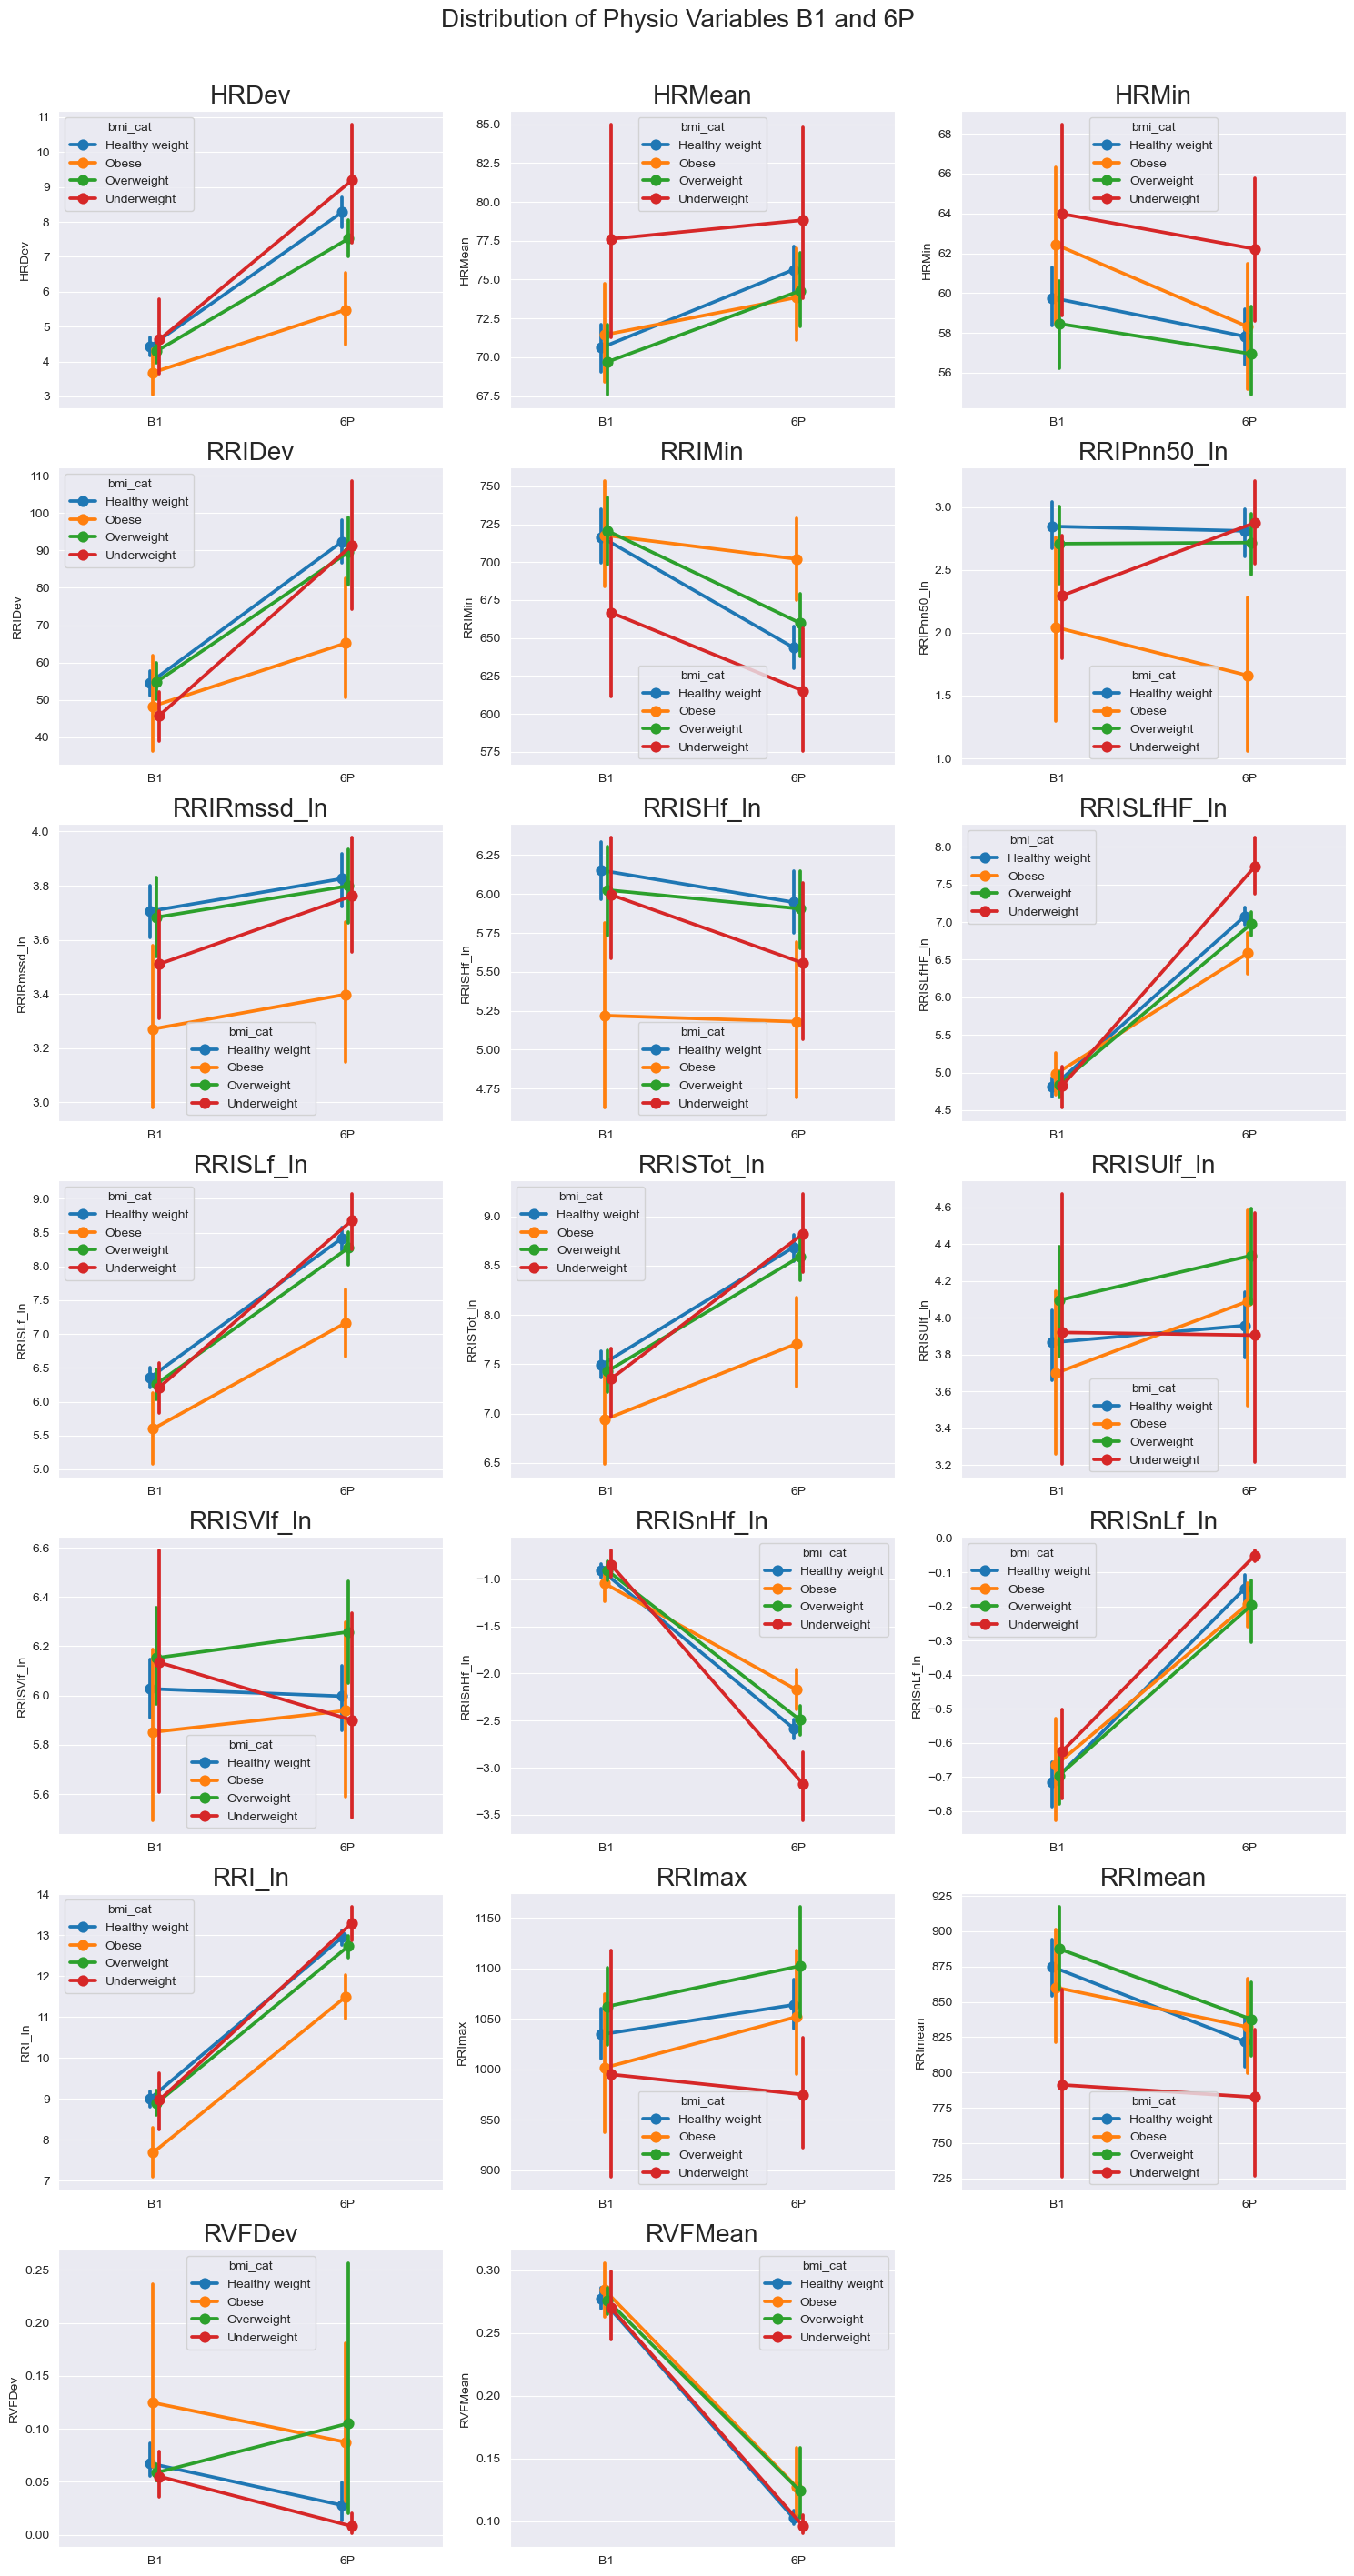

In [136]:
ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.pointplot(data=physio_demo_df, x='timepoint', y=var, hue= 'bmi_cat', dodge=0.05, ax=axes[i])
    axes[i].set_title(var, fontsize=20)
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables B1 and 6P', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

## Statistics

### Descriptive Statistics

In [137]:
physio_demo_df.groupby(['Group'], observed=True)[['age', 'height', 'weight', 'bmi']].agg(['mean', 'std']).round(2).T

Group        Addiction  Athlete  Control
age    mean      39.44    19.48    21.28
       std       13.99     1.11     1.41
height mean       1.64      NaN     1.69
       std        0.06      NaN     0.09
weight mean      72.78      NaN    69.19
       std       14.38      NaN    13.62
bmi    mean      27.04      NaN    23.94
       std        5.40      NaN     3.47

In [138]:
## A look at descriptive statistics for the main physiological variables, by timepoint
## Can be used for quick reference and to use for manually constructing plots with this descriptive df as the source (e.g., error bars, boxplot whiskers, etc.)

descriptives_df = (physio_demo_df
.groupby('timepoint', observed=False)[main_physio_vars]
 .describe()
 .round(2)
.stack(level=0)
.rename_axis(['timepoint', 'variable'])
.reset_index()
.reindex(columns=['variable', 'timepoint'] + ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'])
)

descriptives_df.sort_values(by=['timepoint', 'variable'], ascending=[False, True], inplace=True)

descriptives_df.head(10)

/var/folders/7d/370678cs0jzdr2slyl3k7m2w0000gn/T/ipykernel_66374/4243809309.py:8: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=0)


,variable,timepoint,count,mean,std,min,25%,50%,75%,max
20,HRDev,B1,585.0,4.47,1.88,1.20,3.20,4.30,5.50,19.90
21,HRMean,B1,694.0,70.27,10.80,39.00,63.20,69.70,76.70,109.20
22,HRMin,B1,585.0,58.89,10.53,33.80,51.90,58.50,64.80,103.10
23,RRIDev,B1,694.0,59.92,27.72,7.00,41.00,55.00,76.00,202.00
24,RRIMin,B1,585.0,716.92,114.75,164.00,648.00,710.00,786.00,1322.00
25,RRIPnn50_ln,B1,655.0,2.90,1.33,-1.61,2.36,3.34,3.86,4.40
26,RRIRmssd_ln,B1,694.0,3.78,0.67,1.10,3.40,3.85,4.26,5.51
27,RRISHf_ln,B1,694.0,6.27,1.34,0.00,5.56,6.42,7.15,9.55
28,RRISLfHF_ln,B1,585.0,4.79,0.88,1.96,4.21,4.77,5.40,7.45
29,RRISLf_ln,B1,694.0,6.52,1.17,0.99,5.87,6.64,7.30,9.69


### Data normality assessment

In [139]:
import pingouin as pg

In [140]:
physio_df_b1 = physio_demo_df[physio_demo_df['timepoint'] == 'B1'].copy().reset_index(drop=True)

physio_df_b1.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,4.26,5.62,5.01,4.62,5.00,-0.53,-0.93,7.88,2.77,-0.69
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,5.36,6.82,8.35,8.23,4.73,-0.65,-0.77,11.57,4.75,4.09
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,4.81,7.04,8.27,8.14,4.74,-0.64,-0.77,10.45,5.00,4.27
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,3.14,5.93,6.14,7.10,3.64,-1.29,-0.33,9.18,4.06,3.90
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,5.81,7.18,7.11,7.14,4.58,-0.72,-0.69,10.05,4.37,4.12


**Note:** There are multiple, different iterations of the 'main' physiology variables plotted below:

- Timepoint (B1 or 6P) is specified by color, when applicable.

1) histograms of each physiology variable where the red dashed line = median (good for visual inspection of skewness)
2) Boxplot of each physiology variable (my personal favorite for examining data distribution between categorical variables).
3) Stripplot of each physiology variable, shows individual datapoints (has overlap) for general density of distribution
4) Violin plot of each physiogy variable, shows density distribution (similar to Boxplot + stripplot combined).

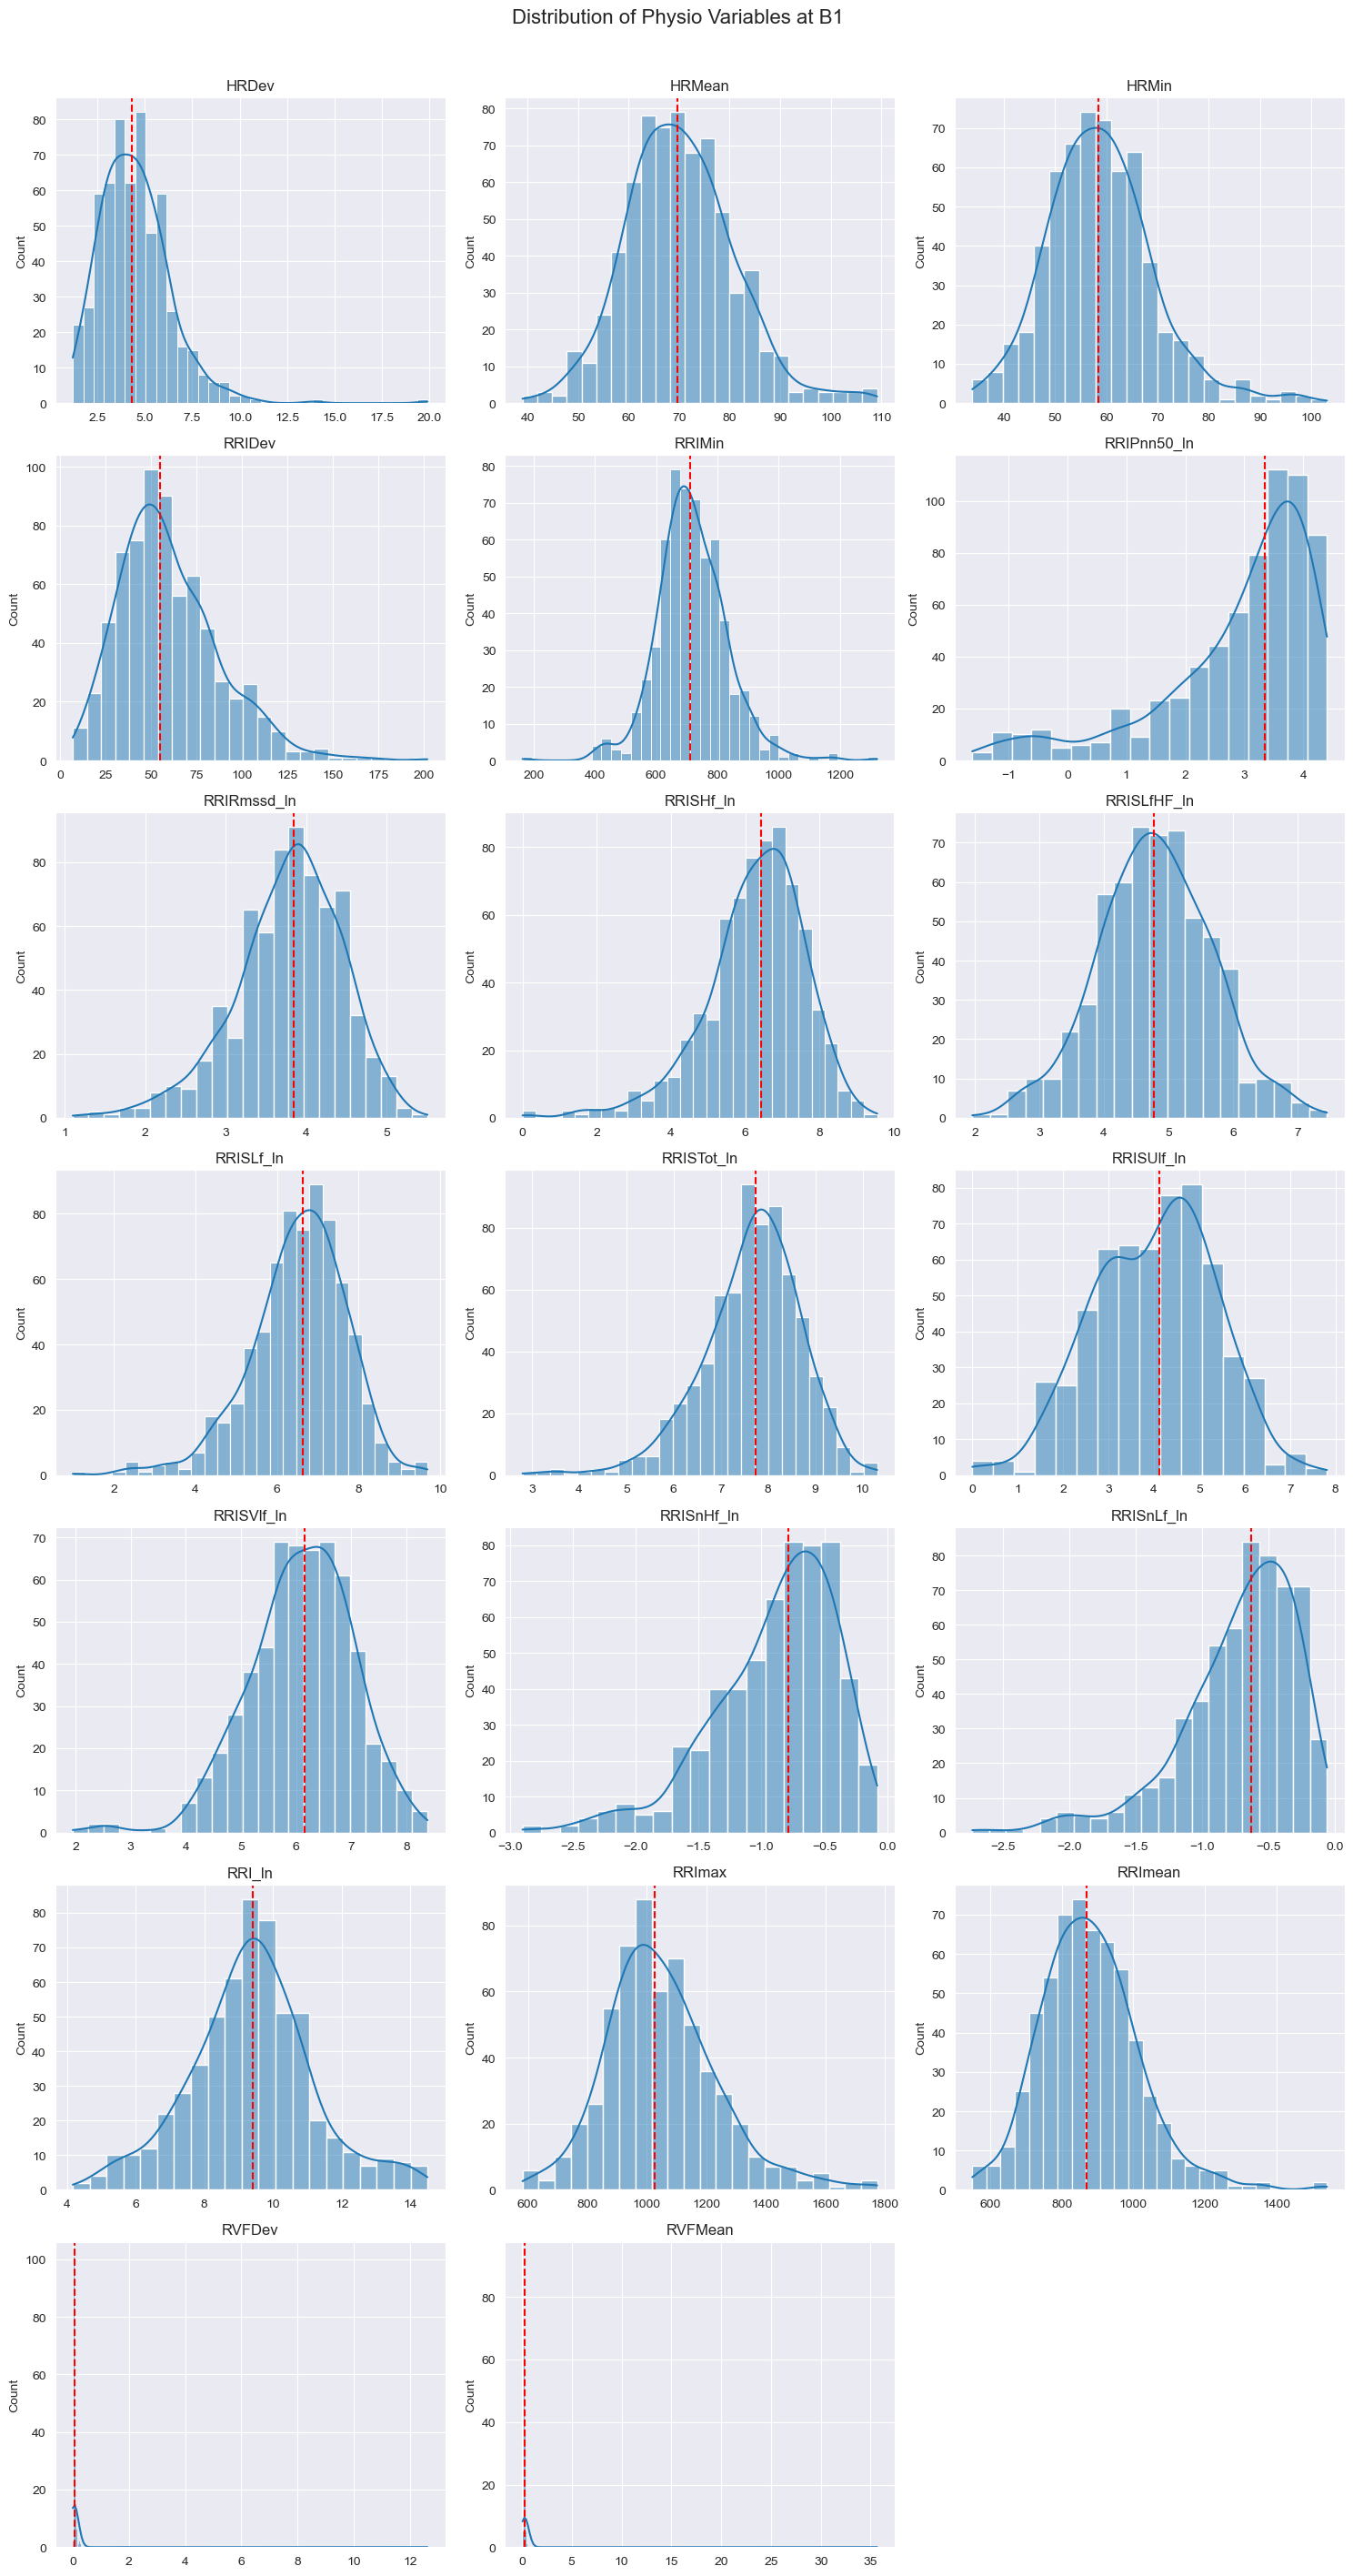

In [141]:
physio_df_b1

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.histplot(data=physio_df_b1, x=var, kde=True, ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [142]:
# physio_df_b1

# ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
# nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
# axes = axes.flatten()

# for i, var in enumerate(main_physio_vars):
#     sns.boxplot(data=physio_demo_df, y='timepoint', x=var, hue='timepoint', ax=axes[i])
#     axes[i].set_title(var, fontsize=12)
#     # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
#     # axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
#     axes[i].set_xlabel('')

# # hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
# for j in range(i + 1, len(axes)):
#     axes[j].set_visible(False)

# plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
# plt.tight_layout()
# plt.show()

In [143]:

# ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
# nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
# axes = axes.flatten()

# for i, var in enumerate(main_physio_vars):
#     sns.stripplot(data=physio_demo_df, y='timepoint', x=var, hue='timepoint', ax=axes[i])
#     axes[i].set_title(var, fontsize=12)
#     # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
#     # axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
#     axes[i].set_xlabel('')

# # hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
# for j in range(i + 1, len(axes)):
#     axes[j].set_visible(False)

# plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
# plt.tight_layout()
# plt.show()

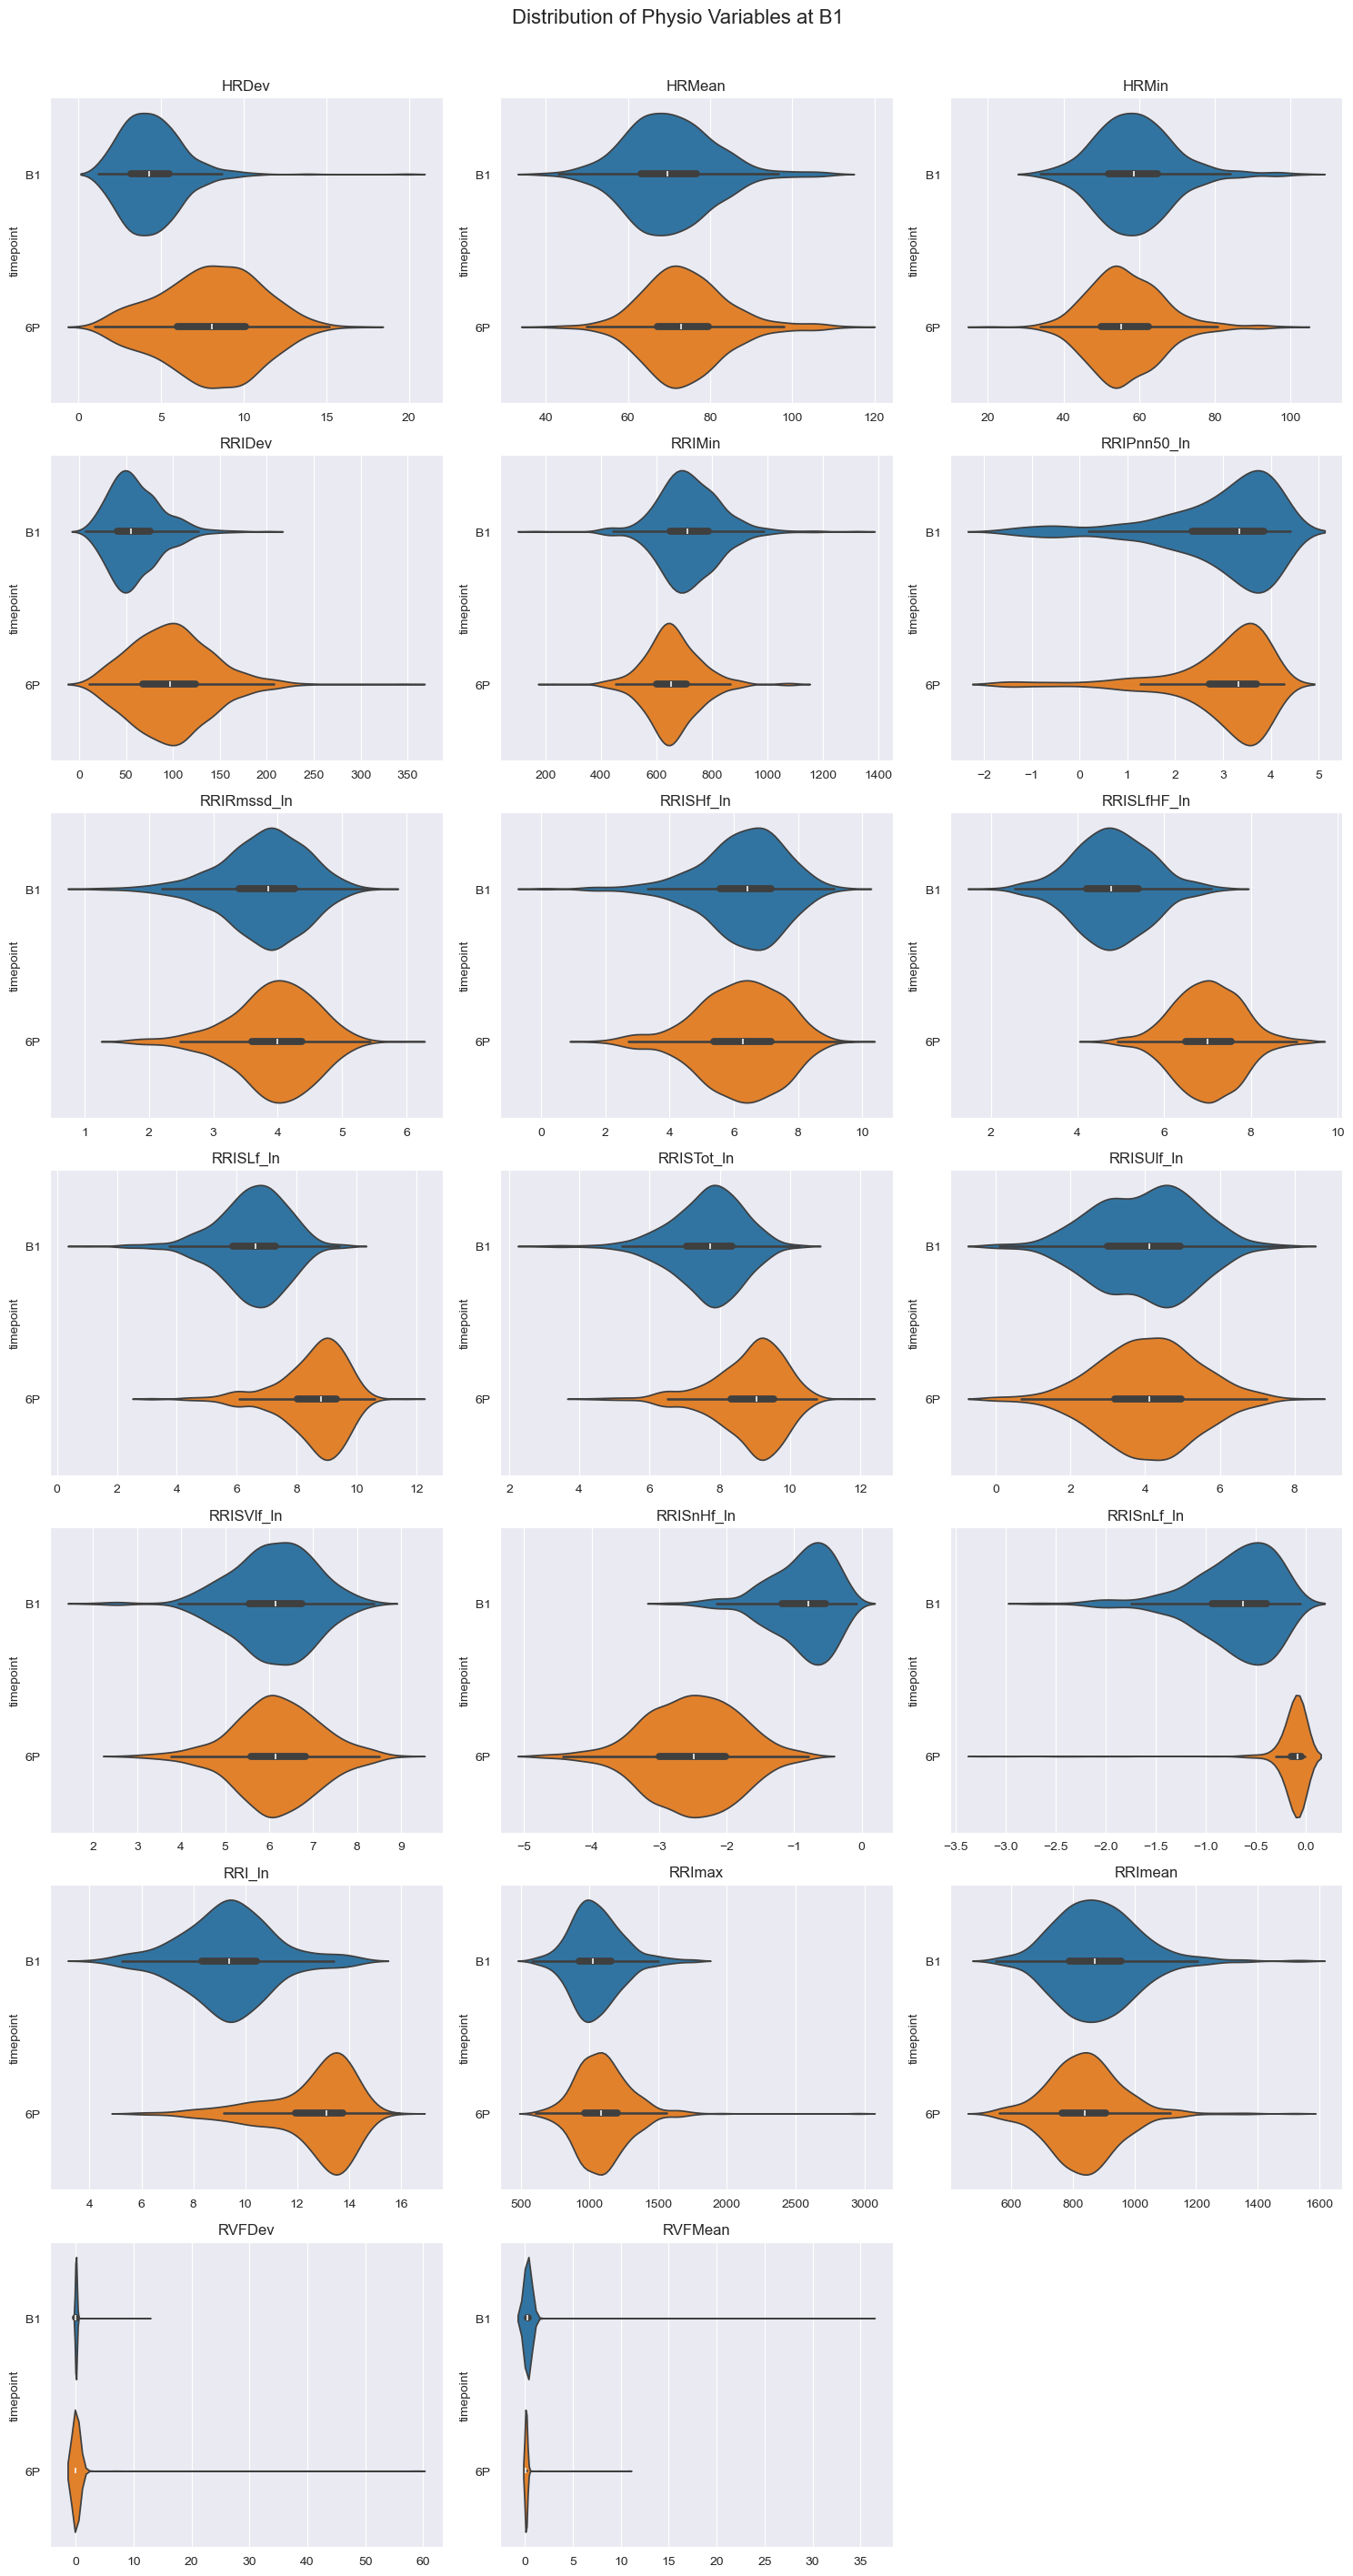

In [144]:

ncols = 3 ## want to display visuals in 3 columns per row ~20 variables in total.
nrows = math.ceil(len(main_physio_vars) / ncols)  # = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(main_physio_vars):
    sns.violinplot(data=physio_demo_df, y='timepoint', x=var, hue='timepoint', ax=axes[i])
    axes[i].set_title(var, fontsize=12)
    # axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3) ### adds values to bars but is messy given the # of bins
    # axes[i].axvline(physio_df_b1[var].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].set_xlabel('')

# hide the 2 unused subplots in the last row (21 cells - 20 vars = 1 empty)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Physio Variables at B1', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [145]:
physio_df_b1[all_physio_vars].columns

Index(['RRIMin', 'RRImax', 'RRImean', 'RRIDev', 'HRMin', 'HRMean', 'HRDev',
       'RRISTot', 'RRISUlf', 'RRISVlf', 'RRISLf', 'RRISHf', 'RRISLfHF',
       'RRISnLf', 'RRISnHf', 'RRI', 'RRIRmssd', 'RRIPnn50', 'RRISTot_ln',
       'RRISUlf_ln', 'RRISVlf_ln', 'RRISLf_ln', 'RRISHf_ln', 'RRISLfHF_ln',
       'RRISnLf_ln', 'RRISnHf_ln', 'RRI_ln', 'RRIRmssd_ln', 'RRIPnn50_ln',
       'RVFMean', 'RVFDev'],
      dtype='object')

In [146]:
normality_results = []

for var in main_physio_vars:
    result = pg.normality(physio_df_b1[var].dropna(), method='shapiro').round(3)
    result.insert(0, 'variable', var)
    normality_results.append(result)

normality_results_df = pd.concat(normality_results, ignore_index=True)
normality_results_df = pd.DataFrame(normality_results_df)
normality_results_df['Reject_null'] = normality_results_df['pval'].map(lambda x: 'Yes' if x < 0.05 else 'No')

normality_results_df


,variable,W,pval,normal,Reject_null
0,HRDev,0.918,0.000,False,Yes
1,HRMean,0.986,0.000,False,Yes
2,HRMin,0.972,0.000,False,Yes
3,RRIDev,0.953,0.000,False,Yes
4,RRIMin,0.969,0.000,False,Yes
5,RRIPnn50_ln,0.843,0.000,False,Yes
6,RRIRmssd_ln,0.978,0.000,False,Yes
7,RRISHf_ln,0.959,0.000,False,Yes
8,RRISLfHF_ln,0.998,0.788,True,No
9,RRISLf_ln,0.973,0.000,False,Yes


### **Normality Summary:** 

**Date written/updated:** 4-30-26

Based on Shapiro-Wilke test of normality, the following physiology variables are normally distributed:
- RRISLfHF_ln
- RRI_ln

all other variables in 'main_physio_vars' are considered to have non-normal data distribution.

**Moving Forward:**

Consider whether or not further data cleaning, modification needs to occur (e.g., alternative transformation?) and which tests to run (paramatric vs. non-parametric) based on the research questions/hypotheses. 


### **T-tests**

**Note:**

Based on previous descriptive statistics and tests of normality, determine which variables should be tested with parametric vs. non-paremetric tests
- e.g., Dependent samples T-test vs. Wilcoxon signed-rank test

In [147]:
## Running pairwise t-tests for each main physiological variable across timepoints, with Bonferroni correction for multiple comparisons.
ttest_results = []

for var in main_physio_vars:
    result = pg.pairwise_tests(data=physio_demo_df, dv=var, between='timepoint', subject = 'ID6', padjust='none').round(3)
    result.insert(0, 'variable', var)
    ttest_results.append(result)

ttest_results_df = pd.concat(ttest_results, ignore_index=True)
ttest_results_df = pd.DataFrame(ttest_results_df)
ttest_results_df['Reject_null'] = ttest_results_df['p-unc'].map(lambda p: 'Yes' if p < 0.05 else 'No')

ttest_results_df


,variable,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges,Reject_null
0,HRDev,timepoint,6P,B1,False,True,24.815,1168.000,two-sided,0.000,3.947e+105,1.450,Yes
1,HRMean,timepoint,6P,B1,False,True,6.411,1378.465,two-sided,0.000,3.102e+07,0.345,Yes
2,HRMin,timepoint,6P,B1,False,True,-4.047,1168.000,two-sided,0.000,202.577,-0.236,Yes
3,RRIDev,timepoint,6P,B1,False,True,20.068,1171.550,two-sided,0.000,1.109e+75,1.082,Yes
4,RRIMin,timepoint,6P,B1,False,True,-9.539,1168.000,two-sided,0.000,4.516e+17,-0.557,Yes
5,RRIPnn50_ln,timepoint,6P,B1,False,True,0.838,1286.477,two-sided,0.402,0.087,0.046,No
6,RRIRmssd_ln,timepoint,6P,B1,False,True,4.513,1378.691,two-sided,0.000,1339.676,0.243,Yes
7,RRISHf_ln,timepoint,6P,B1,False,True,-1.174,1378.962,two-sided,0.240,0.119,-0.063,No
8,RRISLfHF_ln,timepoint,6P,B1,False,True,45.510,1168.000,two-sided,0.000,3.711e+256,2.659,Yes
9,RRISLf_ln,timepoint,6P,B1,False,True,32.237,1378.875,two-sided,0.000,1.78e+166,1.734,Yes


In [148]:
## Post-hoc Games-Howell test for pairwise comparisons across timepoints for each main physiological variable, which does not assume equal variances or sample sizes.

games_howell_results = []

for var in main_physio_vars:
    result = pg.pairwise_gameshowell(data=physio_demo_df, dv=var, between='timepoint').round(3)
    result.insert(0, 'variable', var)
    games_howell_results.append(result)
    games_howell_results_df = pd.concat(games_howell_results, ignore_index=True)
    games_howell_results_df['Reject_null'] = games_howell_results_df['pval'].map(lambda p: 'Yes' if p < 0.05 else 'No')

games_howell_results_df = pd.DataFrame(games_howell_results_df)

games_howell_results_df




,variable,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges,Reject_null
0,HRDev,6P,B1,8.031,4.465,3.565,0.144,24.815,998.616,0.000,1.450,Yes
1,HRMean,6P,B1,73.936,70.266,3.671,0.573,6.411,1378.465,0.000,0.345,Yes
2,HRMin,6P,B1,56.459,58.893,-2.434,0.601,-4.047,1165.332,0.000,-0.236,Yes
3,RRIDev,6P,B1,98.985,59.924,39.062,1.946,20.068,1171.550,0.000,1.082,Yes
4,RRIMin,6P,B1,657.258,716.921,-59.663,6.254,-9.539,1142.034,0.000,-0.557,Yes
5,RRIPnn50_ln,6P,B1,2.955,2.897,0.058,0.069,0.838,1286.477,0.402,0.046,No
6,RRIRmssd_ln,6P,B1,3.943,3.783,0.160,0.035,4.513,1378.691,0.000,0.243,Yes
7,RRISHf_ln,6P,B1,6.185,6.269,-0.084,0.071,-1.174,1378.962,0.240,-0.063,No
8,RRISLfHF_ln,6P,B1,6.990,4.791,2.199,0.048,45.510,1146.291,0.000,2.659,Yes
9,RRISLf_ln,6P,B1,8.541,6.522,2.019,0.063,32.237,1378.875,0.000,1.734,Yes


In [149]:
ttest_posthoc_results_df = pd.merge (ttest_results_df, games_howell_results_df, on=['variable', 'A', 'B', 'T', 'Reject_null'], how='left', suffixes=('_ttest', '_gameshowell'))

ttest_posthoc_results_df

,variable,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges_ttest,Reject_null,mean(A),mean(B),diff,se,df,pval,hedges_gameshowell
0,HRDev,timepoint,6P,B1,False,True,24.815,1168.000,two-sided,0.000,3.947e+105,1.450,Yes,8.031,4.465,3.565,0.144,998.616,0.000,1.450
1,HRMean,timepoint,6P,B1,False,True,6.411,1378.465,two-sided,0.000,3.102e+07,0.345,Yes,73.936,70.266,3.671,0.573,1378.465,0.000,0.345
2,HRMin,timepoint,6P,B1,False,True,-4.047,1168.000,two-sided,0.000,202.577,-0.236,Yes,56.459,58.893,-2.434,0.601,1165.332,0.000,-0.236
3,RRIDev,timepoint,6P,B1,False,True,20.068,1171.550,two-sided,0.000,1.109e+75,1.082,Yes,98.985,59.924,39.062,1.946,1171.550,0.000,1.082
4,RRIMin,timepoint,6P,B1,False,True,-9.539,1168.000,two-sided,0.000,4.516e+17,-0.557,Yes,657.258,716.921,-59.663,6.254,1142.034,0.000,-0.557
5,RRIPnn50_ln,timepoint,6P,B1,False,True,0.838,1286.477,two-sided,0.402,0.087,0.046,No,2.955,2.897,0.058,0.069,1286.477,0.402,0.046
6,RRIRmssd_ln,timepoint,6P,B1,False,True,4.513,1378.691,two-sided,0.000,1339.676,0.243,Yes,3.943,3.783,0.160,0.035,1378.691,0.000,0.243
7,RRISHf_ln,timepoint,6P,B1,False,True,-1.174,1378.962,two-sided,0.240,0.119,-0.063,No,6.185,6.269,-0.084,0.071,1378.962,0.240,-0.063
8,RRISLfHF_ln,timepoint,6P,B1,False,True,45.510,1168.000,two-sided,0.000,3.711e+256,2.659,Yes,6.990,4.791,2.199,0.048,1146.291,0.000,2.659
9,RRISLf_ln,timepoint,6P,B1,False,True,32.237,1378.875,two-sided,0.000,1.78e+166,1.734,Yes,8.541,6.522,2.019,0.063,1378.875,0.000,1.734


In [150]:
## Can export results of statistics to Excel for easier review and sharing with research team.

# # ttest_posthoc_results_df.to_excel('stats_test.xlsx')

In [151]:
import pandas as pd
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import scipy.stats as stats

# Keep only needed rows
temp = physio_demo_df[physio_demo_df['timepoint'].isin(['B1', '6P'])]

wide = temp.pivot_table(
    index='ID6',
    columns='timepoint',
    values='HRMean',
    aggfunc='mean',
    observed=False
)

wide = wide.dropna(subset=['B1', '6P'])

wide['diff'] = wide['6P'] - wide['B1']

stat, p = shapiro(wide['diff'])

print(f"Shapiro-Wilk W={stat:.3f}, p={p:.4f}")

Shapiro-Wilk W=0.969, p=0.0000


In [152]:
test_df = physio_demo_df.copy()

test_df.head()

,ID6,from_study,timepoint,RRIMin,RRImax,RRImean,RRIRmssd,RRIPnn50,RRIDev,RRICvs,...,RRISUlf_ln,RRISVlf_ln,RRISLf_ln,RRISHf_ln,RRISLfHF_ln,RRISnLf_ln,RRISnHf_ln,RRI_ln,RRIRmssd_ln,RRIPnn50_ln
0,141000,BAA,B1,616.0,791.0,688.0,16.0,0.5,27.0,2.3,...,4.26,5.62,5.01,4.62,5.00,-0.53,-0.93,7.88,2.77,-0.69
1,141001,BAA,B1,462.0,1300.0,1079.0,116.0,59.9,117.0,10.7,...,5.36,6.82,8.35,8.23,4.73,-0.65,-0.77,11.57,4.75,4.09
2,141002,BAA,B1,802.0,1560.0,1227.0,148.0,71.8,116.0,12.1,...,4.81,7.04,8.27,8.14,4.74,-0.64,-0.77,10.45,5.00,4.27
3,141003,BAA,B1,729.0,977.0,843.0,58.0,49.2,54.0,6.9,...,3.14,5.93,6.14,7.10,3.64,-1.29,-0.33,9.18,4.06,3.90
4,141005,BAA,B1,710.0,1124.0,955.0,79.0,61.3,77.0,8.3,...,5.81,7.18,7.11,7.14,4.58,-0.72,-0.69,10.05,4.37,4.12


In [153]:
## Create loop for assessing normality of each main phyiso variable. 
for var in main_physio_vars:
    globals()[f'{var}_pivot'] = physio_demo_df.pivot_table(
        index='ID6',
        columns='timepoint',
        values=var,
        aggfunc='mean',
        observed=False
    ).dropna(subset=['B1', '6P'])
    globals()[f'{var}_pivot']['diff'] = globals()[f'{var}_pivot']['6P'] - globals()[f'{var}_pivot']['B1']





In [154]:
## Create loop for assessing normality of each main phyiso variable. 
Normality_test_results = []

for var in main_physio_vars:
    globals()[f'{var}_pivot'] = physio_demo_df.pivot_table(
        index='ID6',
        columns='timepoint',
        values=var,
        aggfunc='mean',
        observed=False
    ).dropna(subset=['B1', '6P'])
    globals()[f'{var}_pivot']['diff'] = globals()[f'{var}_pivot']['6P'] - globals()[f'{var}_pivot']['B1']
    stat, p = shapiro(globals()[f'{var}_pivot']['diff'])
    # print(f"{var}: Shapiro-Wilk W={stat:.3f}, p={p:.4f}")
    Normality_test_results.append({
        'variable': var,
        'W_statistic': stat,
        'p_value': p,
        'Reject_null': 'Yes' if p < 0.05 else 'No',
        'Note': 'Non-normal distribution' if p < 0.05 else 'Normal distribution'
    })

Normality_test_results_df = pd.DataFrame(Normality_test_results)

Normality_test_results_df





,variable,W_statistic,p_value,Reject_null,Note
0,HRDev,0.958554,8.999481e-12,Yes,Non-normal distribution
1,HRMean,0.969475,8.979318e-11,Yes,Non-normal distribution
2,HRMin,0.961841,3.484026e-11,Yes,Non-normal distribution
3,RRIDev,0.975809,3.107133e-09,Yes,Non-normal distribution
4,RRIMin,0.886989,2.857366e-20,Yes,Non-normal distribution
5,RRIPnn50_ln,0.919201,5.271067e-18,Yes,Non-normal distribution
6,RRIRmssd_ln,0.990909,3.071600e-04,Yes,Non-normal distribution
7,RRISHf_ln,0.983876,7.104741e-07,Yes,Non-normal distribution
8,RRISLfHF_ln,0.995668,1.048369e-01,No,Normal distribution
9,RRISLf_ln,0.983553,5.568401e-07,Yes,Non-normal distribution


### Homogeneity of Variance tests

In [155]:
## Create loop for assessing normality of each main phyiso variable. 
homoscedasticity_test_results = []

for var in main_physio_vars:
    result = pg.homoscedasticity(data=physio_demo_df, dv=var, group='timepoint', method='levene')
    homoscedasticity_test_results.append({
        'variable': var,
        'W_statistic': result['W'].iloc[0],
        'p_value': result['pval'].iloc[0],
        'Reject_null': 'Yes' if result['pval'].iloc[0] < 0.05 else 'No',
        'Note': 'Unequal variances' if result['pval'].iloc[0] < 0.05 else 'Equal variances'
    })

    
    
homoscedasticity_test_results_df = pd.DataFrame(homoscedasticity_test_results)

homoscedasticity_test_results_df


,variable,W_statistic,p_value,Reject_null,Note
0,HRDev,NaN,NaN,No,Equal variances
1,HRMean,NaN,NaN,No,Equal variances
2,HRMin,NaN,NaN,No,Equal variances
3,RRIDev,NaN,NaN,No,Equal variances
4,RRIMin,NaN,NaN,No,Equal variances
5,RRIPnn50_ln,NaN,NaN,No,Equal variances
6,RRIRmssd_ln,NaN,NaN,No,Equal variances
7,RRISHf_ln,NaN,NaN,No,Equal variances
8,RRISLfHF_ln,NaN,NaN,No,Equal variances
9,RRISLf_ln,NaN,NaN,No,Equal variances


In [156]:
normality_homoscedasticity_df = pd.merge(Normality_test_results_df, homoscedasticity_test_results_df, on='variable', how='outer', suffixes=('_norm', '_homo'))

normality_homoscedasticity_df

,variable,W_statistic_norm,p_value_norm,Reject_null_norm,Note_norm,W_statistic_homo,p_value_homo,Reject_null_homo,Note_homo
0,HRDev,0.958554,8.999481e-12,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
1,HRMean,0.969475,8.979318e-11,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
2,HRMin,0.961841,3.484026e-11,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
3,RRIDev,0.975809,3.107133e-09,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
4,RRIMin,0.886989,2.857366e-20,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
5,RRIPnn50_ln,0.919201,5.271067e-18,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
6,RRIRmssd_ln,0.990909,3.071600e-04,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
7,RRISHf_ln,0.983876,7.104741e-07,Yes,Non-normal distribution,NaN,NaN,No,Equal variances
8,RRISLfHF_ln,0.995668,1.048369e-01,No,Normal distribution,NaN,NaN,No,Equal variances
9,RRISLf_ln,0.983553,5.568401e-07,Yes,Non-normal distribution,NaN,NaN,No,Equal variances


### **Factorial ANCOVAs**

**Dependent Variables:** 
- HRV measures
- Respiratory measures

**Independent Variables:**
- Time (categorical, 2 levels) | B1, 6P
- Sex (categoricla, 2 levels) | Male, Female
- Age (continuous)
- Height (continuous)
- Weight (continuous)
- BMI (continuous)
- BMI_cat (categorical, 6 levels) | Underweight, Normal weight, overweight, obese class 1, obese class 2, obese class 3
- Race (categorical, 6 levels) | American Indian/Native Alaskan, Asian, Black/African American, Native Hawaiian/Pacific Islander, White, Other
- Ethnicity (categorical ?? levels) | skip and use Hispanic
- Hispanic (categorical, 2 levels) | Yes, No

**Initial Analyses Plan:**
- Factorial ANCOVA: Time*BMI_cat (age as covariate)
- Factorial ANCOVA: Time*Sex (age and/or bmi as covariate)
- Factorial ANCOVA: Time*Race (age and/or bmi as covariate)
- Factorial ANCOVA: Time*Ethnicity (age and/or bmi as covariate)

In [157]:
## mixed_anova test

### change these to change the analysis between notebook cells
DV = 'HRMean'
within_var = 'timepoint'
between_var = 'bmi_cat' 

result = pg.mixed_anova(data=physio_demo_df, dv=DV, within=within_var, between=between_var, subject='ID6',
               correction='auto', effsize='np2'
               ).round(3)
print("mixed_anova results:")
display(result)

#### post-hoc test

post_hoc_result = pg.pairwise_tests(data=physio_demo_df, dv=DV, within=within_var, between=between_var, subject='ID6',
                                     marginal=True,
                                     correction='auto',
                                     padjust= 'bonf',
                                     ).round(3).sort_values(by='p-unc', ascending=True)

print("Post-hoc test results:")
display(post_hoc_result)

mixed_anova results:


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,bmi_cat,750.942,3,331,250.314,1.122,0.340,0.010,NaN
1,timepoint,3357.313,1,331,3357.313,152.368,0.000,0.315,1.0
2,Interaction,165.614,3,331,55.205,2.505,0.059,0.022,NaN


Post-hoc test results:


,Contrast,timepoint,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,timepoint,-,6P,B1,True,True,12.261,334.000,two-sided,0.000,NaN,NaN,3.527e+25,0.403
18,timepoint * bmi_cat,B1,Overweight,Underweight,False,True,-2.018,10.792,two-sided,0.069,0.829,bonf,1.57,-0.687
6,bmi_cat,-,Overweight,Underweight,False,True,-1.847,11.354,two-sided,0.091,0.545,bonf,1.211,-0.565
15,timepoint * bmi_cat,B1,Healthy weight,Underweight,False,True,-1.830,9.846,two-sided,0.098,1.000,bonf,1.177,-0.630
5,bmi_cat,-,Obese,Underweight,False,True,-1.589,13.171,two-sided,0.136,0.815,bonf,0.875,-0.583
3,bmi_cat,-,Healthy weight,Underweight,False,True,-1.557,10.085,two-sided,0.150,0.902,bonf,0.815,-0.480
17,timepoint * bmi_cat,B1,Obese,Underweight,False,True,-1.515,12.535,two-sided,0.154,1.000,bonf,0.803,-0.583
11,timepoint * bmi_cat,6P,Obese,Underweight,False,True,-1.451,13.495,two-sided,0.170,1.000,bonf,0.748,-0.522
12,timepoint * bmi_cat,6P,Overweight,Underweight,False,True,-1.376,11.850,two-sided,0.194,1.000,bonf,0.668,-0.391
7,timepoint * bmi_cat,6P,Healthy weight,Obese,False,True,1.054,62.791,two-sided,0.296,1.000,bonf,0.311,0.164


In [158]:
    (physio_demo_df_B1.groupby('from_study', observed=True)['RRI'].agg(
        total_count='size',
        rri_count='count',           # non-missing values
        missing_count=lambda x: x.isna().sum()
    )
    .reset_index()
    )

,from_study,total_count,rri_count,missing_count
0,Athlete,109,0,109
1,BAA,70,70,0
2,CGE,51,49,2
3,VT1,12,12,0
4,VT2,71,71,0
5,WTP,89,89,0
6,stress_pic,166,166,0
7,stress_prevention,95,95,0
8,stress_suppl,31,24,7


In [159]:
physio_demo_df_B1

(
    physio_demo_df_B1
    .groupby('from_study', observed=True)['RRI']
    .agg(
        total_count='size',
        rri_count='count',           # non-missing values
        missing_count=lambda x: x.isna().sum()
    )
    .reset_index()
)

,from_study,total_count,rri_count,missing_count
0,Athlete,109,0,109
1,BAA,70,70,0
2,CGE,51,49,2
3,VT1,12,12,0
4,VT2,71,71,0
5,WTP,89,89,0
6,stress_pic,166,166,0
7,stress_prevention,95,95,0
8,stress_suppl,31,24,7


In [160]:
(
    physio_demo_df
    .groupby('from_study', observed=True)['RRI']
    .agg(
        total_count='size',
        rri_count='count',           # non-missing values
        missing_count=lambda x: x.isna().sum()
    )
    .reset_index()
)

,from_study,total_count,rri_count,missing_count
0,Athlete,218,0,218
1,BAA,140,139,1
2,CGE,102,99,3
3,VT1,24,24,0
4,VT2,142,142,0
5,WTP,178,178,0
6,stress_pic,332,332,0
7,stress_prevention,190,190,0
8,stress_suppl,62,48,14


In [161]:
physio_demo_df.groupby('from_study', observed=True)['RRI'].size().reset_index(name='count')

,from_study,count
0,Athlete,218
1,BAA,140
2,CGE,102
3,VT1,24
4,VT2,142
5,WTP,178
6,stress_pic,332
7,stress_prevention,190
8,stress_suppl,62


In [162]:
physio_demo_df.groupby('bmi_cat', observed=True).size().reset_index(name='count')

,bmi_cat,count
0,Healthy weight,378
1,Obese,78
2,Overweight,194
3,Underweight,20


### Linear Mixed Models

(Placeholder for now)

- DV ~ Fixed Effects | (random effect)

**example:** 

- DV ~ time * age * sex * race * bmi | (ID6)



#### Prep for LMMs

In [163]:
import statsmodels.formula.api as smf

In [164]:
physio_demo_df['timepoint'] = pd.Categorical(physio_demo_df['timepoint'], categories=['B1', '6P'], ordered=True)

#### HRMean

In [165]:
### this function allows me to change the reference group in the LMMs

def group_order(df, reference= 'Control'):
    group_orders = {
        'Control': ['Control', 'Athlete', 'Addiction'],
        'Athlete': ['Athlete', 'Control', 'Addiction'],
        'Addiction': ['Addiction', 'Control', 'Athlete']
    }
    df['Group'] = pd.Categorical(df['Group'], categories= group_orders[reference], ordered=True)
    return df


In [166]:
## re-wrote the above LMM to not explicitly call categorical vars or the reference point
DV = 'HRMean'
within_var = 'timepoint'
between_var = 'Group'

three_groups = ['Control', 'Athlete', 'Addiction']

for group in three_groups:
    physio_demo_df = group_order(physio_demo_df, reference=group)

    filtered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

    # Fit mixed LMM with random intercept per subject
    model = smf.mixedlm(
        formula=f'{DV} ~ {within_var} * {between_var}',
        data=filtered_df,
        groups=filtered_df['ID6']  # random intercept per subject
    )

    result = model.fit(reml=True)  # REML standard for LMM variance estimation
    
    # print(f"\n{'='*50}")
    print(f"Reference group: {group}")
    print(result.summary())


Reference group: Control
                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        HRMean    
No. Observations:         1381           Method:                    REML      
No. Groups:               694            Scale:                     16.7239   
Min. group size:          1              Log-Likelihood:            -4771.1749
Max. group size:          2              Converged:                 Yes       
Mean group size:          2.0                                                 
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                          69.216    0.531 130.301 0.000 68.175 70.257
timepoint[T.6P]                     5.550    0.290  19.121 0.000  4.981  6.119
Group[T.Athlete]                    0.935    1.0

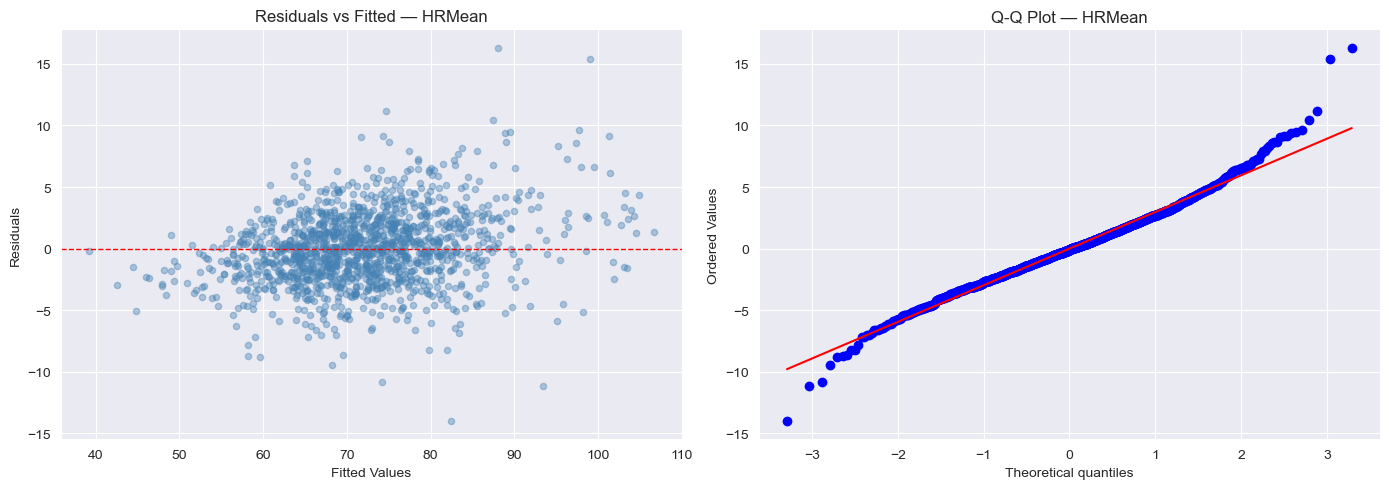

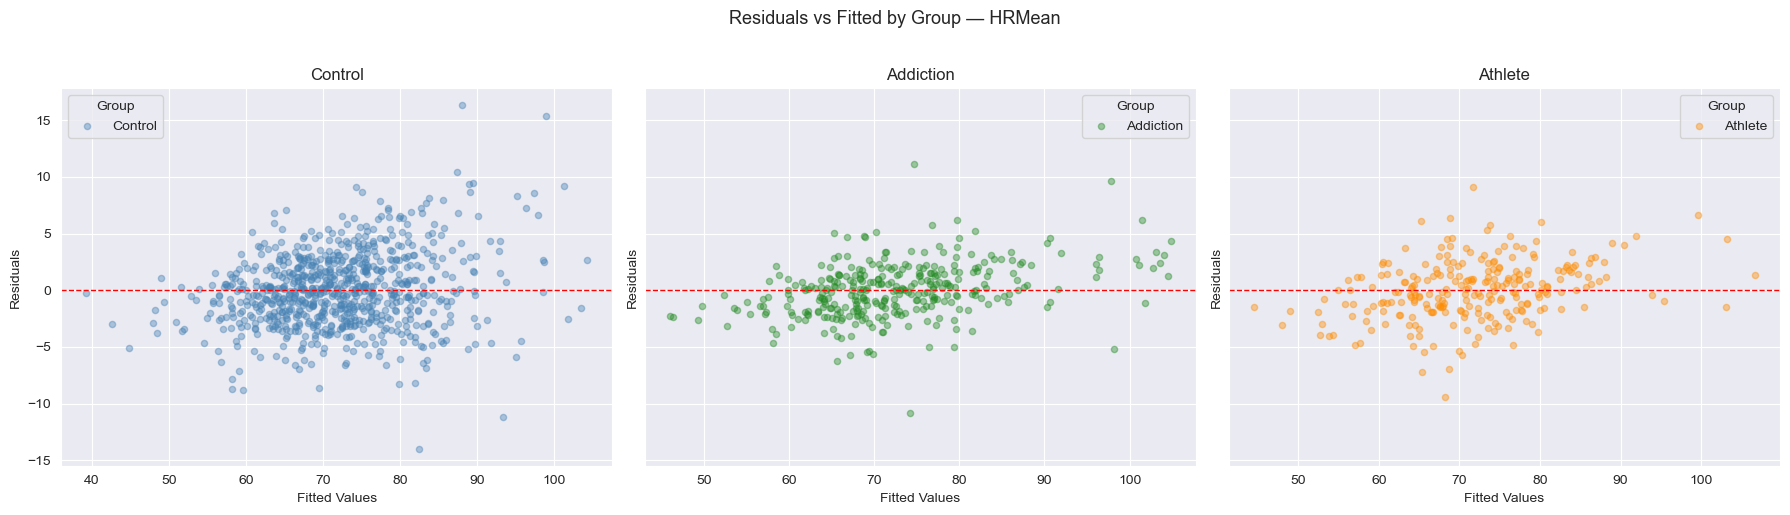

In [167]:
# ── Diagnostics ──
residuals = result.resid
fitted    = result.fittedvalues

diag_df = filtered_df[['ID6', 'Group']].copy()
diag_df['residuals'] = residuals.values
diag_df['fitted']    = fitted.values


####### ── Plot 1: Residuals vs Fitted + Q-Q ── ######
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(diag_df['fitted'], diag_df['residuals'], alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted — {DV}')

# Q-Q plot
stats.probplot(diag_df['residuals'], plot=axes[1])
axes[1].set_title(f'Q-Q Plot — {DV}')

plt.tight_layout()
plt.show()


###### ── Plot 2: Residuals vs Fitted by Group (1x3 subplots) ── ######
groups     = diag_df['Group'].unique()
group_colors = {'Control': 'steelblue', 'Athlete': 'darkorange', 'Addiction': 'forestgreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grp in zip(axes, groups):
    grp_data = diag_df[diag_df['Group'] == grp]
    ax.scatter(grp_data['fitted'], grp_data['residuals'],
               alpha=0.4, s=20, color=group_colors[grp], label=grp)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{grp}')
    ax.legend(title='Group')

fig.suptitle(f'Residuals vs Fitted by Group — {DV}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### RRI_ln

In [168]:
DV = 'RRI_ln'
within_var = 'timepoint'
between_var = 'Group'

three_groups = ['Control', 'Athlete', 'Addiction']

for group in three_groups:
    physio_demo_df = group_order(physio_demo_df, reference=group)

    filtered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

    # Fit mixed LMM with random intercept per subject
    model = smf.mixedlm(
        formula=f'{DV} ~ {within_var} * {between_var}',
        data=filtered_df,
        groups=filtered_df['ID6']  # random intercept per subject
    )

    result = model.fit(reml=True)  # REML standard for LMM variance estimation
    
    # print(f"\n{'='*50}")
    print(f"Reference group: {group}")
    print(result.summary())


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Reference group: Control
                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        RRI_ln    
No. Observations:         1152           Method:                    REML      
No. Groups:               577            Scale:                     2.5030    
Min. group size:          1              Log-Likelihood:            -2165.9475
Max. group size:          2              Converged:                 Yes       
Mean group size:          2.0                                                 
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           9.503    0.080 118.616 0.000  9.346  9.660
timepoint[T.6P]                     3.765    0.113  33.207 0.000  3.542  3.987
Group[T.Athlete]                    0.008    0.3

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Reference group: Athlete
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        RRI_ln    
No. Observations:        1152           Method:                    REML      
No. Groups:              577            Scale:                     2.5030    
Min. group size:         1              Log-Likelihood:            -2165.9475
Max. group size:         2              Converged:                 Yes       
Mean group size:         2.0                                                 
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           9.510    0.345 27.547 0.000  8.834 10.187
timepoint[T.6P]                     4.437    0.488  9.087 0.000  3.480  5.394
Group[T.Control]                   -0.008    0.354 -0.022 0

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


Reference group: Addiction
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       RRI_ln    
No. Observations:       1152          Method:                   REML      
No. Groups:             577           Scale:                    2.5030    
Min. group size:        1             Log-Likelihood:           -2165.9475
Max. group size:        2             Converged:                Yes       
Mean group size:        2.0                                               
--------------------------------------------------------------------------
                                 Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        9.056    0.123 73.525 0.000  8.814  9.297
timepoint[T.6P]                  1.830    0.174 10.521 0.000  1.489  2.171
Group[T.Control]                 0.447    0.147  3.040 0.002  0.159  0.735
Group[T.Athlete] 

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


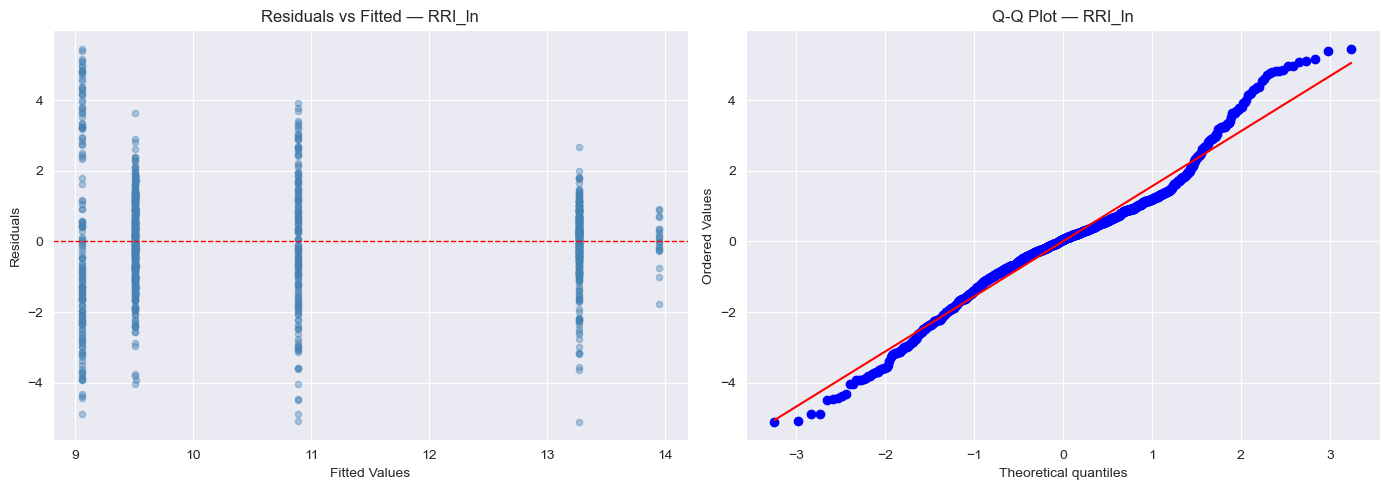

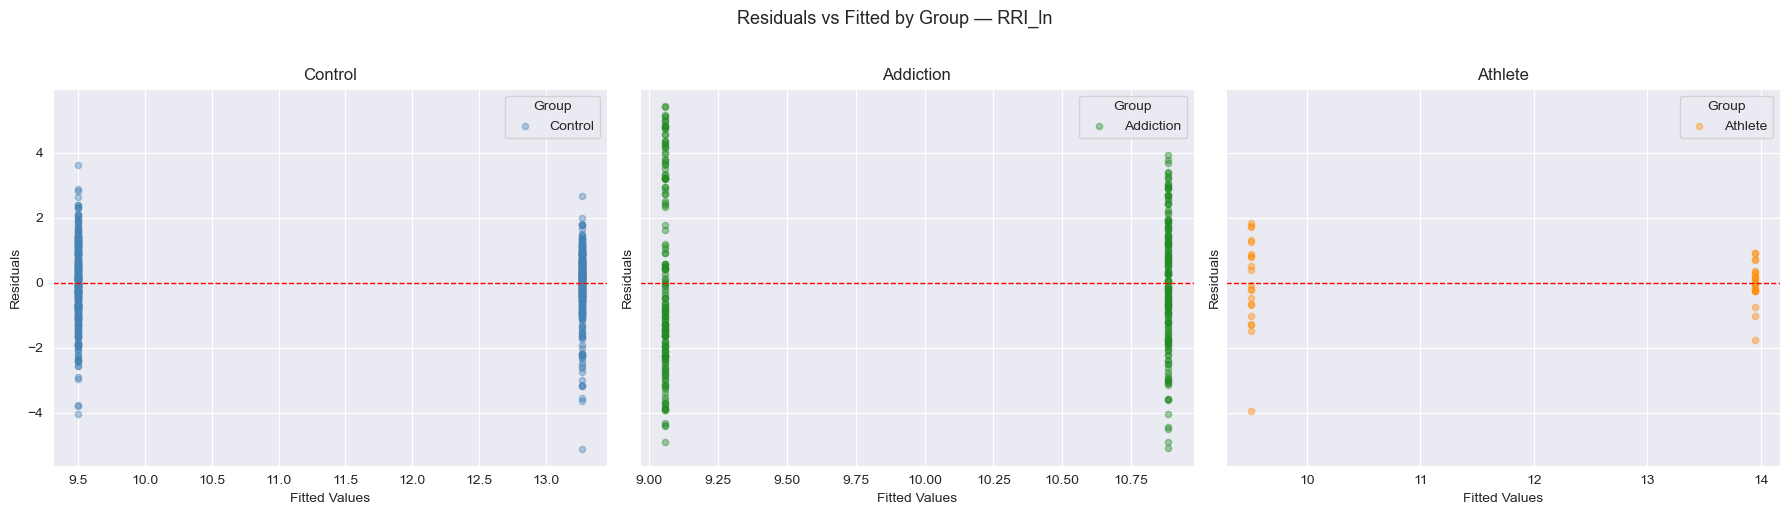

In [169]:
# ── Diagnostics ──
residuals = result.resid
fitted    = result.fittedvalues

diag_df = filtered_df[['ID6', 'Group']].copy()
diag_df['residuals'] = residuals.values
diag_df['fitted']    = fitted.values


####### ── Plot 1: Residuals vs Fitted + Q-Q ── ######
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(diag_df['fitted'], diag_df['residuals'], alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted — {DV}')

# Q-Q plot
stats.probplot(diag_df['residuals'], plot=axes[1])
axes[1].set_title(f'Q-Q Plot — {DV}')

plt.tight_layout()
plt.show()


###### ── Plot 2: Residuals vs Fitted by Group (1x3 subplots) ── ######
groups     = diag_df['Group'].unique()
group_colors = {'Control': 'steelblue', 'Athlete': 'darkorange', 'Addiction': 'forestgreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grp in zip(axes, groups):
    grp_data = diag_df[diag_df['Group'] == grp]
    ax.scatter(grp_data['fitted'], grp_data['residuals'],
               alpha=0.4, s=20, color=group_colors[grp], label=grp)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{grp}')
    ax.legend(title='Group')

fig.suptitle(f'Residuals vs Fitted by Group — {DV}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### RRIRmssd_ln

In [170]:
DV = 'RRIRmssd_ln'
within_var = 'timepoint'
between_var = 'Group'

three_groups = ['Control', 'Athlete', 'Addiction']

for group in three_groups:
    physio_demo_df = group_order(physio_demo_df, reference=group)

    filtered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

    # Fit mixed LMM with random intercept per subject
    model = smf.mixedlm(
        formula=f'{DV} ~ {within_var} * {between_var}',
        data=filtered_df,
        groups=filtered_df['ID6']  # random intercept per subject
    )

    result = model.fit(reml=True)  # REML standard for LMM variance estimation
    
    # print(f"\n{'='*50}")
    print(f"Reference group: {group}")
    print(result.summary())


Reference group: Control
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        RRIRmssd_ln
No. Observations:        1381           Method:                    REML       
No. Groups:              694            Scale:                     0.1042     
Min. group size:         1              Log-Likelihood:            -1022.1040 
Max. group size:         2              Converged:                 Yes        
Mean group size:         2.0                                                  
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           3.907    0.030 130.065 0.000  3.848  3.966
timepoint[T.6P]                     0.097    0.023   4.236 0.000  0.052  0.142
Group[T.Athlete]                    0.167    0.0

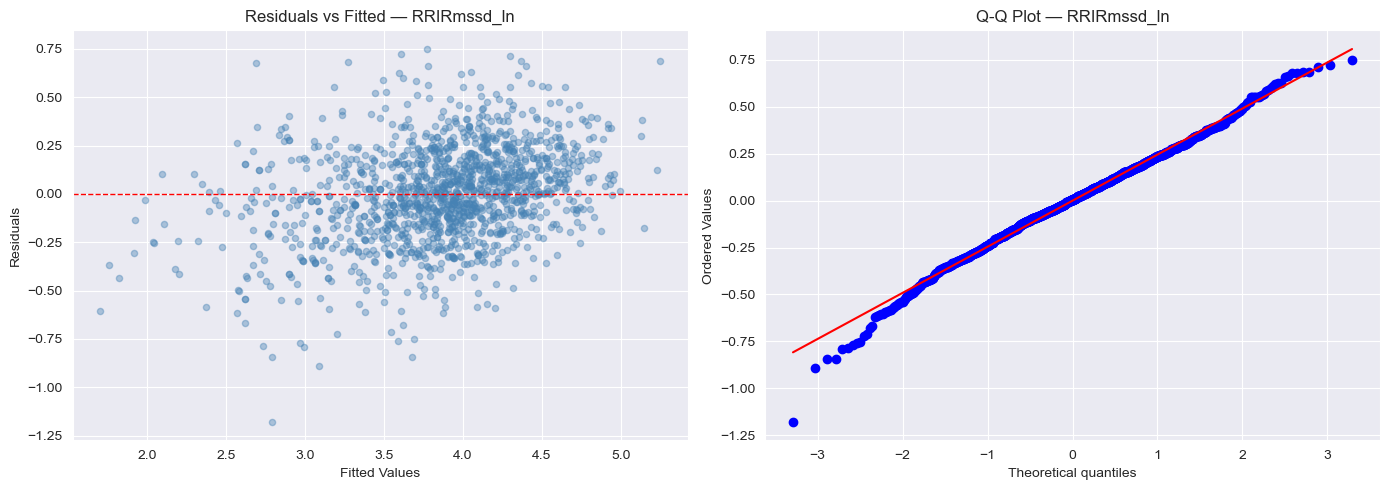

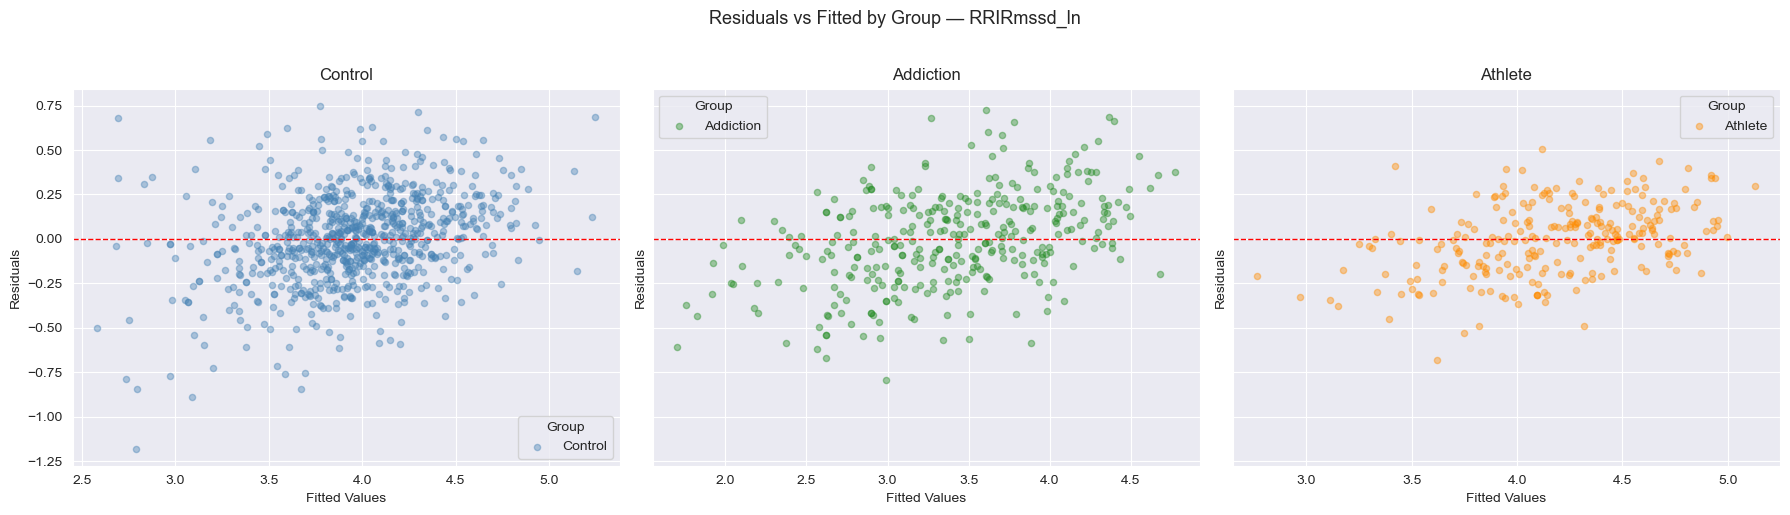

In [171]:
# ── Diagnostics ──
residuals = result.resid
fitted    = result.fittedvalues

diag_df = filtered_df[['ID6', 'Group']].copy()
diag_df['residuals'] = residuals.values
diag_df['fitted']    = fitted.values


####### ── Plot 1: Residuals vs Fitted + Q-Q ── ######
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(diag_df['fitted'], diag_df['residuals'], alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted — {DV}')

# Q-Q plot
stats.probplot(diag_df['residuals'], plot=axes[1])
axes[1].set_title(f'Q-Q Plot — {DV}')

plt.tight_layout()
plt.show()


###### ── Plot 2: Residuals vs Fitted by Group (1x3 subplots) ── ######
groups     = diag_df['Group'].unique()
group_colors = {'Control': 'steelblue', 'Athlete': 'darkorange', 'Addiction': 'forestgreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grp in zip(axes, groups):
    grp_data = diag_df[diag_df['Group'] == grp]
    ax.scatter(grp_data['fitted'], grp_data['residuals'],
               alpha=0.4, s=20, color=group_colors[grp], label=grp)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{grp}')
    ax.legend(title='Group')

fig.suptitle(f'Residuals vs Fitted by Group — {DV}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### RRIPnn50_ln

In [172]:
DV = 'RRIPnn50_ln'
within_var = 'timepoint'
between_var = 'Group'

three_groups = ['Control', 'Athlete', 'Addiction']

for group in three_groups:
    physio_demo_df = group_order(physio_demo_df, reference=group)

    filtered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

    # Fit mixed LMM with random intercept per subject
    model = smf.mixedlm(
        formula=f'{DV} ~ {within_var} * {between_var}',
        data=filtered_df,
        groups=filtered_df['ID6']  # random intercept per subject
    )

    result = model.fit(reml=True)  # REML standard for LMM variance estimation
    
    # print(f"\n{'='*50}")
    print(f"Reference group: {group}")
    print(result.summary())


Reference group: Control
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        RRIPnn50_ln
No. Observations:        1318           Method:                    REML       
No. Groups:              678            Scale:                     0.4772     
Min. group size:         1              Log-Likelihood:            -1920.3935 
Max. group size:         2              Converged:                 Yes        
Mean group size:         1.9                                                  
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           3.075    0.060  51.313 0.000  2.958  3.193
timepoint[T.6P]                    -0.025    0.050  -0.512 0.608 -0.122  0.072
Group[T.Athlete]                    0.215    0.1

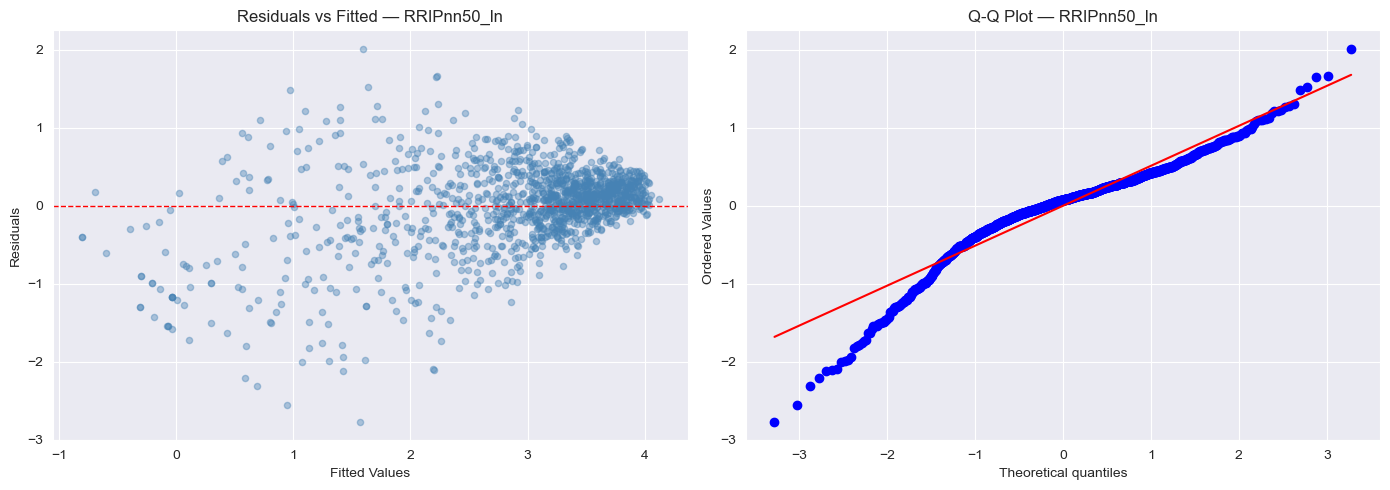

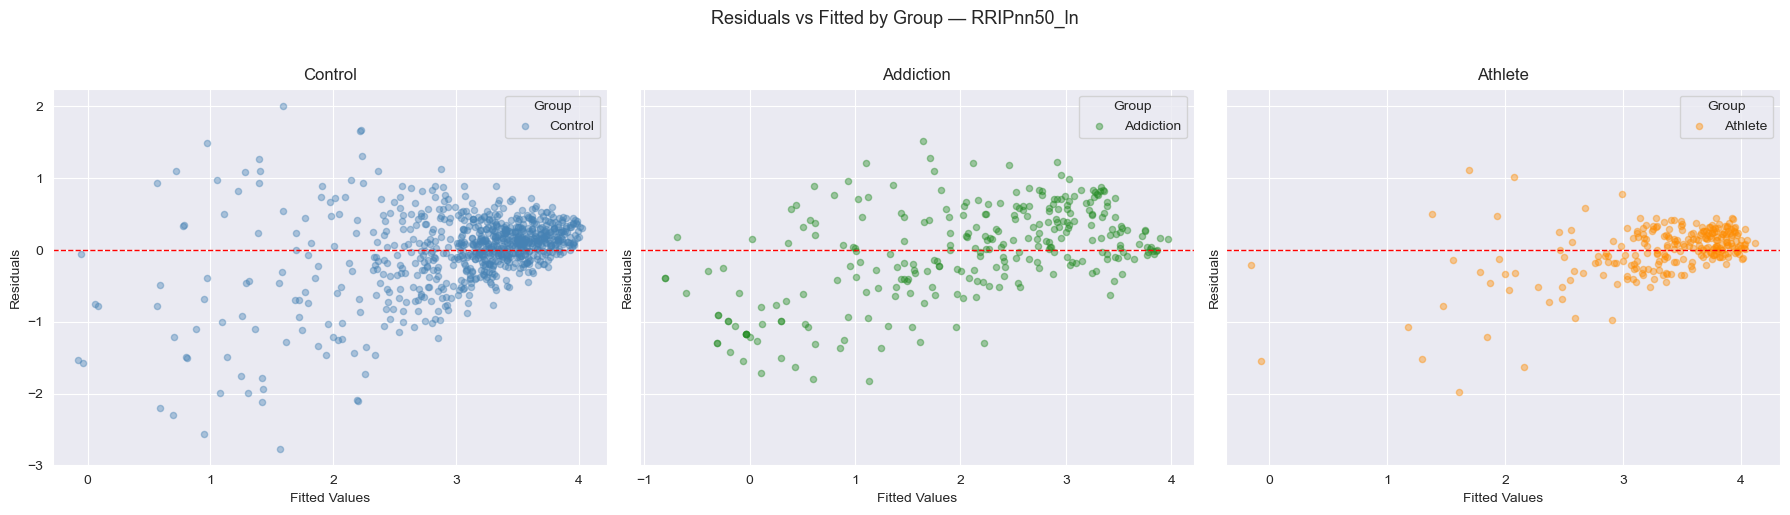

In [173]:
# ── Diagnostics ──
residuals = result.resid
fitted    = result.fittedvalues

diag_df = filtered_df[['ID6', 'Group']].copy()
diag_df['residuals'] = residuals.values
diag_df['fitted']    = fitted.values


####### ── Plot 1: Residuals vs Fitted + Q-Q ── ######
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(diag_df['fitted'], diag_df['residuals'], alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted — {DV}')

# Q-Q plot
stats.probplot(diag_df['residuals'], plot=axes[1])
axes[1].set_title(f'Q-Q Plot — {DV}')

plt.tight_layout()
plt.show()


###### ── Plot 2: Residuals vs Fitted by Group (1x3 subplots) ── ######
groups     = diag_df['Group'].unique()
group_colors = {'Control': 'steelblue', 'Athlete': 'darkorange', 'Addiction': 'forestgreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grp in zip(axes, groups):
    grp_data = diag_df[diag_df['Group'] == grp]
    ax.scatter(grp_data['fitted'], grp_data['residuals'],
               alpha=0.4, s=20, color=group_colors[grp], label=grp)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{grp}')
    ax.legend(title='Group')

fig.suptitle(f'Residuals vs Fitted by Group — {DV}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### RRIRSLf_ln

In [174]:
DV = 'RRISLf_ln'
within_var = 'timepoint'
between_var = 'Group'

three_groups = ['Control', 'Athlete', 'Addiction']

for group in three_groups:
    physio_demo_df = group_order(physio_demo_df, reference=group)

    filtered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

    # Fit mixed LMM with random intercept per subject
    model = smf.mixedlm(
        formula=f'{DV} ~ {within_var} * {between_var}',
        data=filtered_df,
        groups=filtered_df['ID6']  # random intercept per subject
    )

    result = model.fit(reml=True)  # REML standard for LMM variance estimation
    
    # print(f"\n{'='*50}")
    print(f"Reference group: {group}")
    print(result.summary())


Reference group: Control
                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        RRISLf_ln 
No. Observations:         1381           Method:                    REML      
No. Groups:               694            Scale:                     0.4512    
Min. group size:          1              Log-Likelihood:            -1841.8896
Max. group size:          2              Converged:                 Yes       
Mean group size:          2.0                                                 
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           6.719    0.050 134.253 0.000  6.621  6.817
timepoint[T.6P]                     2.049    0.048  42.979 0.000  1.956  2.143
Group[T.Athlete]                    0.587    0.1

### RRISHf_ln

In [175]:
DV = 'RRISHf_ln'
within_var = 'timepoint'
between_var = 'Group'

three_groups = ['Control', 'Athlete', 'Addiction']

for group in three_groups:
    physio_demo_df = group_order(physio_demo_df, reference=group)

    filtered_df = physio_demo_df.dropna(subset=[DV, within_var, between_var], axis=0).copy().reset_index(drop=True)

    # Fit mixed LMM with random intercept per subject
    model = smf.mixedlm(
        formula=f'{DV} ~ {within_var} * {between_var}',
        data=filtered_df,
        groups=filtered_df['ID6']  # random intercept per subject
    )

    result = model.fit(reml=True)  # REML standard for LMM variance estimation
    
    # print(f"\n{'='*50}")
    print(f"Reference group: {group}")
    print(result.summary())


Reference group: Control
                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        RRISHf_ln 
No. Observations:         1381           Method:                    REML      
No. Groups:               694            Scale:                     0.6297    
Min. group size:          1              Log-Likelihood:            -2083.5660
Max. group size:          2              Converged:                 Yes       
Mean group size:          2.0                                                 
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           6.588    0.060 109.866 0.000  6.470  6.705
timepoint[T.6P]                    -0.263    0.056  -4.670 0.000 -0.373 -0.153
Group[T.Athlete]                    0.179    0.1

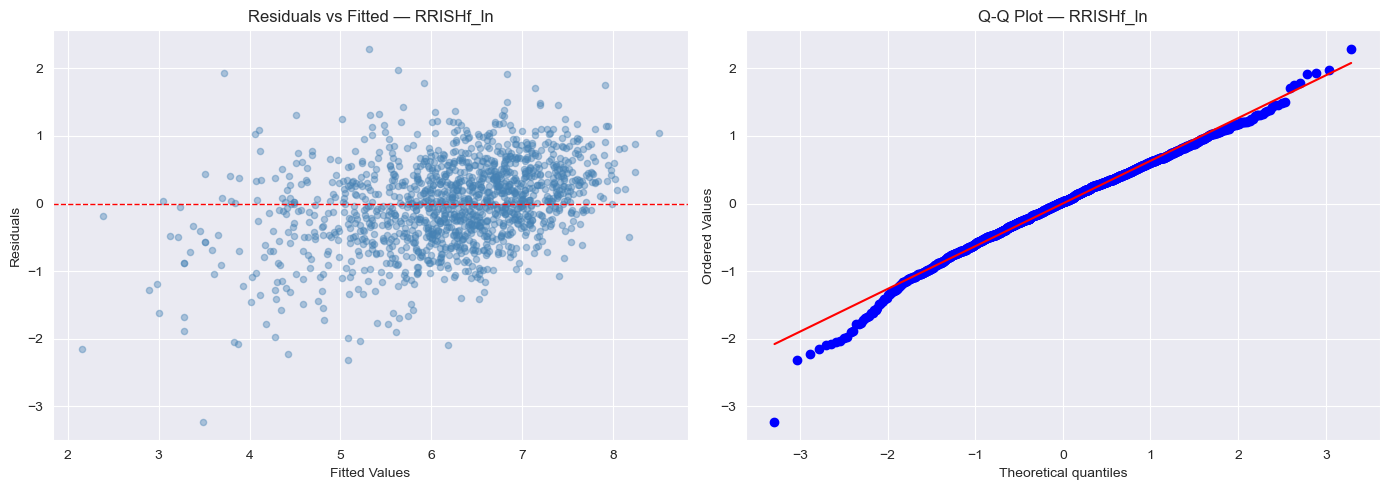

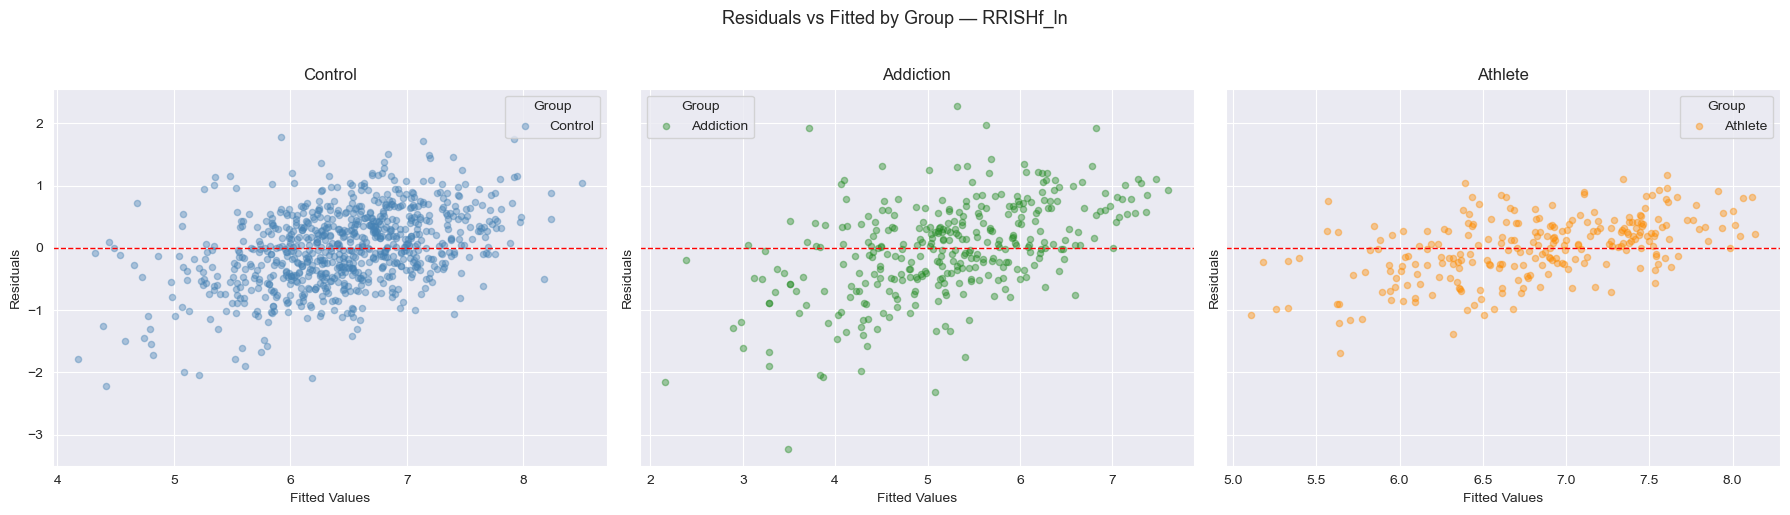

In [176]:
# ── Diagnostics ──
residuals = result.resid
fitted    = result.fittedvalues

diag_df = filtered_df[['ID6', 'Group']].copy()
diag_df['residuals'] = residuals.values
diag_df['fitted']    = fitted.values


####### ── Plot 1: Residuals vs Fitted + Q-Q ── ######
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(diag_df['fitted'], diag_df['residuals'], alpha=0.4, s=20, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted — {DV}')

# Q-Q plot
stats.probplot(diag_df['residuals'], plot=axes[1])
axes[1].set_title(f'Q-Q Plot — {DV}')

plt.tight_layout()
plt.show()


###### ── Plot 2: Residuals vs Fitted by Group (1x3 subplots) ── ######
groups     = diag_df['Group'].unique()
group_colors = {'Control': 'steelblue', 'Athlete': 'darkorange', 'Addiction': 'forestgreen'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grp in zip(axes, groups):
    grp_data = diag_df[diag_df['Group'] == grp]
    ax.scatter(grp_data['fitted'], grp_data['residuals'],
               alpha=0.4, s=20, color=group_colors[grp], label=grp)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{grp}')
    ax.legend(title='Group')

fig.suptitle(f'Residuals vs Fitted by Group — {DV}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# End

In [177]:
adfasfasf

NameError: name 'adfasfasf' is not defined